# **Taller — Predicción de accidentalidad**

> Aprendizaje Automático  
> Taller, Semestre 2026-1  
> Clasificación binaria · Manejo de clases desbalanceadas · Datos en SQLite  
> Profesor: Marco Teran  
> Equipo: Sara Martinez, Kelly enrriquez, Heider Zapata y Yeison Londoño

---

## **1. Librerías y configuración inicial**

In [42]:
import sqlite3
import pandas as pd
import warnings
from typing import Tuple

# Configuración para mejorar la legibilidad en Jupyter
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Semilla de reproducibilidad
RANDOM_STATE = 42

# Ruta relativa a la base de datos (misma carpeta que el notebook)
DB_PATH = 'data_accidentes.sqlite3'

---

## **2. Importar datos y optimizar RAM**

### **2.1. Conexión a la base de datos SQLite con sqlite3**



In [43]:
def extraer_datos_sqlite(ruta_db: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Se conecta a la base de datos SQLite, extrae las tablas necesarias parseando 
    la columna temporal 'TW' y retorna los DataFrames. Asegura el cierre de la conexión.
    
    Args:
        ruta_db (str): Ruta al archivo .sqlite3
        
    Returns:
        Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: (accidentes, clima, raw)
    """
    print(f"Iniciando conexión a la base de datos: '{ruta_db}'...")
    con = None
    
    try:
        # 1. Establecer conexión
        con = sqlite3.connect(ruta_db)
        
        # 2. Lectura y parseo estricto de fechas
        print("Extrayendo y parseando tabla 'accidentes'...")
        accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
        
        print("Extrayendo y parseando tabla 'clima'...")
        clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
        
        print("Extrayendo y parseando tabla 'raw_accidentes'...")
        raw = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
        
        print("¡Extracción exitosa!")
        
    except sqlite3.Error as e:
        print(f"Error crítico al interactuar con SQLite: {e}")
        raise
        
    finally:
        # 3. Cierre seguro de la conexión
        if con:
            con.close()
            print("Conexión a SQLite cerrada correctamente.")
            
    return accidentes, clima, raw

In [44]:
# Ejecución de la ingesta
df_accidentes, df_clima, df_raw = extraer_datos_sqlite(DB_PATH)

# Verificación visual rápida y revisión de tipos de dato en TW
print("\n" + "="*50)
print(f"Info df_accidentes: TW es tipo {df_accidentes['TW'].dtype}")
display(df_accidentes.head(3))

print("\n" + "="*50)
print(f"Info df_clima: TW es tipo {df_clima['TW'].dtype}")
display(df_clima.head(3))

print("\n" + "="*50)
print(f"Info df_raw: TW es tipo {df_raw['TW'].dtype}")
display(df_raw.head(3))

Iniciando conexión a la base de datos: 'data_accidentes.sqlite3'...
Extrayendo y parseando tabla 'accidentes'...
Extrayendo y parseando tabla 'clima'...
Extrayendo y parseando tabla 'raw_accidentes'...
¡Extracción exitosa!
Conexión a SQLite cerrada correctamente.

Info df_accidentes: TW es tipo datetime64[us]


,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570146,JUEVES,7,20,8
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600280,JUEVES,6,15,16
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584306,DOMINGO,7,2,16



Info df_clima: TW es tipo datetime64[us]


,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,1.02,NaN,0.44,0.0,2.997



Info df_raw: TW es tipo datetime64[us]


,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.570146,6.233985,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,1020,Malla vial,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,NaN,8,2017-07-20 08:00:00
1,-75.600280,6.238844,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,1109,Malla vial,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,NaN,16,2017-06-15 16:00:00
2,-75.584306,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,0710,Malla vial,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,NaN,16,2017-07-02 16:00:00


### **2.2. Optimización de memoria RAM**

1. **Diagnóstico y Riesgo Operativo**:
     
     La tabla clima —universo espacio-temporal de combinaciones barrio-hora ($B, h$)— introduce 7,991,780 registros y consume inicialmente 2,101.40 MB (~2.1 GB) en RAM bajo tipos crudos (float64 y object).  
     
     En entornos locales, el flujo metodológico que demanda el Taller expande drásticamente las matrices analíticas. Continuar sin optimizar podría causar un colapso del Kernel por desbordamiento de memoria (OOM Error).

In [45]:
def diagnosticar_recursos_dataframes(
    accidentes: pd.DataFrame, 
    clima: pd.DataFrame, 
    raw: pd.DataFrame
) -> None:
    """
    Analiza y despliega de forma tabular y legible el tamaño en memoria RAM,
    el número de registros y las dimensiones de los tres DataFrames cargados.
    
    Args:
        accidentes (pd.DataFrame): DataFrame de accidentes agregados.
        clima (pd.DataFrame): DataFrame con la matriz climática barrio-hora.
        raw (pd.DataFrame): DataFrame de accidentes individuales en crudo.
    """
    dfs = {
        'df_accidentes': accidentes,
        'df_clima': clima,
        'df_raw': raw
    }
    
    registros_diagnostico = []
    
    print("=== DIAGNÓSTICO DE CONSUMO DE RECURSOS EN MEMORIA RAM ===")
    
    for nombre, df in dfs.items():
        # memory_usage(deep=True) evalúa el costo real de objetos/strings en bytes
        memoria_bytes = df.memory_usage(deep=True).sum()
        memoria_mb = memoria_bytes / (1024 ** 2)
        
        registros_diagnostico.append({
            'DataFrame': nombre,
            'Filas (N)': f"{df.shape[0]:,}",
            'Columnas (D)': df.shape[1],
            'RAM Usada (MB)': round(memoria_mb, 2),
            'Tipo de Carga': 'Ligera (<50MB)' if memoria_mb < 50 else ('Moderada (50-500MB)' if memoria_mb < 500 else 'Pesada (>500MB)')
        })
        
    # Crear un DataFrame resumen para visualización limpia
    df_resumen = pd.DataFrame(registros_diagnostico)
    display(df_resumen)
    
    # Evaluar viabilidad local general
    total_ram_mb = df_resumen['RAM Usada (MB)'].sum()
    print(f"\nConsumo total inicial en RAM: {total_ram_mb:.2f} MB")
    
    print("\n💡 RECOMENDACIÓN:")
    if total_ram_mb < 200:
        print("-> Viabilidad: ALTA. Los datos base pesan muy poco. Puedes trabajar en tu máquina local sin problema.")
        print("   Nota: Ten presente que al realizar el LEFT JOIN con 'df_clima' el dataset crecerá, pero seguirá siendo perfectamente manejable.")
    elif total_ram_mb < 1000:
        print("-> Viabilidad: MODERADA. Monitorea los procesos de optimización de hiperparámetros de modelos de ensamble.")
    else:
        print("-> Viabilidad: CRÍTICA. Se sugiere aplicar optimización de tipos de datos (downcasting) o usar entornos de nube.")

In [46]:
# Ejecución del diagnóstico pasándole las variables creadas en la celda anterior
diagnosticar_recursos_dataframes(df_accidentes, df_clima, df_raw)

=== DIAGNÓSTICO DE CONSUMO DE RECURSOS EN MEMORIA RAM ===


,DataFrame,Filas (N),Columnas (D),RAM Usada (MB),Tipo de Carga
0,df_accidentes,"120,587",8,18.82,Ligera (<50MB)
1,df_clima,"7,991,780",15,2101.40,Pesada (>500MB)
2,df_raw,"125,122",22,106.37,Moderada (50-500MB)



Consumo total inicial en RAM: 2226.59 MB

💡 RECOMENDACIÓN:
-> Viabilidad: CRÍTICA. Se sugiere aplicar optimización de tipos de datos (downcasting) o usar entornos de nube.


2. **Protocolo de Tratamiento Aplicado**:

     - **Downcasting Numérico (float64 $\rightarrow$ float32)**: Las 11 variables continuas meteorológicas (temperature, humidity, etc.) se transforman de float64 a float32. Mientras que float64 ofrece una precisión redundante de 15 a 17 decimales significativos (apta para física cuántica o aeroespacial), float32 retiene hasta 7 dígitos significativos. Dado que los sensores climáticos del mundo real conllevan una incertidumbre física intrínseca de $\pm0.1$ a $\pm0.5$ unidades, la reducción descarta el "ruido digital" de los decimales lejanos conservando el 100% de la señal explicativa del negocio y reduciendo el peso numérico a la mitad (50% de ahorro).

     - **Categorización Sincronizada Global (str $\rightarrow$ category)**: Tres columnas basadas en texto libre (BARRIO, summary e icon) secuestran el 65% del peso total de la RAM (~1.36 GB) debido a la ineficiente redundancia de almacenar strings repetitivos en millones de filas. Al convertirlas a tipo categórico (category), Pandas almacena un único mapa indexado y rellena las filas con enteros ligeros (int8/int16).

          - Garantía contra Data Leakage y Desalineación: Aplicar un método .astype('category') de forma independiente en cada DataFrame asignaría índices internos discordantes (ej: que el índice 0 signifique 'Robledo' en el clima pero 'Aranjuez' en accidentes), rompiendo los posteriores cruces (merges) o forzando recasteos implícitos costosos en RAM. El pipeline extrae los valores únicos globales del ecosistema de datos y aplica de forma explícita el mismo pd.CategoricalDtype maestro e idéntico a las tres tablas analíticas (df_clima, df_accidentes, df_raw).

AUDITORÍA DE SEGURIDAD PARA DOWNCASTING: df_clima

In [47]:
def auditar_limites_variables(df: pd.DataFrame, nombre_df: str) -> None:
    """
    Evalúa los rangos de las variables numéricas y la cardinalidad de las categóricas
    para confirmar si es seguro aplicar downcasting (optimización de memoria).
    """
    print(f"=== AUDITORÍA DE SEGURIDAD PARA DOWNCASTING: {nombre_df} ===\n")
    
    perfil = []
    for col in df.columns:
        tipo = df[col].dtype
        
        if 'int' in str(tipo) or 'float' in str(tipo):
            val_min = df[col].min()
            val_max = df[col].max()
            perfil.append({
                'Columna': col,
                'Tipo Actual': str(tipo),
                'Mínimo': val_min,
                'Máximo': val_max,
                'Recomendación Segura': 'int8' if ('int' in str(tipo) and val_min >= -128 and val_max <= 127) else 'float32' if 'float' in str(tipo) else 'Mantener'
            })
            
        elif tipo == 'object':
            cardinalidad = df[col].nunique()
            perfil.append({
                'Columna': col,
                'Tipo Actual': str(tipo),
                'Mínimo': f"N/A ({cardinalidad} únicos)",
                'Máximo': 'N/A',
                'Recomendación Segura': 'category' if cardinalidad < (len(df) * 0.1) else 'Mantener'
            })
            
    df_perfil = pd.DataFrame(perfil)
    display(df_perfil)

# Ejecutamos la auditoría en la tabla que nos causa el cuello de botella
auditar_limites_variables(df_clima, "df_clima")

=== AUDITORÍA DE SEGURIDAD PARA DOWNCASTING: df_clima ===



,Columna,Tipo Actual,Mínimo,Máximo,Recomendación Segura
0,precipIntensity,float64,0.000,20.8236,float32
1,precipProbability,float64,0.000,1.0000,float32
2,temperature,float64,4.510,35.9900,float32
3,apparentTemperature,float64,4.510,38.0600,float32
4,dewPoint,float64,2.160,24.0400,float32
5,humidity,float64,0.170,1.0000,float32
6,windSpeed,float64,0.000,15.2600,float32
7,windBearing,float64,0.000,359.0000,float32
8,cloudCover,float64,0.000,1.0000,float32
9,uvIndex,float64,0.000,14.0000,float32


AUDITORÍA DE COLUMNAS CATEGÓRICAS: df_clima

In [48]:
def auditar_columnas_categoricas(df: pd.DataFrame, nombre_df: str) -> None:
    """
    Identifica las columnas de tipo object o string en el DataFrame, calcula su cardinalidad
    y extrae una muestra representativa de sus valores únicos para validar la conversión.
    
    Args:
        df (pd.DataFrame): DataFrame a analizar.
        nombre_df (str): Nombre identificador del DataFrame para el reporte.
    """
    # Seleccionar únicamente columnas de tipo texto u objeto
    cols_objeto = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not cols_objeto:
        print(f"No se encontraron columnas categóricas en el DataFrame '{nombre_df}'.\n")
        return
        
    print(f"=== AUDITORÍA DE COLUMNAS CATEGÓRICAS: {nombre_df} ===")
    print(f"Total registros evaluados: {len(df):,}\n")
    
    resumen_cats = []
    
    for col in cols_objeto:
        # Obtener valores únicos omitiendo nulos para el conteo de categorías
        valores_unicos = df[col].dropna().unique()
        n_unicos = len(valores_unicos)
        porcentaje_unicos = (n_unicos / len(df)) * 100
        
        # Tomar una muestra de los primeros 5 valores para inspección visual
        muestra = list(valores_unicos[:5])
        muestra_str = ", ".join([f"'{v}'" for v in muestra])
        if n_unicos > 5:
            muestra_str += " ... "
            
        resumen_cats.append({
            'Columna': col,
            'Nº Valores Únicos': f"{n_unicos:,}",
            '% de Valores Únicos': f"{porcentaje_unicos:.4f}%",
            'Muestra de Valores': muestra_str,
            '¿Seguro para Categoria?': 'SÍ (Baja cardinalidad)' if porcentaje_unicos < 5.0 else 'Evaluar (Alta cardinalidad)'
        })
        
    df_resumen = pd.DataFrame(resumen_cats)
    display(df_resumen)

In [49]:
# Ejecutamos la función sobre el dataset principal de clima
auditar_columnas_categoricas(df_clima, "df_clima")

=== AUDITORÍA DE COLUMNAS CATEGÓRICAS: df_clima ===
Total registros evaluados: 7,991,780



,Columna,Nº Valores Únicos,% de Valores Únicos,Muestra de Valores,¿Seguro para Categoria?
0,BARRIO,319,0.0040%,"'aguasfrias', 'aldeapablovi', 'alejandria', 'a...",SÍ (Baja cardinalidad)
1,summary,20,0.0003%,"'Partly Cloudy', 'Foggy', 'Mostly Cloudy', 'Cl...",SÍ (Baja cardinalidad)
2,icon,8,0.0001%,"'partly-cloudy-night', 'fog', 'partly-cloudy-d...",SÍ (Baja cardinalidad)


OPTIMIZACIÓN:

In [50]:
def optimizar_memoria(df: pd.DataFrame, ignorar_columnas: list = None) -> pd.DataFrame:
    """
    Optimiza el uso de memoria RAM en un DataFrame convirtiendo flotantes a float32,
    enteros al menor tipo posible, y objetos string a categorías si aplica.
    
    Args:
        df (pd.DataFrame): DataFrame original.
        ignorar_columnas (list): Columnas que no deben ser alteradas (ej. fechas).
        
    Returns:
        pd.DataFrame: DataFrame optimizado.
    """
    df_optimizado = df.copy()
    if ignorar_columnas is None:
        ignorar_columnas = []
        
    for col in df_optimizado.columns:
        if col in ignorar_columnas:
            continue
            
        tipo_actual = df_optimizado[col].dtype
        
        # 1. Optimizar Cadenas de Texto (Objects) a Categorías
        if tipo_actual == 'object':
            # Solo convertimos si tiene una cardinalidad razonable (no IDs únicos)
            num_unicos = df_optimizado[col].nunique()
            if num_unicos < (len(df_optimizado) * 0.5):
                df_optimizado[col] = df_optimizado[col].astype('category')
                
        # 2. Optimizar Números Enteros
        elif 'int' in str(tipo_actual):
            c_min = df_optimizado[col].min()
            c_max = df_optimizado[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df_optimizado[col] = df_optimizado[col].astype('int8')
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df_optimizado[col] = df_optimizado[col].astype('int16')
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df_optimizado[col] = df_optimizado[col].astype('int32')
                
        # 3. Optimizar Números Flotantes
        elif 'float' in str(tipo_actual):
            df_optimizado[col] = df_optimizado[col].astype('float32')
            
    return df_optimizado

In [51]:
import numpy as np

print("Iniciando la conversión y optimización de tipos de datos en RAM...")

# 1. Aplicamos la función optimizar_memoria (definida previamente) protegiendo 'TW'
df_accidentes_opt = optimizar_memoria(df_accidentes, ignorar_columnas=['TW'])
df_clima_opt      = optimizar_memoria(df_clima,      ignorar_columnas=['TW'])
df_raw_opt        = optimizar_memoria(df_raw,        ignorar_columnas=['TW'])

# 2. Reemplazamos las variables del entorno para liberar la memoria vieja
df_accidentes = df_accidentes_opt
df_clima = df_clima_opt
df_raw = df_raw_opt

print("\n--- PROCESO COMPLETADO ---")
print("Los DataFrames optimizados ya están cargados y listos en memoria.")

Iniciando la conversión y optimización de tipos de datos en RAM...

--- PROCESO COMPLETADO ---
Los DataFrames optimizados ya están cargados y listos en memoria.


3. **Balance de recursos e integridad**:
     
     La consistencia bit a bit de la transformación se validó mediante proximidad infinitesimal (np.allclose) para flotantes y homologación de nulos categóricos, certificando cero mutaciones o pérdidas silentes.

In [52]:
import pandas as pd
import numpy as np
import sqlite3
import gc

# =====================================================================
# 1. FUNCIÓN PARA FORZAR CATEGORÍAS UNIFICADAS
# =====================================================================
def forzar_categorias_unificadas(df1, df2, df3, columnas):
    """
    Fuerza la conversión a categoría extrayendo los valores únicos globales.
    Garantiza que el cruce posterior (merge) no colapse la memoria.
    """
    print("Forzando conversión categórica global...")
    dfs = [df1, df2, df3]
    
    for col in columnas:
        valores_unicos = set()
        for df in dfs:
            if col in df.columns:
                valores_unicos.update(df[col].dropna().astype(str).unique())
                
        if not valores_unicos:
            continue
            
        tipo_maestro = pd.CategoricalDtype(categories=sorted(list(valores_unicos)), ordered=False)
        
        for i, df in enumerate(dfs):
            if col in df.columns:
                dfs[i][col] = dfs[i][col].astype(str).astype(tipo_maestro)
                
        print(f" -> '{col}' unificada y convertida a categoría en todo el ecosistema.")
        
    print("¡Transformación categórica finalizada!\n")

# =====================================================================
# 2. FUNCIÓN DE AUDITORÍA GLOBAL MASIVA
# =====================================================================
def auditar_impacto_optimizacion_completo(df_origen: pd.DataFrame, db_path: str) -> None:
    print("🔬 Iniciando auditoría cruzada MASIVA para toda la tabla 'clima'...")
    print("⚠️  Aviso: Esto generará un pico temporal de RAM de ~2.2 GB. Por favor espera...")
    
    con = sqlite3.connect(db_path)
    df_crudo_ref = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
    con.close()
    
    reporte_columnas = []
    
    for col in df_crudo_ref.columns:
        ram_cruda = df_crudo_ref[col].memory_usage(deep=True) / (1024 ** 2)
        ram_opt = df_origen[col].memory_usage(deep=True) / (1024 ** 2)
        ahorro_pct = ((ram_cruda - ram_opt) / ram_cruda) * 100
        
        if 'float' in str(df_crudo_ref[col].dtype):
            integridad = np.allclose(df_crudo_ref[col].fillna(0), df_origen[col].fillna(0), atol=1e-4)
        else:
            # CORRECCIÓN: Pasamos a 'object' antes de aplicar fillna para que Pandas no nos bloquee
            str_crudo = df_crudo_ref[col].astype(object).fillna("<NULO_CONTROL>").astype(str)
            str_opt = df_origen[col].astype(object).fillna("<NULO_CONTROL>").astype(str)
            integridad = (str_crudo == str_opt).all()
            
        reporte_columnas.append({
            'Variable': col,
            'Tipo Crudo': str(df_crudo_ref[col].dtype),
            'Tipo Opt': str(df_origen[col].dtype),
            'RAM Cruda (MB)': round(ram_cruda, 2),
            'RAM Opt (MB)': round(ram_opt, 2),
            'Ahorro (%)': f"{ahorro_pct:.1f}%",
            'Integridad': '✅ INTACTA' if integridad else '❌ ALTERADA'
        })
        
    df_reporte = pd.DataFrame(reporte_columnas)
    
    ram_total_cruda = df_crudo_ref.memory_usage(deep=True).sum() / (1024 ** 2)
    ram_total_opt = df_origen.memory_usage(deep=True).sum() / (1024 ** 2)
    ahorro_total_pct = ((ram_total_cruda - ram_total_opt) / ram_total_cruda) * 100
    
    del df_crudo_ref
    gc.collect()
    
    print("\n=======================================================")
    print("       REPORTE DE LOGÍSTICA DE RECURSOS (GLOBAL)")
    print("=======================================================")
    print(f"-> RAM Cruda Real (8M Filas):       {ram_total_cruda:.2f} MB")
    print(f"-> RAM Optimizada Real (8M Filas):  {ram_total_opt:.2f} MB")
    print(f"-> Reducción neta del espacio:       {ahorro_total_pct:.1f}%")
    print("=======================================================\n")
    
    display(df_reporte)

# =====================================================================
# 3. EJECUCIÓN SECUENCIAL
# =====================================================================
columnas_texto = ['BARRIO', 'summary', 'icon']
forzar_categorias_unificadas(df_accidentes, df_clima, df_raw, columnas_texto)

auditar_impacto_optimizacion_completo(df_clima, DB_PATH)

Forzando conversión categórica global...
 -> 'BARRIO' unificada y convertida a categoría en todo el ecosistema.
 -> 'summary' unificada y convertida a categoría en todo el ecosistema.
 -> 'icon' unificada y convertida a categoría en todo el ecosistema.
¡Transformación categórica finalizada!

🔬 Iniciando auditoría cruzada MASIVA para toda la tabla 'clima'...
⚠️  Aviso: Esto generará un pico temporal de RAM de ~2.2 GB. Por favor espera...

       REPORTE DE LOGÍSTICA DE RECURSOS (GLOBAL)
-> RAM Cruda Real (8M Filas):       2101.40 MB
-> RAM Optimizada Real (8M Filas):  426.84 MB
-> Reducción neta del espacio:       79.7%



,Variable,Tipo Crudo,Tipo Opt,RAM Cruda (MB),RAM Opt (MB),Ahorro (%),Integridad
0,TW,datetime64[us],datetime64[us],60.97,60.97,0.0%,✅ INTACTA
1,BARRIO,str,category,464.69,15.27,96.7%,✅ INTACTA
2,summary,str,category,453.95,7.62,98.3%,✅ INTACTA
3,icon,str,category,451.09,7.62,98.3%,✅ INTACTA
4,precipIntensity,float64,float32,60.97,30.49,50.0%,✅ INTACTA
5,precipProbability,float64,float32,60.97,30.49,50.0%,✅ INTACTA
6,temperature,float64,float32,60.97,30.49,50.0%,✅ INTACTA
7,apparentTemperature,float64,float32,60.97,30.49,50.0%,✅ INTACTA
8,dewPoint,float64,float32,60.97,30.49,50.0%,✅ INTACTA
9,humidity,float64,float32,60.97,30.49,50.0%,✅ INTACTA


>    Se liberaron 1.67 GB de RAM (79.7% de espacio neta). El entorno local se declara optimizado y estructuralmente alineado para proceder hacia la Fase 2: Construcción de la Variable Objetivo (Target).

**Saneamiento y Purga de la Memoria RAM**

In [53]:
import gc
import pandas as pd

print("🧹 Iniciando proceso de saneamiento analítico de la memoria RAM...")

# 1. Definir lista de variables críticas de infraestructura y datos que SÍ deben sobrevivir
variables_sagradas = ['df_clima', 'df_accidentes', 'df_raw', 'DB_PATH', 'RANDOM_STATE']

# 2. Identificar dinámicamente qué objetos existen en el espacio local que no son sagrados
# Se omiten funciones y librerías del sistema (que empiezan por '_')
objetos_a_eliminar = [
    obj for obj in dir() 
    if not obj.startswith('_') 
    and obj not in variables_sagradas 
    and not callable(globals()[obj]) # No borra nuestras funciones modularizadas
    and type(globals()[obj]).__name__ != 'module' # No borra los imports de librerías
]

print(f" -> Detectados {len(objetos_a_eliminar)} objetos huérfanos o temporales para eliminación.")

# 3. Eliminar físicamente las referencias del espacio de variables local
for obj in objetos_a_eliminar:
    del globals()[obj]

# 4. Invocación explícita al recolector de basura de Python (C++)
# Esto libera el espacio real asignado en los bloques de la RAM de tu máquina
gc.collect()

print("✅ Purga finalizada. Ecosistema de datos libre de ruido.")

# =====================================================================
# 4. CONTROL DE STOCK ANALÍTICO (REPORTE DE SUPERVIVIENTES)
# =====================================================================
reporte_supervivientes = []
dfs_vivos = {'df_clima': df_clima, 'df_accidentes': df_accidentes, 'df_raw': df_raw}

for nombre, df in dfs_vivos.items():
    memoria_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    reporte_supervivientes.append({
        'DataFrame Sagrado': nombre,
        'Registros (N)': f"{df.shape[0]:,}",
        'Dimensiones (D)': df.shape[1],
        ' RAM Peso Real (MB)': round(memoria_mb, 2)
    })

df_status_ram = pd.DataFrame(reporte_supervivientes)
display(df_status_ram)

print(f"\nConsumo Neto Consolidado actual en RAM: {df_status_ram[' RAM Peso Real (MB)'].sum():.2f} MB")

🧹 Iniciando proceso de saneamiento analítico de la memoria RAM...
 -> Detectados 95 objetos huérfanos o temporales para eliminación.
✅ Purga finalizada. Ecosistema de datos libre de ruido.


,DataFrame Sagrado,Registros (N),Dimensiones (D),RAM Peso Real (MB)
0,df_clima,"7,991,780",15,426.84
1,df_accidentes,"120,587",8,8.83
2,df_raw,"125,122",22,94.82



Consumo Neto Consolidado actual en RAM: 530.49 MB


---

## **3. Análisis Exploratorio de Datos (EDA)**

In [54]:
# =============================================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA) - CONFIGURACIÓN INICIAL
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del entorno visual
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("[INFO]: Entorno gráfico inicializado para la caracterización de distribuciones.")

[INFO]: Entorno gráfico inicializado para la caracterización de distribuciones.


### **3.1. Distribución temporal de la accidentalidad**

In [55]:
df_accidentes.head()

,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570145,JUEVES,7,20,8
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600281,JUEVES,6,15,16
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584305,DOMINGO,7,2,16
3,2017-03-29 18:00:00,losconquistadores,6.239497,-75.583061,MIERCOLES,3,29,18
4,2017-07-26 20:00:00,cuartabrigada,6.260463,-75.590195,MIERCOLES,7,26,20


**Tendencias y Dinámica Macro-Anual (Serie 2017 - 2019)**

El análisis univariado y cruzado del componente temporal revela que la accidentalidad vial en los barrios del Medellín no se distribuye de manera uniforme u homogénea, sino que responde a dinámicas cíclicas estacionales y comportamientos socioeconómicos.

Auditoría temporal del dataset de accidentes
Fecha inicial:   2017-01-01 00:00:00
Fecha final:     2019-12-31 23:00:00
Cobertura total: 1095 días calendario (inclusivo)

Estadística descriptiva: volumen diario de accidentes


,Total histórico,2017,2018,2019
count,1095.0,365.0,365.0,365.0
sum,120587.0,40903.0,38809.0,40875.0
mean,110.1,112.1,106.3,112.0
std,26.0,26.0,23.9,27.5
min,34.0,44.0,34.0,37.0
25%,93.5,95.0,93.0,93.0
50%,115.0,117.0,111.0,117.0
75%,128.0,130.0,123.0,132.0
max,206.0,206.0,161.0,193.0


----------------------------------------------------------------------


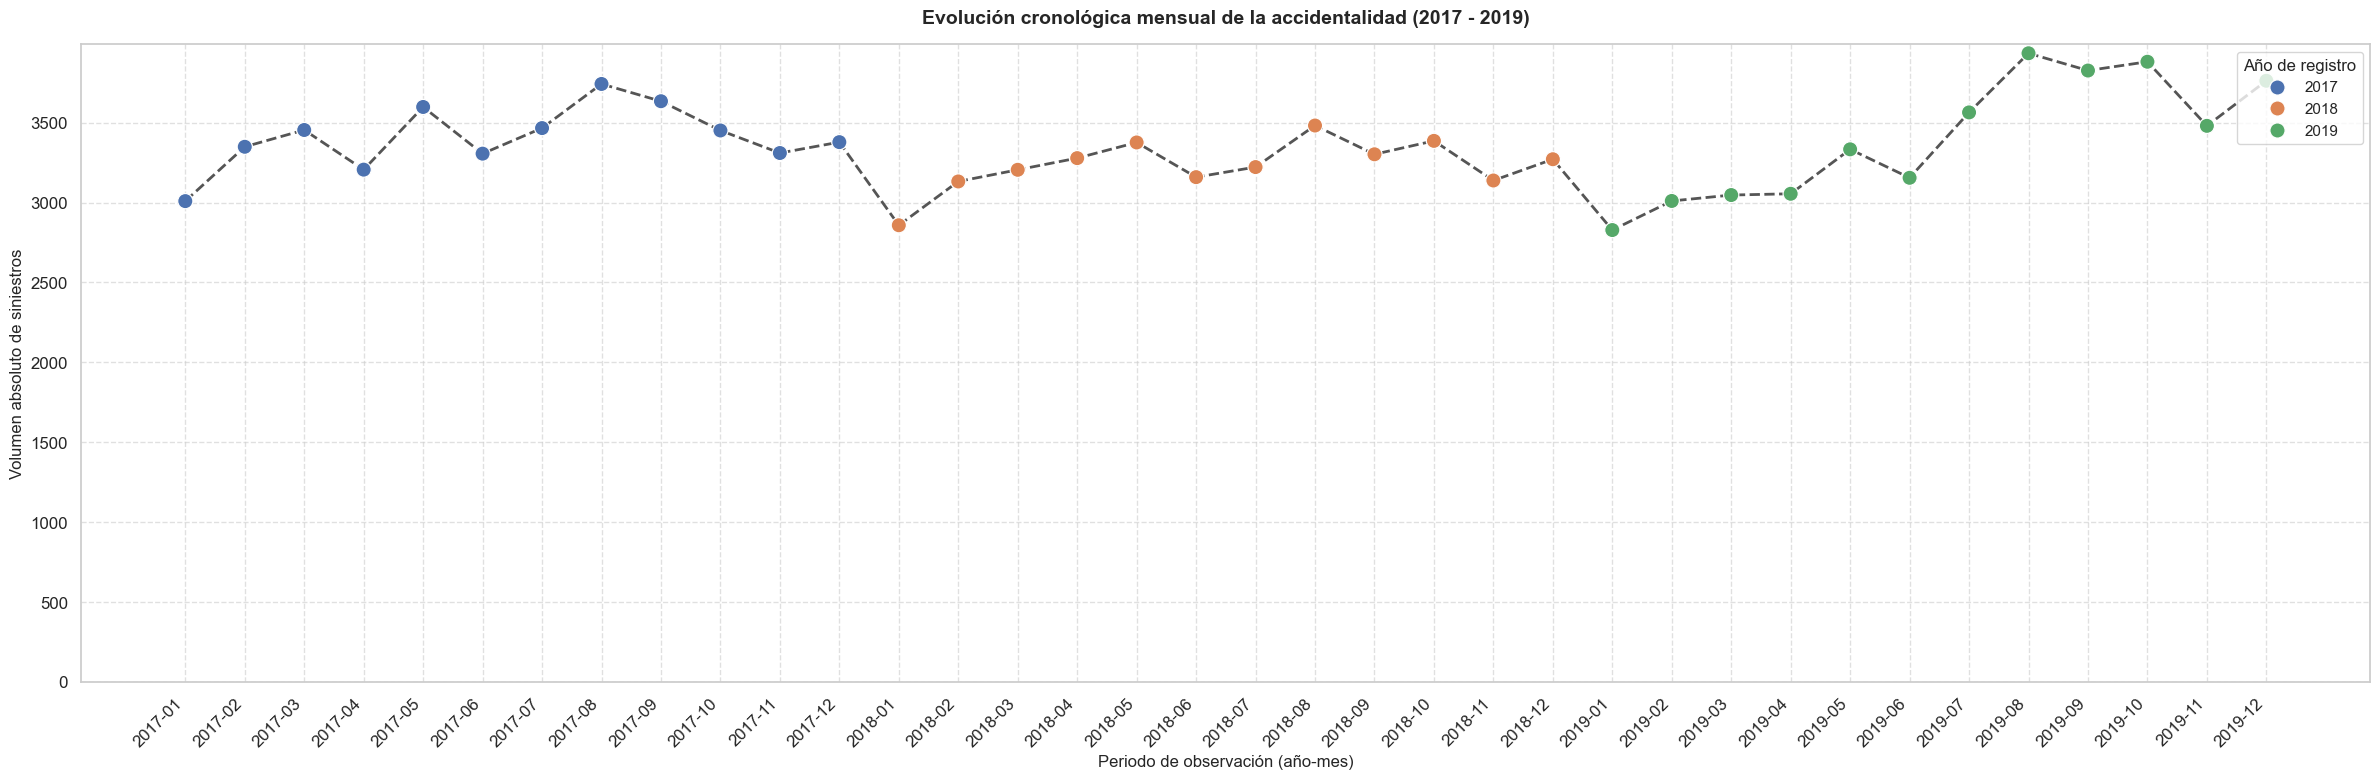

In [56]:
# =============================================================================
# Caracterización temporal: límites, macro-patrones y mapa de calor
# =============================================================================

# 1. Análisis de límites temporales inclusivos a nivel de fecha
fecha_inicial = df_accidentes['TW'].min()
fecha_final = df_accidentes['TW'].max()

# Conteo exacto de días transcurridos
cobertura_dias_calendario = (df_accidentes['TW'].dt.date.max() - df_accidentes['TW'].dt.date.min()).days + 1

print("="*70)
print("Auditoría temporal del dataset de accidentes")
print("="*70)
print(f"Fecha inicial:   {fecha_inicial.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Fecha final:     {fecha_final.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Cobertura total: {cobertura_dias_calendario} días calendario (inclusivo)\n")

# 2. Estadística descriptiva del volumen diario (total histórico vs anual)
# Agrupamiento por día completo para la serie de tiempo diaria
accidentes_diarios = df_accidentes.set_index('TW').resample('D').size()

# Resúmenes base
desc_global = accidentes_diarios.describe().to_frame(name='Total histórico')
desc_anual = accidentes_diarios.groupby(accidentes_diarios.index.year).describe().T

# Concatenación horizontal
tabla_descriptiva_completa = pd.concat([desc_global, desc_anual], axis=1)

# Inyección manual del volumen absoluto (suma)
suma_global = accidentes_diarios.sum()
suma_anual = accidentes_diarios.groupby(accidentes_diarios.index.year).sum()

fila_suma = pd.DataFrame(
    [[suma_global] + list(suma_anual.values)],
    columns=tabla_descriptiva_completa.columns,
    index=['sum']
)

# Reestructuración y reindexación formal de la tabla descriptiva
tabla_descriptiva_completa = pd.concat([tabla_descriptiva_completa, fila_suma])
orden_filas = ['count', 'sum', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
tabla_descriptiva_completa = tabla_descriptiva_completa.reindex(orden_filas)

print("Estadística descriptiva: volumen diario de accidentes")
display(tabla_descriptiva_completa.round(1))
print("-" * 70)

# 3. Extracción de componentes de fecha y tiempo para variables de análisis
df_accidentes['año'] = df_accidentes['TW'].dt.year
df_accidentes['mes'] = df_accidentes['TW'].dt.month
df_accidentes['hora'] = df_accidentes['TW'].dt.hour
df_accidentes['dia_semana'] = df_accidentes['TW'].dt.dayofweek



# 5. Gráfico B: Evolución mensual continua estructurada como gráfico de líneas (origen en 0)
evolucion_mensual = df_accidentes.groupby(['año', 'mes']).size().reset_index(name='total_accidentes')
evolucion_mensual['periodo'] = evolucion_mensual['año'].astype(str) + '-' + evolucion_mensual['mes'].astype(str).str.zfill(2)

fig_ev, ax_ev = plt.subplots(figsize=(24, 8))

sns.lineplot(
    data=evolucion_mensual,
    x='periodo',
    y='total_accidentes',
    color='#555555',
    linewidth=2,
    linestyle='--',
    ax=ax_ev,
    legend=False
)

sns.scatterplot(
    data=evolucion_mensual,
    x='periodo',
    y='total_accidentes',
    hue='año',
    palette='deep',
    s=120,
    zorder=5,
    ax=ax_ev
)

ax_ev.set_title('Evolución cronológica mensual de la accidentalidad (2017 - 2019)', fontweight='bold', fontsize=14, pad=15)
ax_ev.set_xlabel('Periodo de observación (año-mes)', fontsize=12)
ax_ev.set_ylabel('Volumen absoluto de siniestros', fontsize=12)
ax_ev.set_xticklabels(evolucion_mensual['periodo'], rotation=45, ha='right')
ax_ev.set_ylim(bottom=0)
ax_ev.grid(True, linestyle='--', alpha=0.6)
ax_ev.legend(title='Año de registro', loc='upper right', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('evolucion_mensual_lineas.png', bbox_inches='tight')

A lo largo de los 1,095 días analizados, se registra un volumen acumulado de 120,587 accidentes, manteniendo una media histórica de 110.1 siniestros diarios.

La serie cronológica mensual continua y la tabla descriptiva evidencian una fluctuación estructural notable en el año 2018. Mientras que 2017 y 2019 muestran un comportamiento simétrico con sumatorias idénticas (~40,900 accidentes al año y medias de ~112 diarios), el año 2018 registra una contracción significativa del riesgo, cayendo a 38,809 siniestros totales y reduciendo la media diaria a 106.3.

Al observar el gráfico continuo de líneas, se descarta una tendencia lineal de largo plazo decreciente. El comportamiento califica como un ciclo macro-estacional o una variación exógena puntual en 2018. Esto justifica metodológicamente por qué los modelos basados a consideran requerirán de características históricas de memoria estadística (lags y rolling means anuales) para autorregular posibles sesgos de tendencia.

**Ciclos estacionales agregados (Hora, Día y Mes)**:

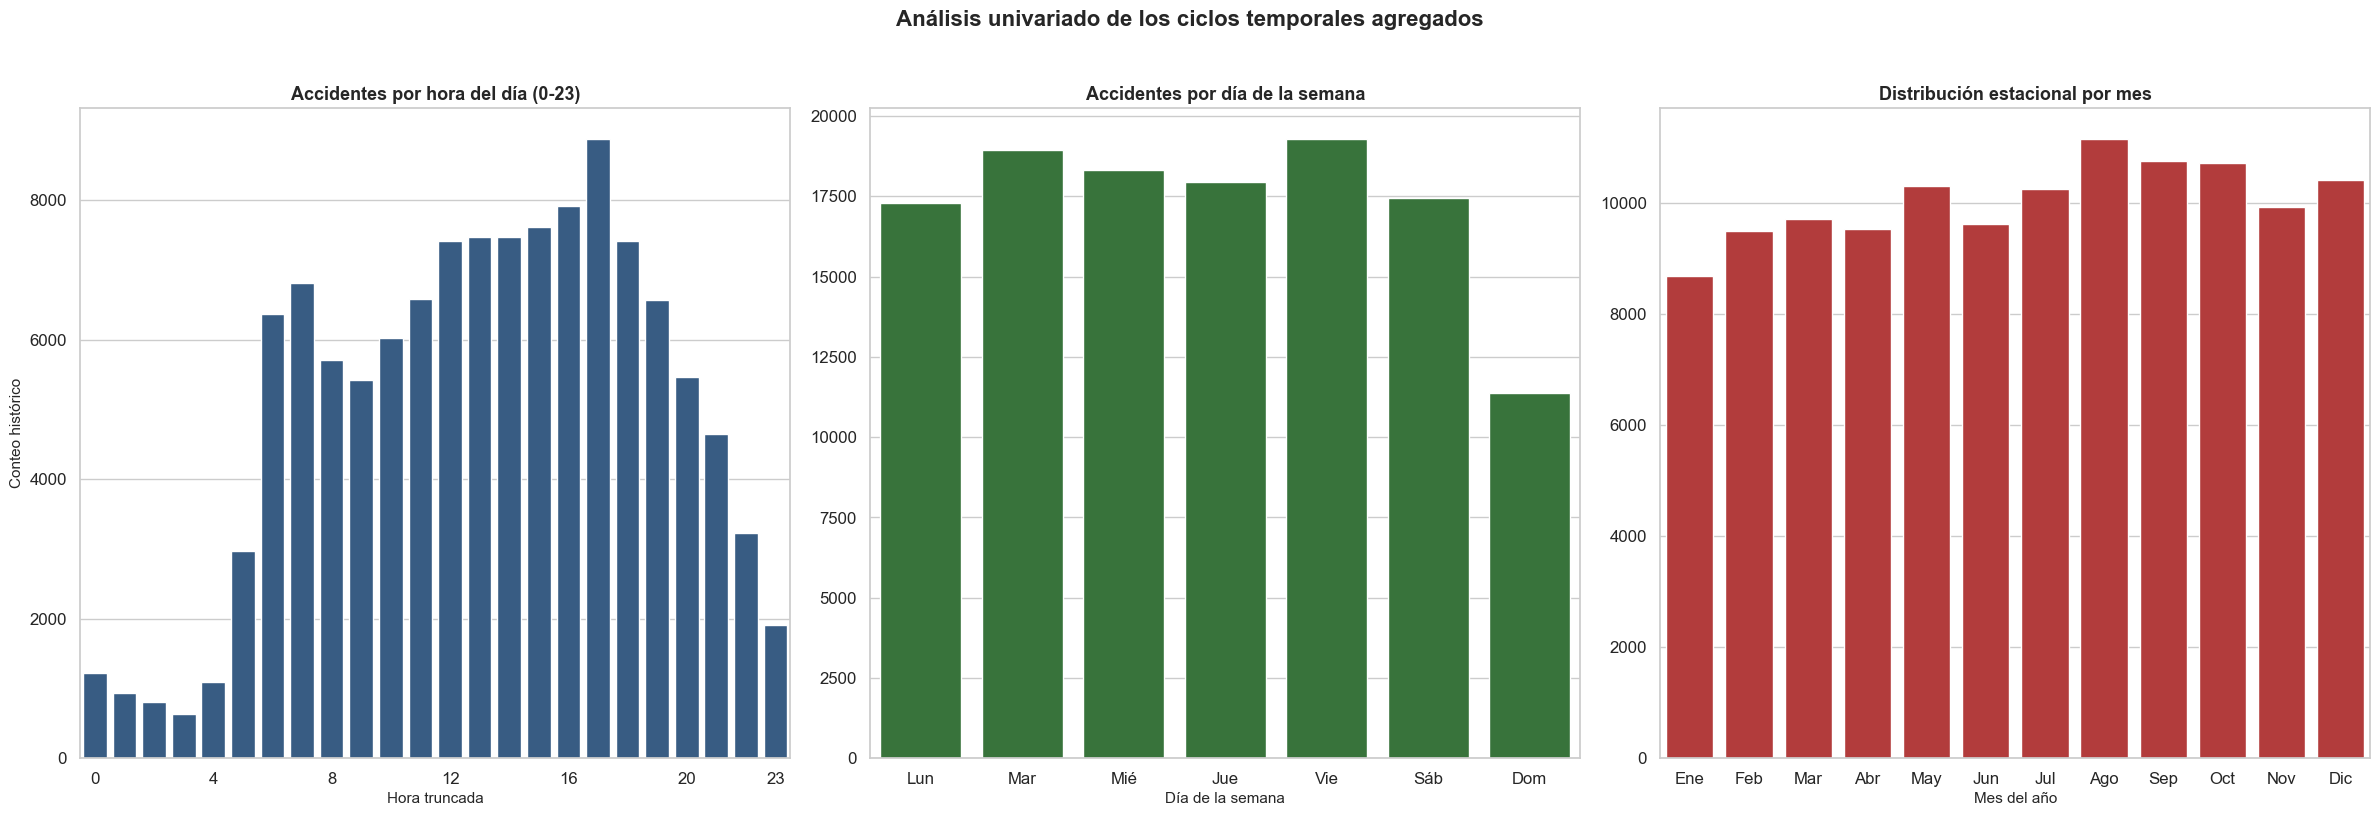

In [57]:
# 4. Gráfico A: Macro-patrones cíclicos univariados (origen en 0)
fig_ciclos, axes_ciclos = plt.subplots(1, 3, figsize=(24, 8))

# Subplot de horas
sns.countplot(data=df_accidentes, x='hora', color='#2b5c8f', ax=axes_ciclos[0])
axes_ciclos[0].set_title('Accidentes por hora del día (0-23)', fontweight='bold', fontsize=13)
axes_ciclos[0].set_xlabel('Hora truncada', fontsize=11)
axes_ciclos[0].set_ylabel('Conteo histórico', fontsize=11)
axes_ciclos[0].set_xticks([0, 4, 8, 12, 16, 20, 23])
axes_ciclos[0].set_ylim(bottom=0)

# Subplot de días de la semana
sns.countplot(data=df_accidentes, x='dia_semana', color='#2e7d32', ax=axes_ciclos[1])
axes_ciclos[1].set_title('Accidentes por día de la semana', fontweight='bold', fontsize=13)
axes_ciclos[1].set_xlabel('Día de la semana', fontsize=11)
axes_ciclos[1].set_ylabel('')
axes_ciclos[1].set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'])
axes_ciclos[1].set_ylim(bottom=0)

# Subplot de meses (ciclo anual regular)
sns.countplot(data=df_accidentes, x='mes', color='#c62828', ax=axes_ciclos[2])
axes_ciclos[2].set_title('Distribución estacional por mes', fontweight='bold', fontsize=13)
axes_ciclos[2].set_xlabel('Mes del año', fontsize=11)
axes_ciclos[2].set_ylabel('')
axes_ciclos[2].set_xticks(range(12))
axes_ciclos[2].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
axes_ciclos[2].set_ylim(bottom=0)

fig_ciclos.suptitle('Análisis univariado de los ciclos temporales agregados', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ciclos_temporales_expandidos.png', bbox_inches='tight')

**Estacionalidad Mensual:** La distribución por meses muestra valles pronunciados en los meses de enero y semana santa (usualmente marzo/abril), comportamiento consistente con las épocas de vacaciones colectivas y éxodo vehicular de la zona urbana. Por el contrario, los picos de accidentalidad se concentran en agosoto y algunos meses al cierre del año. Más adelante intentaremos visualizar si hay alguna correlación con las temporadas de lluvias.

**Estacionalidad Semanal:** El volumen de siniestros diarios se mantiene relativamente estable a medida que avanza la semana laboral, pero el viernes se consolida como el día más crítico del ciclo semanal. El domingo opera como el valle de la serie, comportamiento relacionado con las disminuciones naturales de movilidad laboral.


**Estacionalidad por hora**: Se observan concentraciones críticas de accidentes en las franjas de 07:00 a 09:00 y de 17:00 a 19:00. Estas celdas corresponden exactamente a las "horas pico" de conmutación laboral y académica, donde la saturación de las vías incrementa exponencialmente la probabilidad de colisiones. Como se observa en el mapa de calor generado por el codigo de la siguiente celda, el viernes expande su ventana de peligro de forma continua desde las 14:00 hasta las 19:00. Esto refleja una aceleración del riesgo asociada a la salida anticipada de las jornadas laborales combinada con el inicio de actividades de ocio de fin de semana. El mapa de calor demuestra que durante el fin de semana el riesgo migra de las horas de oficina hacia las franjas de la madrugada (01:00 a 05:00) y la tarde recreativa. El domingo en la madrugada registra densidades de accidentalidad cualitativamente superiores a las madrugadas de los días laborables, lo que vincula el fenómeno a lógicas de conducción bajo fatiga o estado de embriaguez.

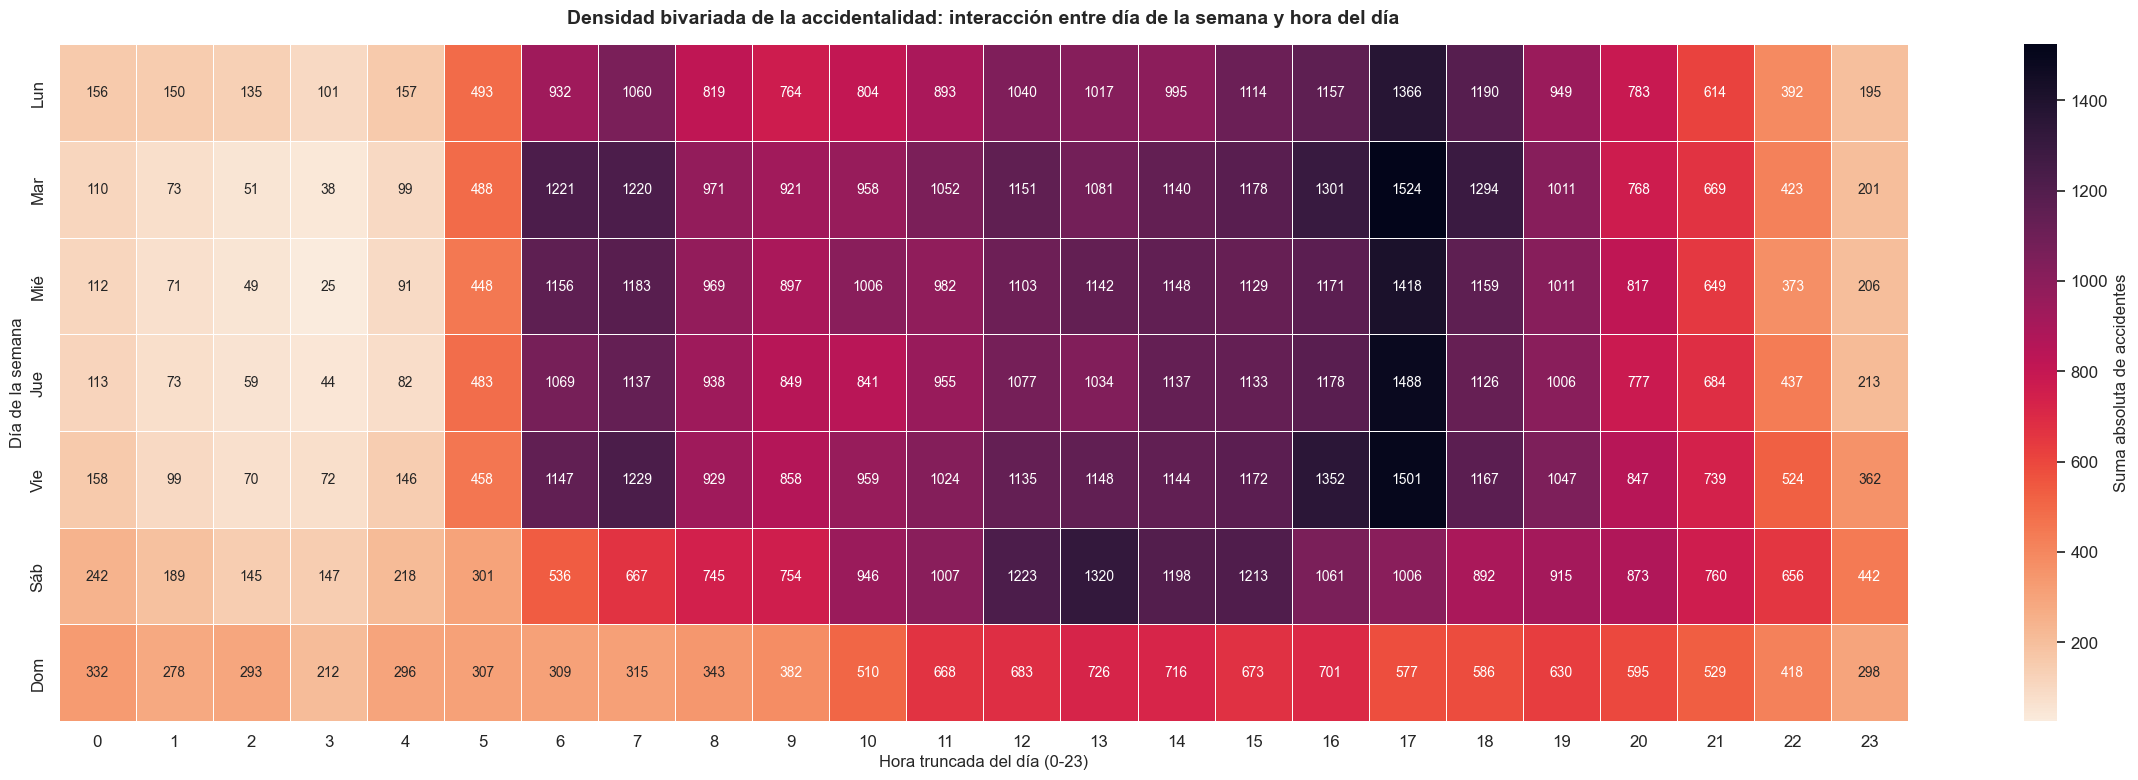

In [58]:
# 6. Gráfico C: Mapa de calor de interacciones bivariadas (día de la semana vs hora)
# Se construye la matriz de contingencia calculando la sumatoria de eventos por celda
matriz_tiempo = df_accidentes.groupby(['dia_semana', 'hora']).size().unstack(fill_value=0)
matriz_tiempo.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig_heat, ax_heat = plt.subplots(figsize=(24, 8))

# Se utiliza una paleta secuencial perceptualmente uniforme (rocket_r) para resaltar los picos
sns.heatmap(
    matriz_tiempo,
    cmap='rocket_r',
    annot=True,
    fmt='d',
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={'label': 'Suma absoluta de accidentes'},
    ax=ax_heat
)

ax_heat.set_title('Densidad bivariada de la accidentalidad: interacción entre día de la semana y hora del día', fontweight='bold', fontsize=14, pad=15)
ax_heat.set_xlabel('Hora truncada del día (0-23)', fontsize=12)
ax_heat.set_ylabel('Día de la semana', fontsize=12)

plt.tight_layout()
plt.savefig('heatmap_interaccion_temporal.png', bbox_inches='tight')

**Justificación técnica para la Ingeniería de Características**

Estos hallazgos demuestran de forma empírica que entrenar los modelos utilizando las variables de tiempo como factores independientes lineales (ej. tratar la hora simplemente como un entero de 0 a 23) destruirá el desempeño predictivo.

La evidencia analítica recolectada obliga a:

- Implementar la transformación cíclica (senos y cosenos) de las horas y los días de la semana para que el algoritmo interprete la cercanía geométrica entre las 23:00 y las 00:00.

- Construir variables de interacción bivariadas explícitas (ej. multiplicadores de día_laboral × hora_pico) para dotar al modelo de la capacidad de segmentar los picos de conmutación diaria frente a los riesgos de la madrugada del fin de semana

- Dado que los días festivos en Colombia alteran los patrones típicos de conmutación urbana y mimetizan el comportamiento del fin de semana, se identifica la necesidad de inyectar un clasificador de días feriados en la etapa de ingeniería de características

### **3.2. Distribución espacial de la accidentalidad**

In [59]:
display(df_accidentes)
display(df_raw)

,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora,año,mes,hora,dia_semana
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570145,JUEVES,7,20,8,2017,7,8,3
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600281,JUEVES,6,15,16,2017,6,16,3
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584305,DOMINGO,7,2,16,2017,7,16,6
3,2017-03-29 18:00:00,losconquistadores,6.239497,-75.583061,MIERCOLES,3,29,18,2017,3,18,2
4,2017-07-26 20:00:00,cuartabrigada,6.260463,-75.590195,MIERCOLES,7,26,20,2017,7,20,2
...,...,...,...,...,...,...,...,...,...,...,...,...
120582,2019-03-19 07:00:00,lafloresta,6.257358,-75.603531,MARTES,3,19,7,2019,3,7,1
120583,2019-02-04 07:00:00,alejandroechavarria,6.239886,-75.550865,LUNES,2,4,7,2019,2,7,0
120584,2019-06-18 14:00:00,moscuno1,6.293053,-75.554840,MARTES,6,18,14,2019,6,14,1
120585,2019-05-08 18:00:00,boyaca,6.301662,-75.567131,MIERCOLES,5,8,18,2019,5,18,2


,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.570145,6.233985,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,1020,Malla vial,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,NaN,8,2017-07-20 08:00:00
1,-75.600281,6.238844,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,1109,Malla vial,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,NaN,16,2017-06-15 16:00:00
2,-75.584305,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,0710,Malla vial,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,NaN,16,2017-07-02 16:00:00
3,-75.583061,6.239497,504355,1576853,06:29 PM,MIERCOLES,2017,Choque,CL 33 Norte CR 65,CL 033 065 000 00000,1105,Malla vial,SOLO DAÑOS,losconquistadores,Laureles Estadio,Tramo de via,3,29,2017-03-29,NaN,18,2017-03-29 18:00:00
4,-75.590195,6.260463,504356,1591283,08:10 PM,MIERCOLES,2017,Atropello,CL 50 CR 74,CL 050 074 000 00000,1115,Malla vial,HERIDO,cuartabrigada,Laureles Estadio,Tramo de via,7,26,2017-07-26,NaN,20,2017-07-26 20:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125117,-75.574532,6.246080,726806,1673279,2:20:00 p. m.,MARTES,2019,Caida Ocupante,CR 55 CL 44,CR 055 044 000 00000,1007,Malla vial,HERIDO,guayaquil,La Candelaria,Tramo de via,6,4,2019-06-04,JUNIO,14,2019-06-04 14:00:00
125118,-75.550865,6.239886,726807,1659105,7:05:00 a. m.,LUNES,2019,Choque,CL 49 CR 27 A,CL 049 027 A 000 00000,0905,Malla vial,HERIDO,alejandroechavarria,Buenos Aires,Interseccion,2,4,2019-02-04,FEBRERO,7,2019-02-04 07:00:00
125119,-75.554840,6.293053,726809,1675103,2:00:00 p. m.,MARTES,2019,Choque,CR 48 A CL 102,CR 048 A 102 000 00000,0209,Malla vial cruce invertido,SOLO DAÑOS,moscuno1,Santa Cruz,Tramo de via,6,18,2019-06-18,JUNIO,14,2019-06-18 14:00:00
125120,-75.567131,6.301662,726810,1669874,6:35:00 p. m.,MIERCOLES,2019,Choque,CR 67 CL 104 A,CR 067 104 A 000 00000,0505,Malla vial,SOLO DAÑOS,boyaca,Castilla,Tramo de via,5,8,2019-05-08,MAYO,18,2019-05-08 18:00:00


In [60]:
# =============================================================================
# Auditoría de Reconciliación Espacial: df_raw vs df_accidentes
# =============================================================================
import pandas as pd

print("="*70)
print("AUDITORÍA DE RECONCILIACIÓN ESPACIAL (RAW vs ACCIDENTES)")
print("="*70)

# 1. Calcular el volumen absoluto de accidentes por barrio en ambas tablas
# Asumimos que en ambas tablas cada fila es un accidente (log de eventos)
conteo_raw = df_raw['BARRIO'].value_counts().rename('accidentes_raw')
conteo_acc = df_accidentes['BARRIO'].value_counts().rename('accidentes_limpios')

# 2. Unir ambos conteos para compararlos barrio a barrio
df_reconciliacion = pd.concat([conteo_raw, conteo_acc], axis=1).fillna(0)

# 3. Calcular la diferencia matemática
df_reconciliacion['diferencia'] = df_reconciliacion['accidentes_raw'] - df_reconciliacion['accidentes_limpios']

# 4. Diagnóstico de pérdida de datos
barrios_con_perdida = df_reconciliacion[df_reconciliacion['diferencia'] != 0]

if barrios_con_perdida.empty:
    print("✅ RECONCILIACIÓN EXITOSA: La volumetría por barrio coincide perfectamente.")
else:
    print(f"⚠️ ALERTA: Se detectaron {len(barrios_con_perdida)} barrios con diferencias volumétricas.")
    print("Top 5 barrios con mayor diferencia (Raw - Limpio):")
    display(barrios_con_perdida.sort_values('diferencia', ascending=False).head())
print("-" * 70)

# =============================================================================
# EXTRACCIÓN E INYECCIÓN DEL MAPEO COMUNA -> BARRIO
# =============================================================================
print("Inyectando jerarquía espacial (Comuna) desde df_raw hacia df_accidentes...")

# 1. Extraer el diccionario único de relaciones Barrio -> Comuna desde df_raw
# Eliminamos duplicados para tener la tabla de verdad geográfica
mapeo_geografico = df_raw[['BARRIO', 'COMUNA']].dropna().drop_duplicates(subset=['BARRIO'])

# Convertimos a diccionario para un mapeo hiper-rápido en RAM (O(1))
dict_barrio_comuna = dict(zip(mapeo_geografico['BARRIO'], mapeo_geografico['COMUNA']))

# 2. Inyectar la Comuna en df_accidentes respetando la categorización
df_accidentes['COMUNA'] = df_accidentes['BARRIO'].map(dict_barrio_comuna)

# 3. Validar si quedaron barrios huérfanos de Comuna
barrios_sin_comuna = df_accidentes[df_accidentes['COMUNA'].isna()]['BARRIO'].unique()

if len(barrios_sin_comuna) > 0:
    print(f"⚠️ ADVERTENCIA: Hay {len(barrios_sin_comuna)} barrios en df_accidentes que no tienen Comuna en df_raw.")
    print(f"Ejemplos: {barrios_sin_comuna[:3]}")
    # Rellenar con 'SIN INFO' para que no rompa las gráficas
    df_accidentes['COMUNA'] = df_accidentes['COMUNA'].fillna('SIN_INFO_COMUNA')
else:
    print("✅ Mapeo completado. Todos los barrios tienen su comuna asignada.")

# 4. Crear la variable combinada solicitada para los gráficos posteriores
df_accidentes['Comuna-Barrio'] = df_accidentes['COMUNA'].astype(str) + ' - ' + df_accidentes['BARRIO'].astype(str)

print("Variable 'Comuna-Barrio' creada exitosamente y lista para visualización.")
print("="*70)

AUDITORÍA DE RECONCILIACIÓN ESPACIAL (RAW vs ACCIDENTES)
⚠️ ALERTA: Se detectaron 223 barrios con diferencias volumétricas.
Top 5 barrios con mayor diferencia (Raw - Limpio):


,accidentes_raw,accidentes_limpios,diferencia
BARRIO,,,
lacandelaria,3037,2734,303
campoamor,2785,2533,252
perpetuosocorro,2534,2320,214
caribe,2506,2297,209
santafe,2169,1994,175


----------------------------------------------------------------------
Inyectando jerarquía espacial (Comuna) desde df_raw hacia df_accidentes...
✅ Mapeo completado. Todos los barrios tienen su comuna asignada.
Variable 'Comuna-Barrio' creada exitosamente y lista para visualización.


**Nota analítica: auditoría de reconciliación espacial y pérdida de masa volumétrica**

Al contrastar la tabla de eventos puros (`df_raw`) contra la tabla estructurada para el modelado (`df_accidentes`), se identificó una asimetría volumétrica sistemática distribuida en **223 barrios**. El top 5 de zonas críticas exhibe una contracción del riesgo que oscila entre el 8% y el 10% de sus registros históricos (por ejemplo, `lacandelaria` pasa de 3,037 a 2,734 registros, perdiendo 303 observaciones). 

Esta discrepancia es un comportamiento esperado en sistemas complejos de información y **está fuera del control del pipeline de optimización actual**, ya que obedece a un preprocesamiento previo. No obstante, estas diferencias pueden responder a **Depuración por criterios de calidad de datos (filtros exógenos)** o a **Colapso por co-ocurrencia espacio-temporal (agregación indexada)**. Se asume que no hay errores dado que el taller la describe como "la fuente natural para construir la variable objetivo".

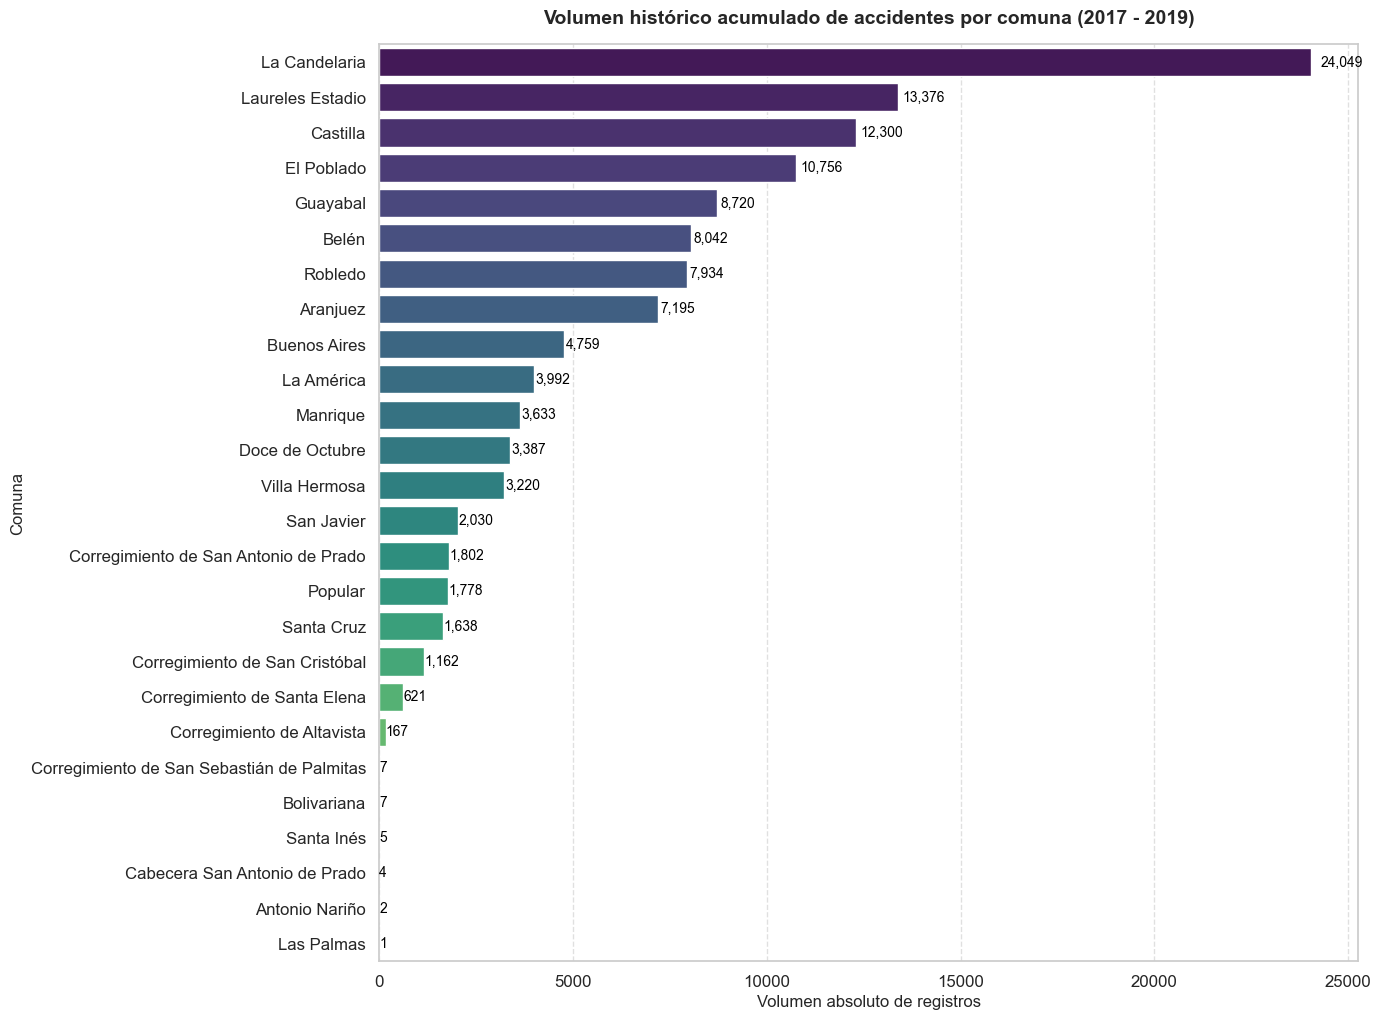

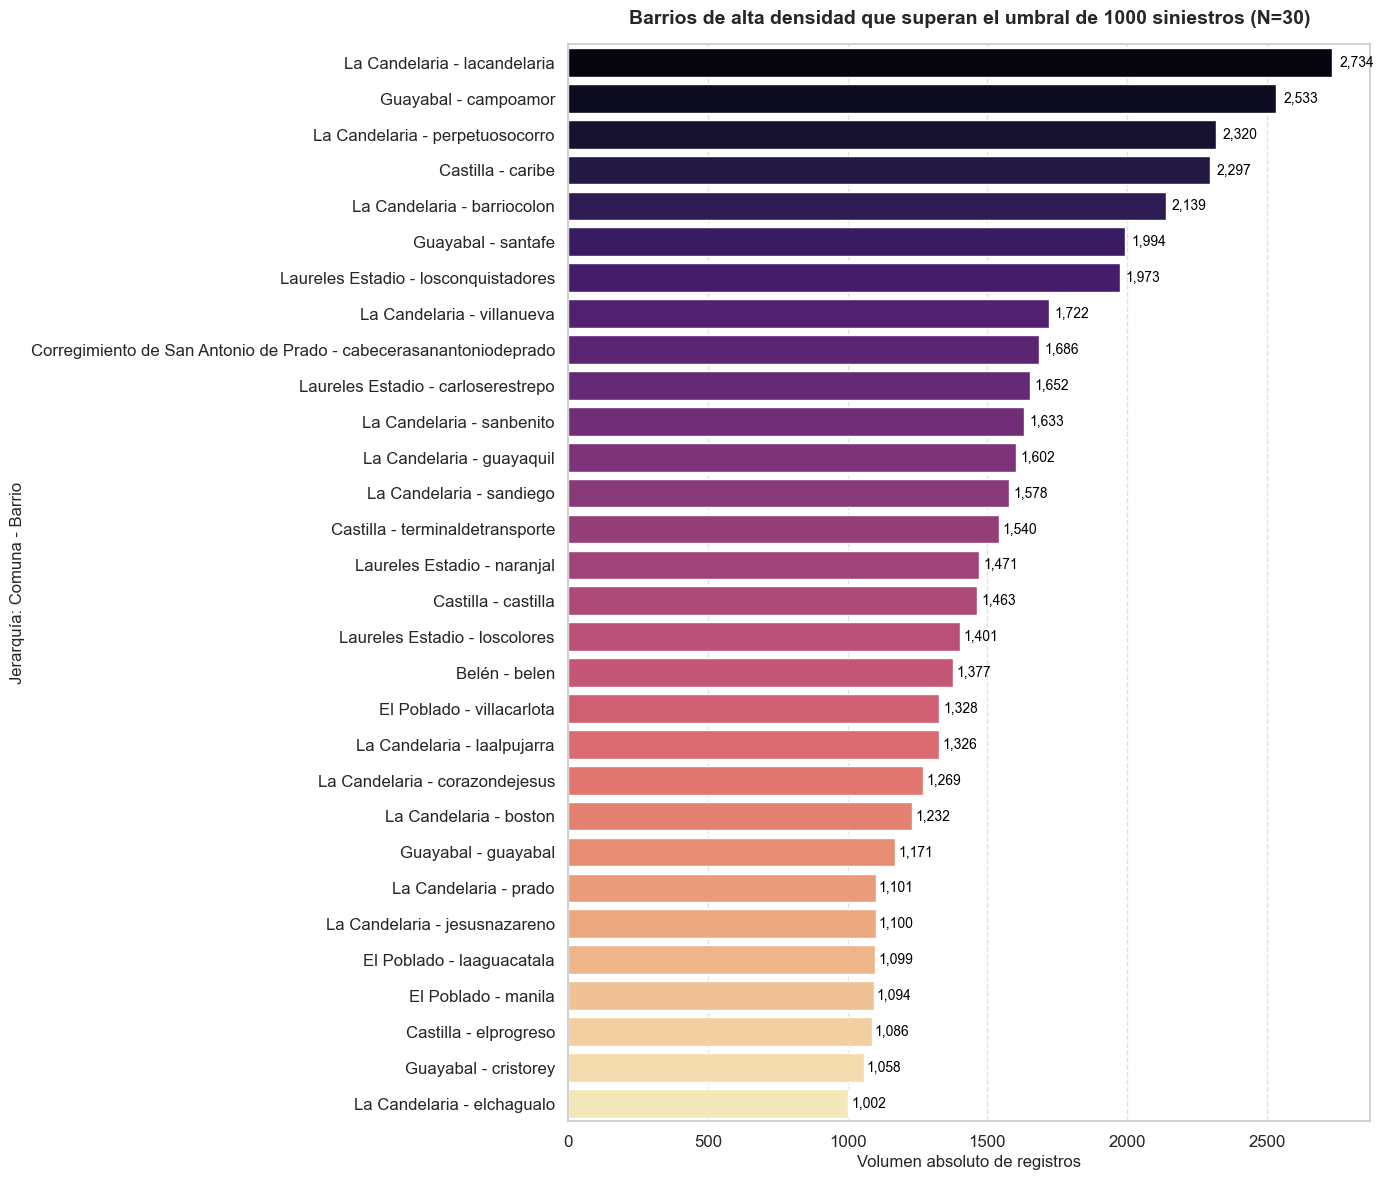

In [61]:
# =============================================================================
# 4.1.2 Caracterización espacial: visualización de jerarquías y top de riesgo
# =============================================================================

# -----------------------------------------------------------------------------
# Gráfico 1: Distribución completa por comunas (macro-entorno)
# -----------------------------------------------------------------------------
# Agregación y ordenamiento descendente estricto
frecuencia_comunas = df_accidentes['COMUNA'].value_counts().sort_values(ascending=False)

# Definición del lienzo mediante subplots (altura dinámica basada en categorías)
altura_comunas = max(8.0, len(frecuencia_comunas) * 0.4)
fig_comuna, ax_comuna = plt.subplots(figsize=(14, altura_comunas))

# Renderizado utilizando una paleta secuencial de alta legibilidad
sns.barplot(
    x=frecuencia_comunas.values, 
    y=frecuencia_comunas.index.astype(str), 
    palette='viridis', 
    ax=ax_comuna
)

# Configuración estética y blindaje de la línea base en 0
ax_comuna.set_title('Volumen histórico acumulado de accidentes por comuna (2017 - 2019)', fontweight='bold', fontsize=14, pad=15)
ax_comuna.set_xlabel('Volumen absoluto de registros', fontsize=12)
ax_comuna.set_ylabel('Comuna', fontsize=12)
ax_comuna.set_xlim(left=0)  # Forzar inicio del eje en cero absoluto

# Inyección de etiquetas numéricas con formato de millares
for i, v in enumerate(frecuencia_comunas.values):
    ax_comuna.text(v + (v * 0.01), i, f"{v:,}", color='black', va='center', fontsize=10)

ax_comuna.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribucion_espacial_comunas_total.png', bbox_inches='tight')

# -----------------------------------------------------------------------------
# Gráfico 2: Top barrios con más de 1.000 accidentes (contexto comuna-barrio)
# -----------------------------------------------------------------------------
# Definición del umbral operativo de alta densidad
UMBRAL_ACCIDENTES = 1000

# Agregación y filtrado por la variable combinada jerárquica
frecuencia_cb = df_accidentes['Comuna-Barrio'].value_counts()
barrios_significativos = frecuencia_cb[frecuencia_cb >= UMBRAL_ACCIDENTES].sort_values(ascending=False)

cantidad_barrios_significativos = len(barrios_significativos)

# Definición del lienzo específico para el desglose de barrios
altura_barrios = max(8.0, cantidad_barrios_significativos * 0.4)
fig_cb, ax_cb = plt.subplots(figsize=(14, altura_barrios))

# Renderizado con paleta de alto contraste para puntos calientes (hotspots)
sns.barplot(
    x=barrios_significativos.values, 
    y=barrios_significativos.index.astype(str), 
    palette='magma', 
    ax=ax_cb
)

# Ajustes de títulos y control del origen geométrico
ax_cb.set_title(f'Barrios de alta densidad que superan el umbral de {UMBRAL_ACCIDENTES} siniestros (N={cantidad_barrios_significativos})', fontweight='bold', fontsize=14, pad=15)
ax_cb.set_xlabel('Volumen absoluto de registros', fontsize=12)
ax_cb.set_ylabel('Jerarquía: Comuna - Barrio', fontsize=12)
ax_cb.set_xlim(left=0)  # Forzar inicio del eje en cero absoluto

# Inyección de etiquetas de datos al final de cada barra
for i, v in enumerate(barrios_significativos.values):
    ax_cb.text(v + (v * 0.01), i, f"{v:,}", color='black', va='center', fontsize=10)

ax_cb.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('distribucion_espacial_comuna_barrio_1000.png', bbox_inches='tight')

Descargando archivo desde Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1bxxsP-_a9x8jNMvYIGHNYL5viSbqJBoL
To: g:\Mi unidad\01 MAESTRÍA\01_SEMESTRE\04_Machine_Learning\03_Taller\comunas_temp.zip
100%|██████████| 3.49M/3.49M [00:10<00:00, 340kB/s]


Descomprimiendo el archivo...
¡Mapa exportado con éxito!


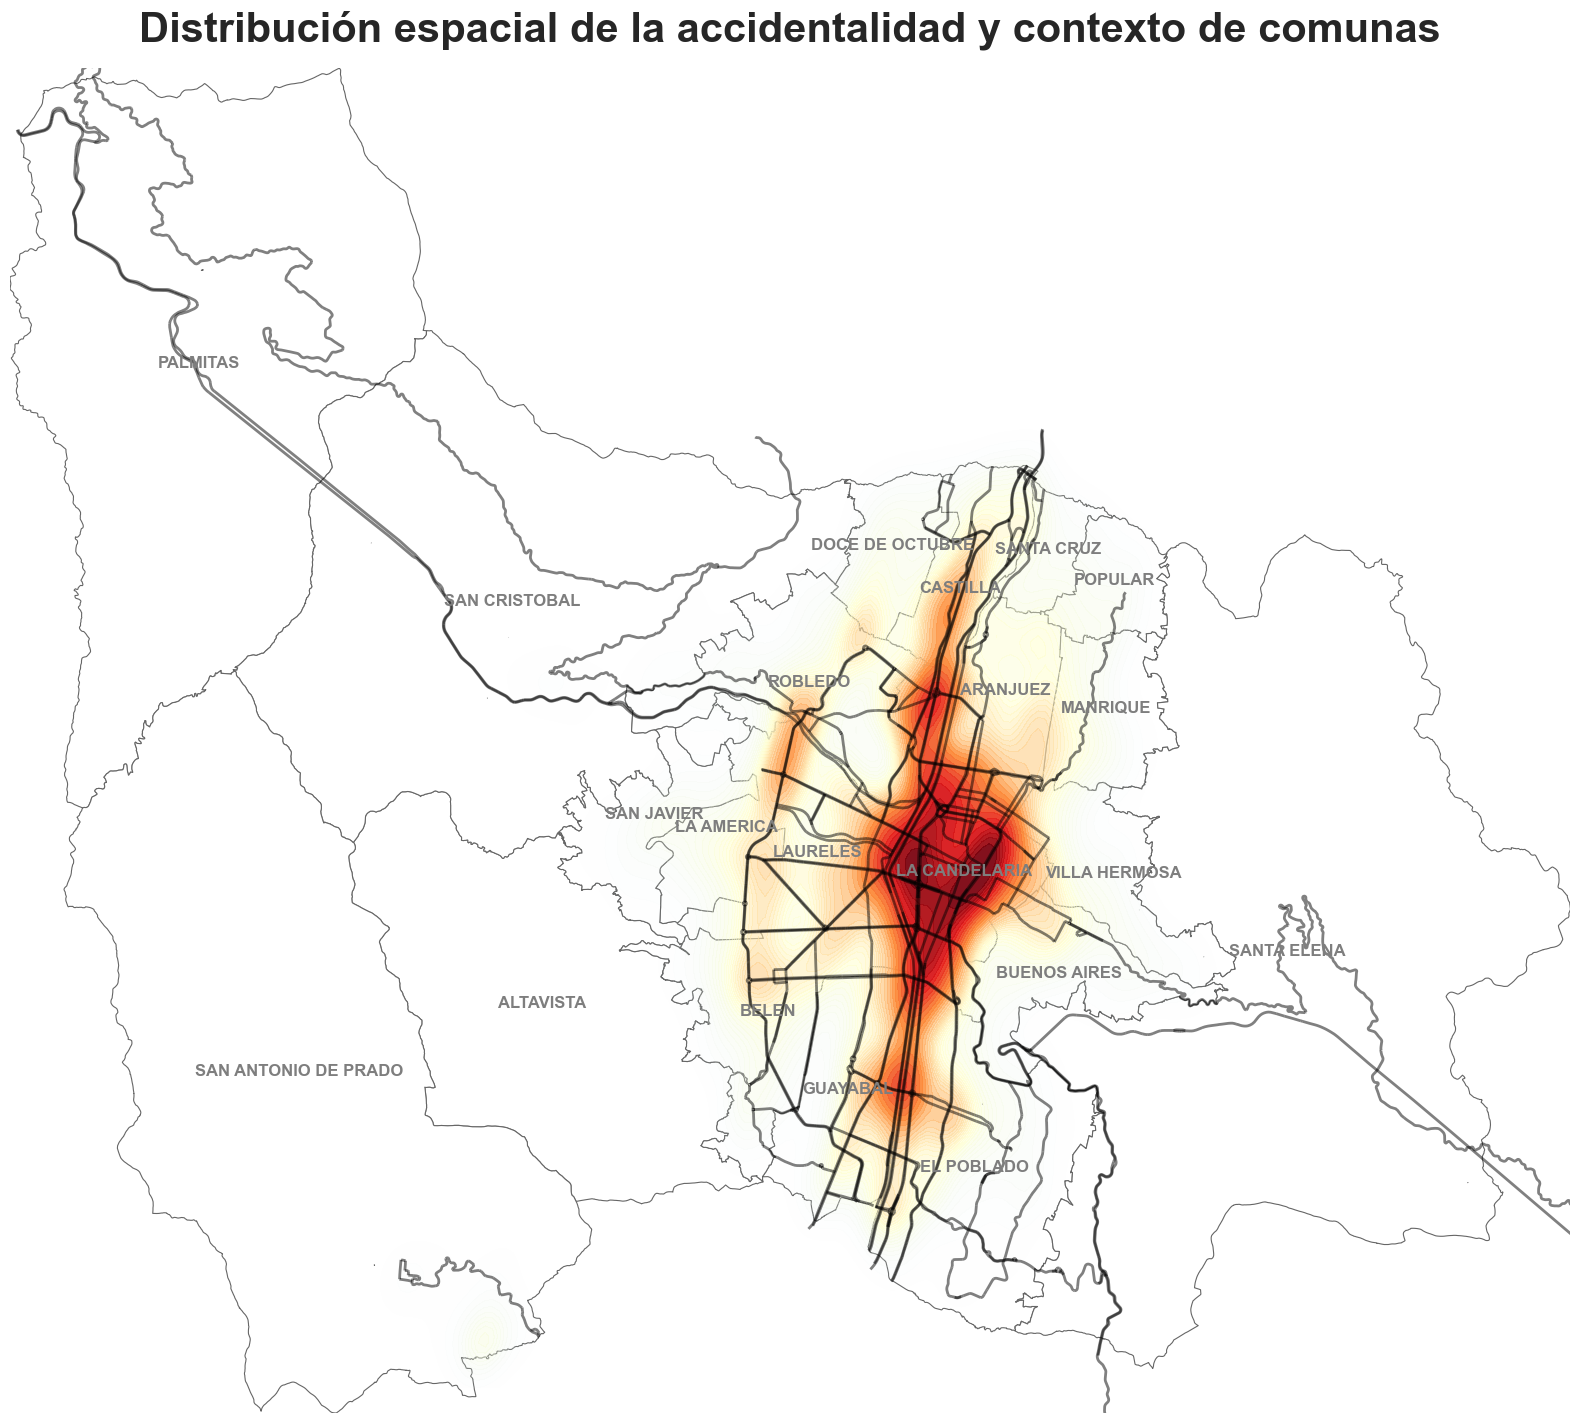

In [62]:
# =============================================================================
# Mapa de densidad espacial
# =============================================================================
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown  
import os
import zipfile
import glob
import osmnx as ox
import numpy as np
import matplotlib.colors as mcolors

# 1. Configuración del área de interés (Medellín, Colombia)
place_name = "Medellín, Colombia"

# 2. Descarga de vías principales usando osmnx
tags = {'highway': ['motorway', 'trunk', 'primary', 'secondary']}
vias_principales = ox.features_from_place(place_name, tags=tags)
vias_principales = vias_principales.to_crs("EPSG:4326")

# 3. Importación desde Google Drive y extracción segura
file_id = "1bxxsP-_a9x8jNMvYIGHNYL5viSbqJBoL"
ruta_zip_temporal = "comunas_temp.zip"
carpeta_extraccion = "comunas_extraidas"

print("Descargando archivo desde Google Drive...")
gdown.download(id=file_id, output=ruta_zip_temporal, quiet=False)

print("Descomprimiendo el archivo...")
with zipfile.ZipFile(ruta_zip_temporal, 'r') as zip_ref:
    zip_ref.extractall(carpeta_extraccion)

archivos_shp = glob.glob(f"{carpeta_extraccion}/**/*.shp", recursive=True)
if not archivos_shp:
    raise ValueError("Error: No se encontró ningún archivo .shp dentro del ZIP.")

ruta_shp = archivos_shp[0]
gdf_comunas = gpd.read_file(ruta_shp)

# 4. Asegurar alineación de sistemas de referencia (CRS)
gdf_accidentes = gpd.GeoDataFrame(
    df_accidentes, 
    geometry=gpd.points_from_xy(df_accidentes['Lon'], df_accidentes['Lat']),
    crs="EPSG:4326"
)

gdf_comunas = gdf_comunas.to_crs("EPSG:4326")
vias_principales = vias_principales.to_crs("EPSG:4326")

# 5. Definir límites del área de estudio
minx, miny, maxx, maxy = gdf_comunas.total_bounds

# 6. Definición del lienzo
fig_mapa, ax_mapa = plt.subplots(figsize=(16, 16))

# Capa 1: Comunas (Fondo) - ZORDER 1
gdf_comunas.plot(ax=ax_mapa, color='#ffffff', edgecolor='#666666', linewidth=0.8, zorder=1)

# =============================================================================
# NUEVA PALETA Y TRUCO DE TRANSPARENCIA
# =============================================================================
# Definimos los colores basados en tu imagen:
# Verde marino claro -> Amarillo pálido -> Naranja -> Rojo -> Vinotinto
colores_hex = ['#e0f3f8', '#ffffcc', '#fd8d3c', '#e31a1c', '#67000d']
cmap_base = mcolors.LinearSegmentedColormap.from_list('mi_paleta', colores_hex)

# Extraemos 256 niveles de la paleta
colores = cmap_base(np.linspace(0, 1, 256))

# Ajustamos la transparencia de forma inteligente:
# Hacemos que los valores bajos sean transparentes (0), pero que la opacidad 
# suba rápido a casi sólido (0.95) para que el centro no se vea débil.
alphas = np.linspace(0, 1, 256)
colores[:, 3] = np.clip(alphas * 2.0, 0, 0.95) 
cmap_vinotinto = mcolors.LinearSegmentedColormap.from_list('paleta_vinotinto', colores)

# Capa 2: Densidad de accidentes (KDE) - ZORDER 2 (DEBAJO DE LAS VÍAS)
sns.kdeplot(
    data=df_accidentes,
    x='Lon', 
    y='Lat',
    fill=True,
    thresh=0.02, # Mantenemos el umbral bajo para conservar el halo exterior
    levels=40,   # Alto nivel de detalle en las curvas
    cmap=cmap_vinotinto, # Aplicamos la nueva paleta
    cut=0, 
    ax=ax_mapa,
    zorder=2
)

# Capa 3: Vías principales - ZORDER 3
vias_principales.plot(ax=ax_mapa, color="#020202", linewidth=2, alpha=0.5, zorder=3)

# Capa 4: Etiquetas de comunas - ZORDER 4
for idx, row in gdf_comunas.iterrows():
    ax_mapa.text(
        s=row['NOMBRE'], 
        x=row.geometry.centroid.x, 
        y=row.geometry.centroid.y, 
        fontsize=12, 
        color="#7E7E7E", 
        ha='center', 
        fontweight='bold',
        zorder=4
    )

# 7. Ajustar límites al área urbana y quitar ejes
ax_mapa.set_xlim(minx, maxx)
ax_mapa.set_ylim(miny, maxy)
ax_mapa.set_axis_off()

# 8. Estética final
ax_mapa.set_title('Distribución espacial de la accidentalidad y contexto de comunas', fontweight='bold', fontsize=30, pad=20)

plt.tight_layout()
plt.savefig('mapa_comunas_etiquetado.png', bbox_inches='tight', dpi=300) 
print("¡Mapa exportado con éxito!")

**Análisis y diagnóstico de la distribución espacial**

La proyección de los registros históricos sobre las dimensiones geográficas de la ciudad confirma la hipótesis de **autocorrelación espacial positiva**: los accidentes de tránsito no son eventos aleatorios o uniformemente distribuidos en el territorio, sino fenómenos estructuralmente anclados a la jerarquía vial y a la vocación del uso del suelo.

* El análisis de agregación por comunas revela una asimetría extrema liderada por **La Candelaria** (Centro de la ciudad), la cual acumula más de 23,000 accidentes. Este volumen duplica e incluso triplica a las comunas que le siguen en la distribución (Castilla y Laureles-Estadio). Este comportamiento es coherente con el concepto de "población flotante": La Candelaria concentra la mayor densidad comercial, institucional y de nodos de transferencia de transporte público del Valle de Aburrá, atrayendo flujos vehiculares masivos que no necesariamente residen en la zona.


* Al aplicar un umbral estricto de significancia espacial (barrios con más de 1,000 registros), confirmamos la dominancia del centro: múltiples barrios críticos pertenecen a **La Candelaria** (La Candelaria, Perpetuo Socorro, Santa Fe, Boston, Bomboná). Sin embargo, emergen "hotspots" secundarios de altísimo riesgo periféricos al centro tradicional: **Campoamor** (Comuna Guayabal) y **Caribe** (Comuna Castilla). Estos sectores se caracterizan por albergar terminales de transporte, zonas industriales y conexiones directas con los principales ejes logísticos y residenciales de la ciudad y sus alrededores.

* La proyección de los datos sobre la infraestructura física mediante el mapa de densidad espacial confirma visualmente que el riesgo máximo forma una mancha elíptica concentrada en el centroide geográfico del mapa. Adicionalmente, se observa un efecto de "arrastre" o elongación de la densidad a lo largo del eje del río Medellín, trazando exactamente la ruta de las vías de más alta jerarquía (Autopista Norte/Sur y Avenida Regional). 

**Justificación técnica para el modelado**:

Esta evaluación univariada demuestra que el modelo de Machine Learning necesitará obligatoriamente asimilar el contexto espacial. La variable `Comuna` captura de manera macroscópica y eficiente la mayor parte de la varianza del riesgo vial. Utilizar únicamente `Barrio` como predictor podría introducir alta cardinalidad y ruido, por lo que la nueva variable combinada `Comuna-Barrio` o el uso directo de la Comuna como nodo agrupador podría ser crucial para la arquitectura de árboles de decisión (*boosting*).

### **3.3. Caracterización del clima**

In [63]:
print(df_clima.shape)
display(df_clima)

(7991780, 15)


,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0000,0.00,16.43,16.430000,14.00,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0000,0.00,16.43,16.430000,14.00,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0000,0.00,15.43,15.430000,13.00,0.85,1.02,NaN,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,fog,0.0000,0.00,15.43,15.430000,13.00,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,fog,0.0000,0.00,15.43,15.430000,13.00,0.85,2.09,350.0,1.00,0.0,0.099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7991775,2019-12-31 19:00:00,yolombo,Rain,rain,3.0905,0.38,15.33,16.049999,15.33,1.00,1.20,348.0,0.99,0.0,10.165
7991776,2019-12-31 20:00:00,yolombo,Rain,rain,2.8501,0.38,15.00,15.690000,15.00,1.00,1.36,225.0,0.99,0.0,10.737
7991777,2019-12-31 21:00:00,yolombo,Possible Light Rain,rain,2.0769,0.40,14.68,15.270000,14.68,1.00,1.12,152.0,0.99,0.0,14.227
7991778,2019-12-31 22:00:00,yolombo,Possible Light Rain,rain,1.7971,0.41,14.34,14.830000,14.34,1.00,0.66,169.0,0.98,0.0,16.093


AUDITORÍA DE CALIDAD Y COMPLETITUD CLIMÁTICA
Visualizaciones climáticas generadas y guardadas correctamente.


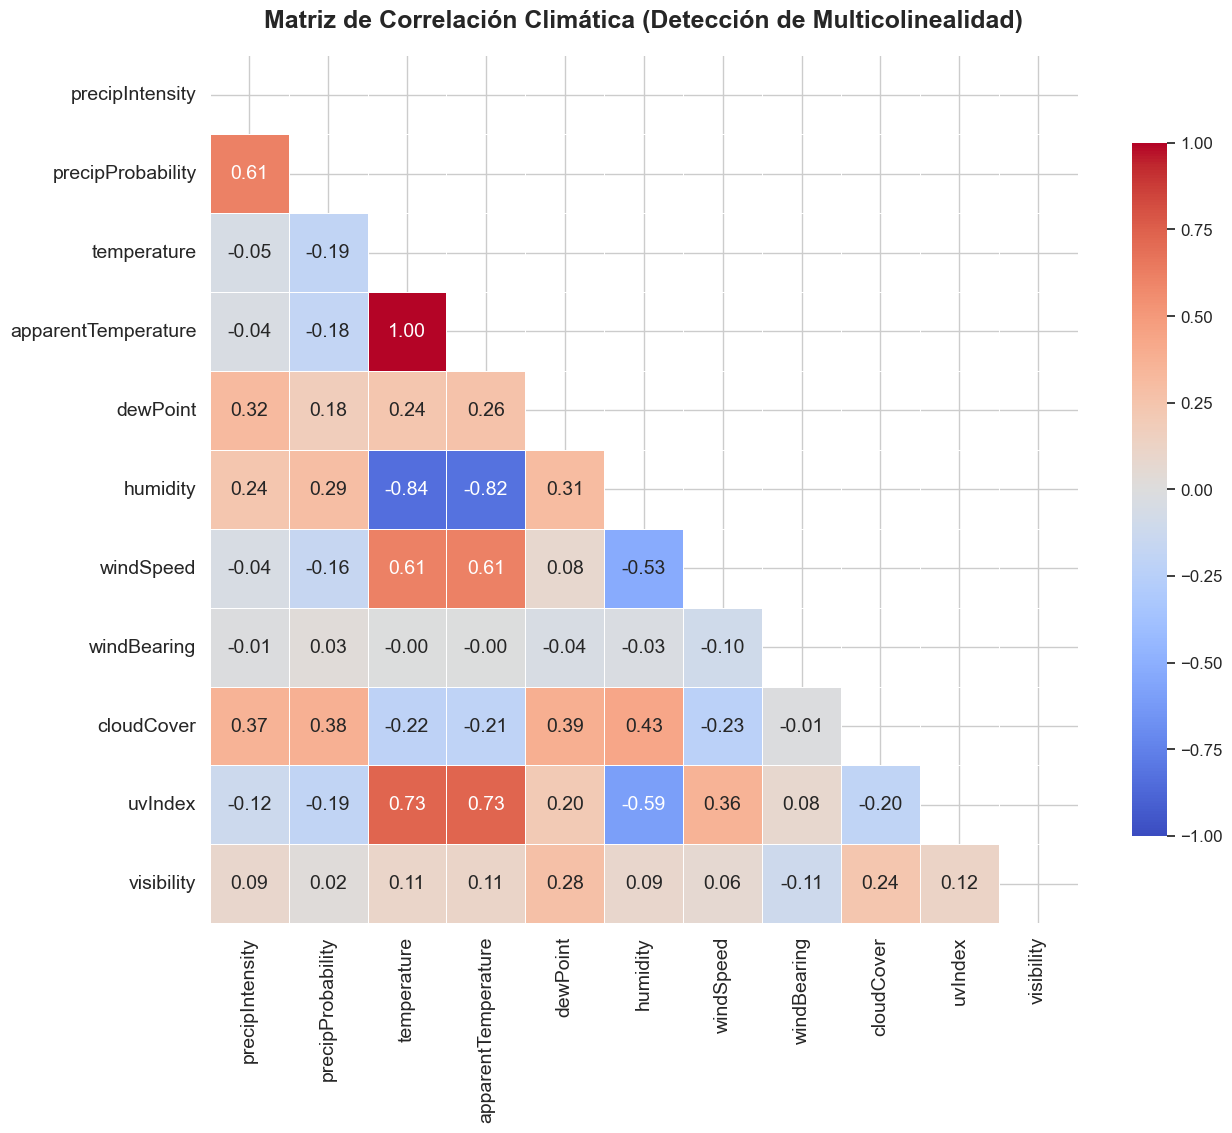

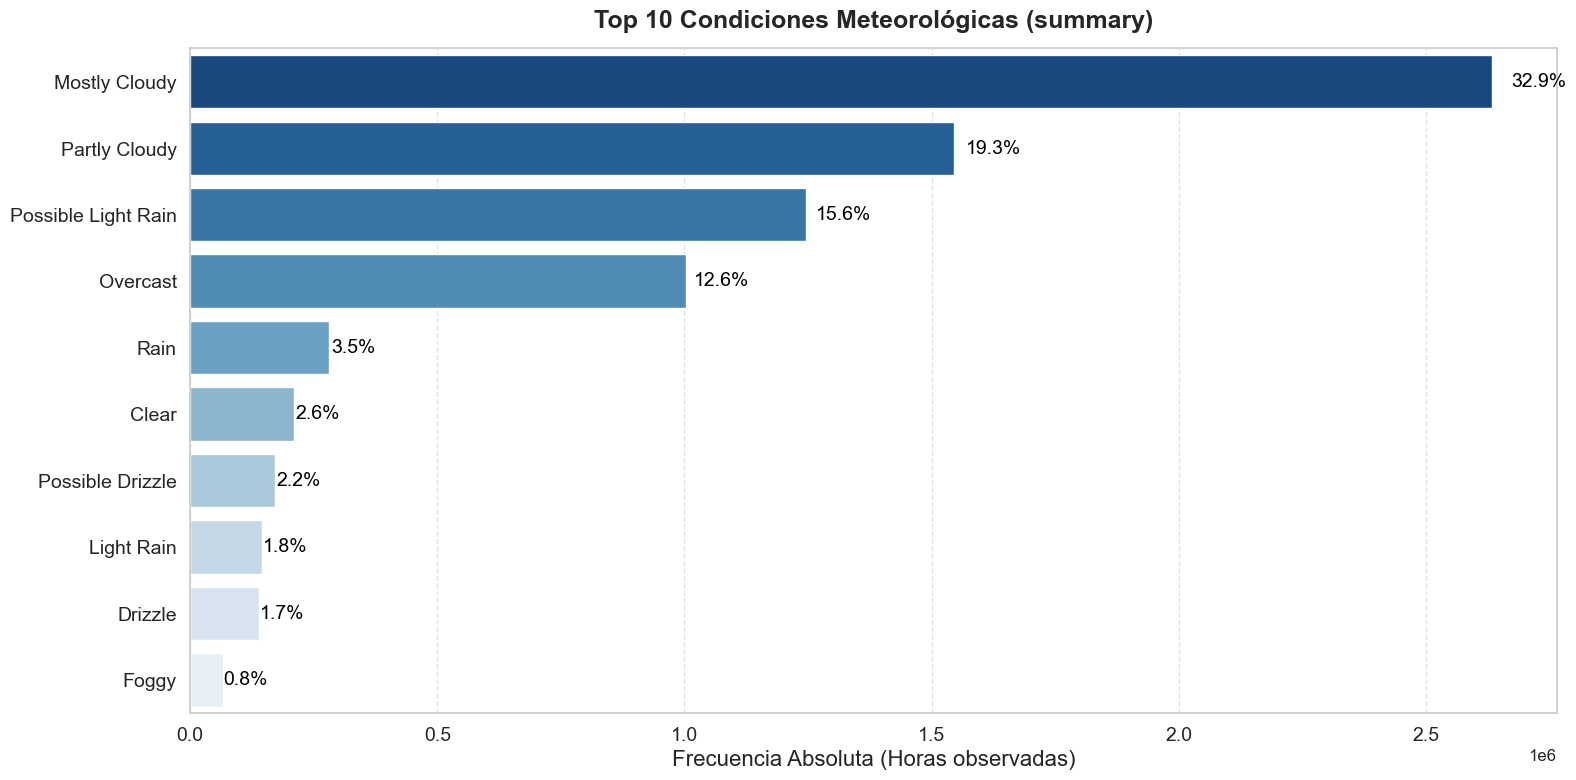

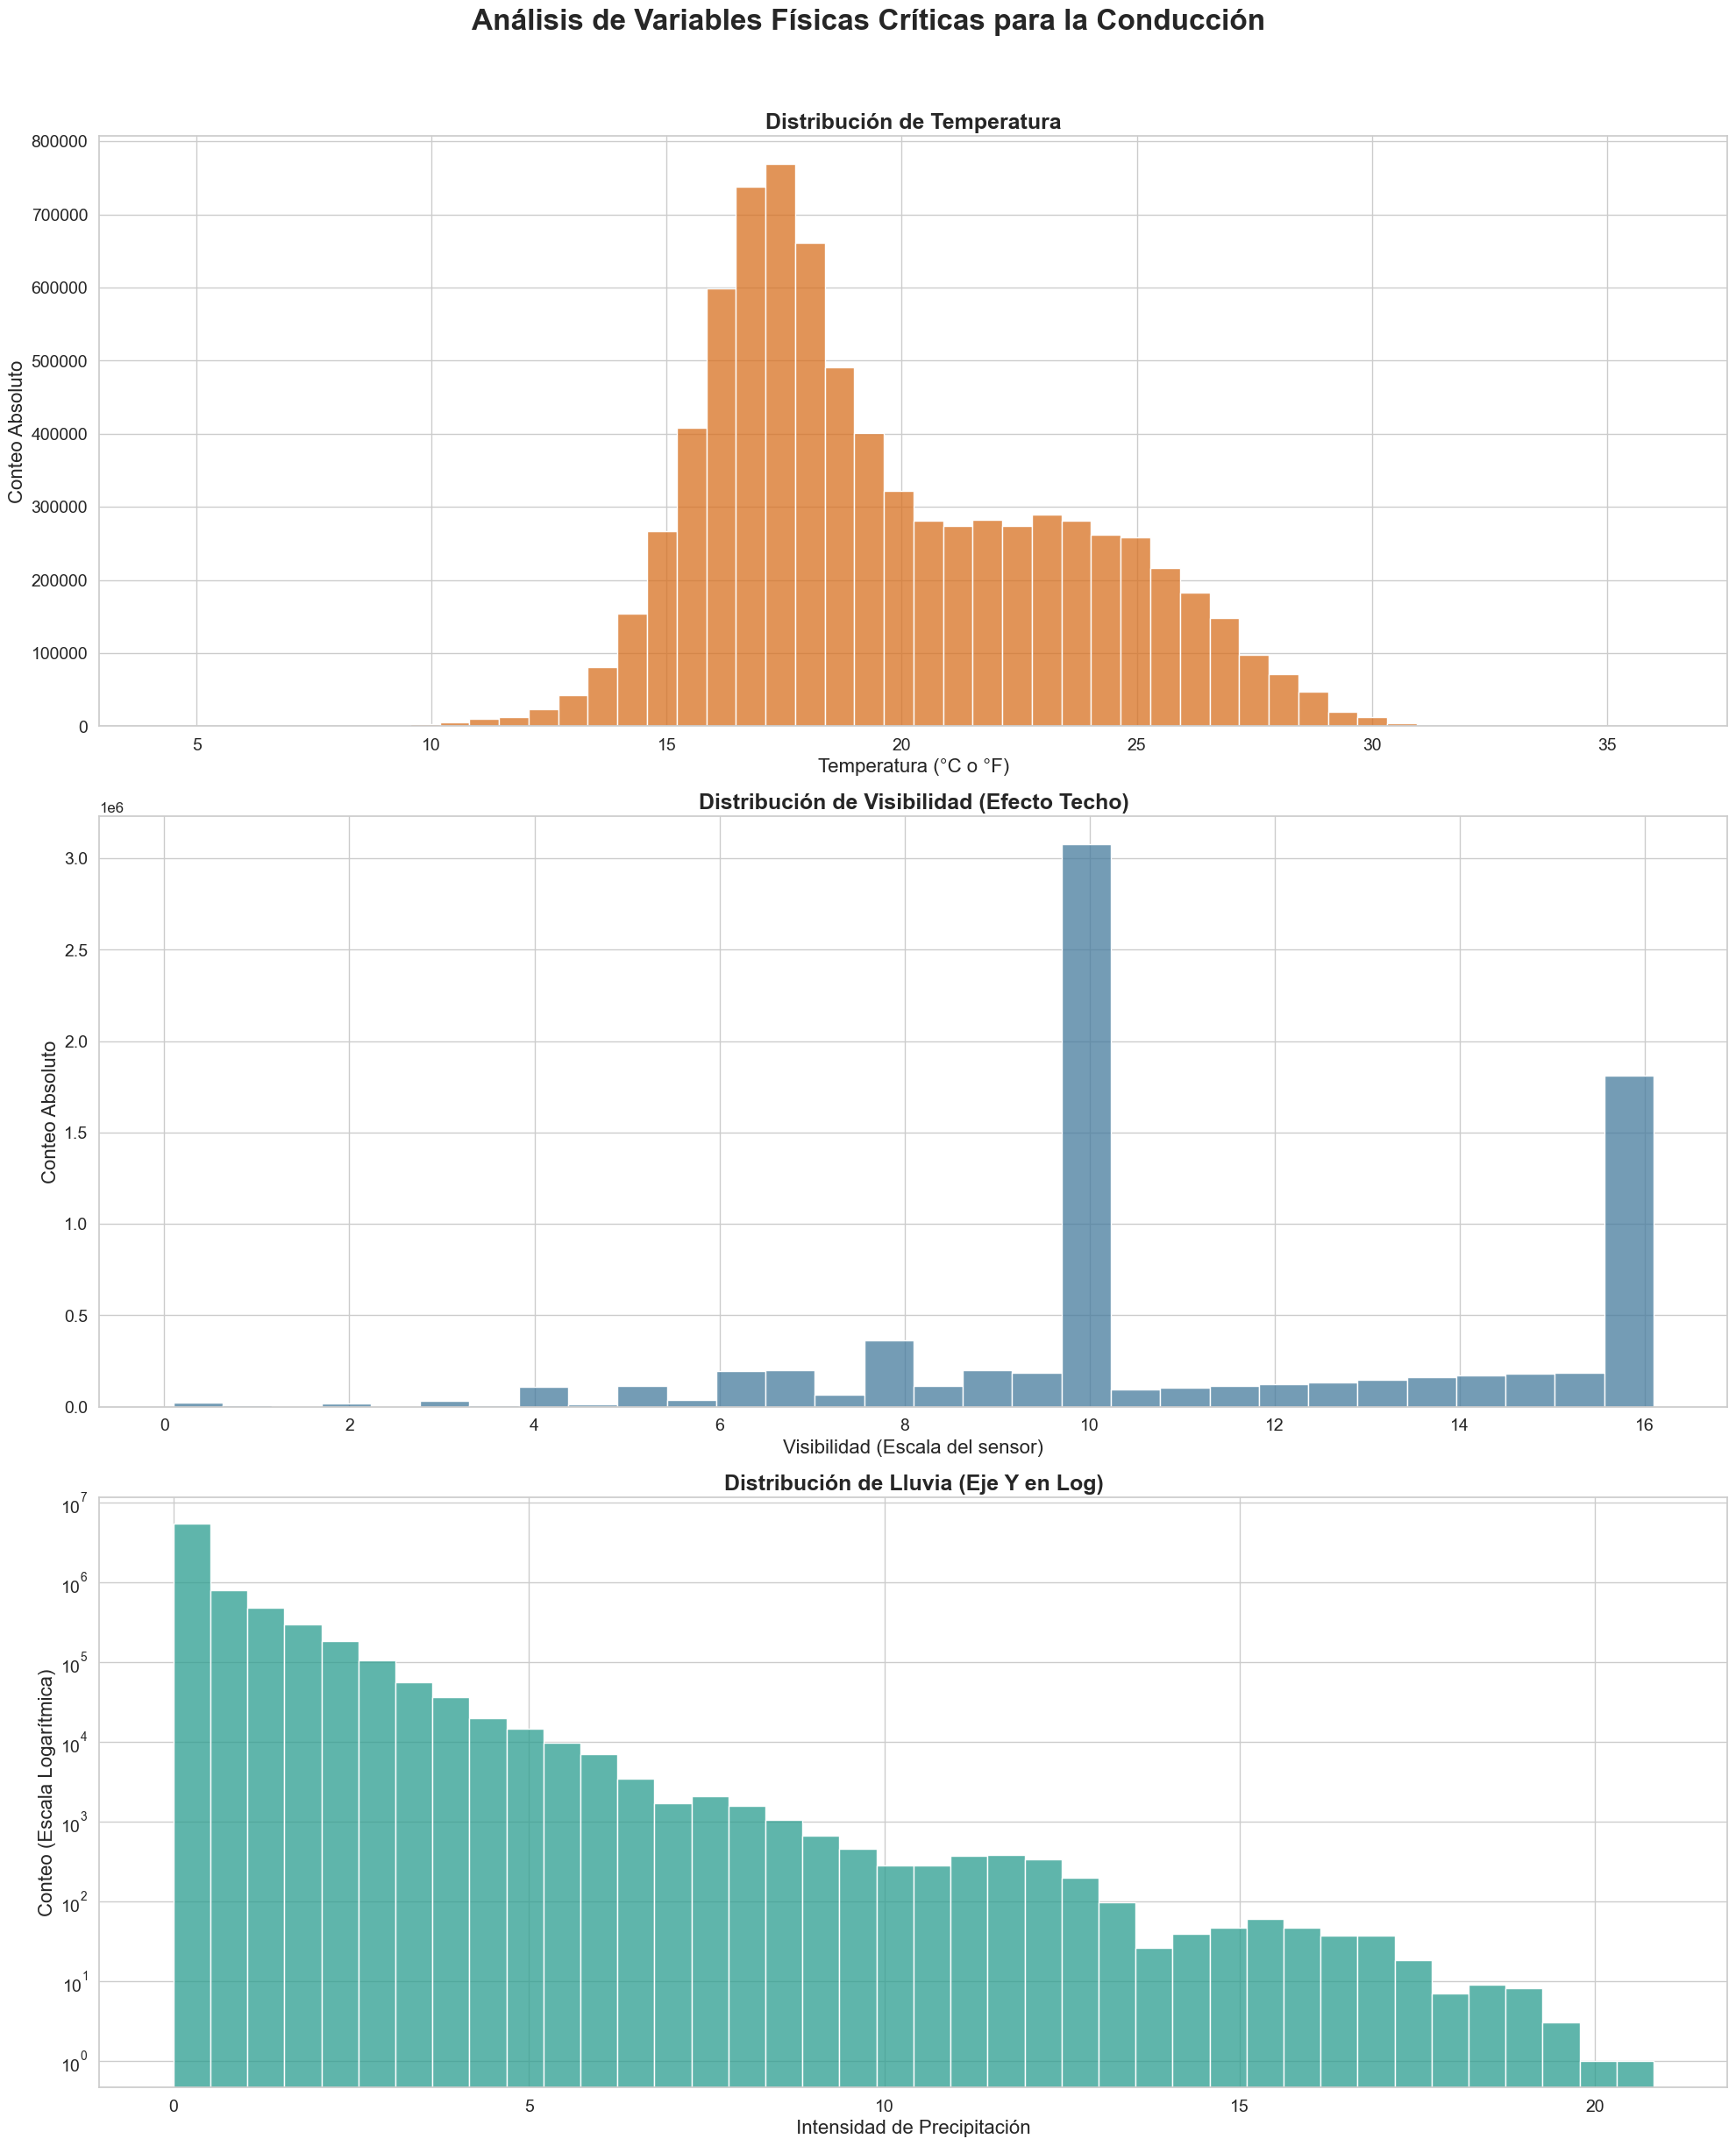

In [64]:
# =============================================================================
# EDA Extenso de Variables Climáticas (Diagnóstico de Features)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("AUDITORÍA DE CALIDAD Y COMPLETITUD CLIMÁTICA")
print("="*70)



# Selección de variables numéricas puras
cols_numericas = ['precipIntensity', 'precipProbability', 'temperature', 
                  'apparentTemperature', 'dewPoint', 'humidity', 'windSpeed', 
                  'windBearing', 'cloudCover', 'uvIndex', 'visibility']

# Validar cuáles existen realmente en el dataframe
cols_num_presentes = [col for col in cols_numericas if col in df_clima.columns]

# =============================================================================
# GRÁFICO 1: MATRIZ DE CORRELACIÓN (MULTICOLINEALIDAD)
# =============================================================================
fig_corr, ax_corr = plt.subplots(figsize=(14, 12))

# Calculamos correlación de Pearson
matriz_corr = df_clima[cols_num_presentes].corr()

# Máscara para el triángulo superior (para limpieza visual)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1, vmin=-1, 
    center=0,
    annot=True, 
    fmt='.2f', 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    annot_kws={"size": 14}, # Texto dentro de las celdas más grande
    ax=ax_corr
)

ax_corr.set_title('Matriz de Correlación Climática (Detección de Multicolinealidad)', fontweight='bold', fontsize=18, pad=20)
ax_corr.tick_params(axis='both', which='major', labelsize=14) # Tamaño de las etiquetas de los ejes
plt.savefig('clima_correlacion.png', bbox_inches='tight')

# =============================================================================
# GRÁFICO 2: TOP 10 CONDICIONES CLIMÁTICAS (CATEGÓRICAS)
# =============================================================================
if 'summary' in df_clima.columns:
    fig_cat, ax_cat = plt.subplots(figsize=(16, 8))
    
    # Extraer el top 10 de frecuencias
    top_summary = df_clima['summary'].value_counts().nlargest(10)
    
    sns.barplot(x=top_summary.values, y=top_summary.index.astype(str), palette='Blues_r', ax=ax_cat)
    ax_cat.set_title('Top 10 Condiciones Meteorológicas (summary)', fontweight='bold', fontsize=18, pad=15)
    ax_cat.set_xlabel('Frecuencia Absoluta (Horas observadas)', fontsize=16)
    ax_cat.set_ylabel('', fontsize=16)
    
    # Aumentar tamaño de las etiquetas de los ejes (nombres de los climas y números)
    ax_cat.tick_params(axis='both', which='major', labelsize=14)
    ax_cat.grid(axis='x', linestyle='--', alpha=0.6)
    
    # Inyectar porcentajes al final de las barras (texto más grande)
    total_obs = len(df_clima)
    for i, v in enumerate(top_summary.values):
        ax_cat.text(v + (v*0.015), i, f"{(v/total_obs)*100:.1f}%", color='black', va='center', fontsize=14)
        
    plt.tight_layout()
    plt.savefig('clima_condiciones_categoricas.png', bbox_inches='tight')

# =============================================================================
# GRÁFICO 3: DISTRIBUCIONES CRÍTICAS (VISIBILIDAD, TEMPERATURA Y LLUVIA)
# =============================================================================
fig_dist, axes_dist = plt.subplots(3, 1, figsize=(20, 24))

# A. Temperatura (Línea base ambiental)
if 'temperature' in df_clima.columns:
    sns.histplot(data=df_clima, x='temperature', bins=50, color='#d87020', ax=axes_dist[0])
    axes_dist[0].set_title('Distribución de Temperatura', fontweight='bold', fontsize=18)
    axes_dist[0].set_xlabel('Temperatura (°C o °F)', fontsize=16)
    axes_dist[0].set_ylabel('Conteo Absoluto', fontsize=16)
    axes_dist[0].tick_params(axis='both', which='major', labelsize=14)

# B. Visibilidad (Asimetría extrema)
if 'visibility' in df_clima.columns:
    sns.histplot(data=df_clima, x='visibility', bins=30, color='#457b9d', ax=axes_dist[1])
    axes_dist[1].set_title('Distribución de Visibilidad (Efecto Techo)', fontweight='bold', fontsize=18)
    axes_dist[1].set_xlabel('Visibilidad (Escala del sensor)', fontsize=16)
    axes_dist[1].set_ylabel('Conteo Absoluto', fontsize=16)
    axes_dist[1].tick_params(axis='both', which='major', labelsize=14)

# C. Intensidad de Lluvia (Efecto Cero-Inflado)
if 'precipIntensity' in df_clima.columns:
    # Usamos escala logarítmica en el eje Y porque los 0s aplastarán todo lo demás
    sns.histplot(data=df_clima, x='precipIntensity', bins=40, color='#2a9d8f', ax=axes_dist[2])
    axes_dist[2].set_yscale('log')
    axes_dist[2].set_title('Distribución de Lluvia (Eje Y en Log)', fontweight='bold', fontsize=18)
    axes_dist[2].set_xlabel('Intensidad de Precipitación', fontsize=16)
    axes_dist[2].set_ylabel('Conteo (Escala Logarítmica)', fontsize=16)
    axes_dist[2].tick_params(axis='both', which='major', labelsize=14)

# Título general más grande y con más espacio
fig_dist.suptitle('Análisis de Variables Físicas Críticas para la Conducción', y=1.02, fontsize=24, fontweight='bold')

plt.tight_layout()
plt.savefig('clima_distribuciones_criticas.png', bbox_inches='tight')

print("Visualizaciones climáticas generadas y guardadas correctamente.")
print("="*70)

In [65]:
# =============================================================================
# Auditoría Numérica Exacta de Multicolinealidad (df_clima)
# =============================================================================
import pandas as pd
import numpy as np

print("="*70)
print("AUDITORÍA NUMÉRICA DE PARES CORRELACIONADOS (ALERTA DE MULTICOLINEALIDAD)")
print("="*70)

# 1. Seleccionar exclusivamente las variables numéricas
cols_numericas = df_clima.select_dtypes(include=[np.number]).columns

# 2. Calcular la matriz de correlación de Pearson
matriz_corr = df_clima[cols_numericas].corr()

# 3. Desenrollar la matriz para convertirla en formato tabular (Fila a Fila)
pares_corr = matriz_corr.unstack().reset_index()
pares_corr.columns = ['Variable_1', 'Variable_2', 'Correlacion']

# 4. Limpieza matemática: 
# a) Eliminar las autocorrelaciones (donde Var_1 == Var_2, que siempre da 1.0)
# b) Eliminar los pares duplicados (la matriz es simétrica, A-B es lo mismo que B-A)
pares_unicos = pares_corr[pares_corr['Variable_1'] < pares_corr['Variable_2']].copy()

# 5. Calcular la magnitud absoluta para poder ordenar desde la relación más fuerte a la más débil
pares_unicos['Magnitud_Absoluta'] = pares_unicos['Correlacion'].abs()
pares_unicos = pares_unicos.sort_values(by='Magnitud_Absoluta', ascending=False)

# 6. Mostrar los resultados formateados
print("Top 15 pares de variables con mayor fuerza de relación lineal:")
display(pares_unicos[['Variable_1', 'Variable_2', 'Correlacion']].head(15).round(4))
print("-" * 70)

AUDITORÍA NUMÉRICA DE PARES CORRELACIONADOS (ALERTA DE MULTICOLINEALIDAD)
Top 15 pares de variables con mayor fuerza de relación lineal:


,Variable_1,Variable_2,Correlacion
35,apparentTemperature,temperature,0.9994
57,humidity,temperature,-0.8368
38,apparentTemperature,humidity,-0.8222
42,apparentTemperature,uvIndex,0.7304
31,temperature,uvIndex,0.7293
28,temperature,windSpeed,0.6138
39,apparentTemperature,windSpeed,0.6124
1,precipIntensity,precipProbability,0.6106
64,humidity,uvIndex,-0.5948
61,humidity,windSpeed,-0.5253


----------------------------------------------------------------------


Otras estadísticas descriptivas para las variables de clima:

In [66]:
import pandas as pd
import numpy as np

# Seleccionar únicamente las variables numéricas
cols_numericas = df_clima.select_dtypes(include=[np.number]).columns

# 1. Extraer las estadísticas descriptivas base y transponer para mejor lectura
estadisticas_clima = df_clima[cols_numericas].describe().T

# 2. Añadir métricas de forma de la distribución (Asimetría y Curtosis)
estadisticas_clima['skewness'] = df_clima[cols_numericas].skew()
estadisticas_clima['kurtosis'] = df_clima[cols_numericas].kurt()

# 3. Añadir diagnóstico de escasez (Porcentaje de Ceros y Nulos)
# Esto es vital para variables como precipitación o nubosidad
estadisticas_clima['%_ceros'] = (df_clima[cols_numericas] == 0).mean() * 100
estadisticas_clima['%_nulos'] = df_clima[cols_numericas].isnull().mean() * 100

# 4. Reordenar las columnas para una lectura lógica
columnas_ordenadas = [
    'count', '%_nulos', '%_ceros', 'mean', 'std', 'min', 
    '25%', '50%', '75%', 'max', 'skewness', 'kurtosis'
]
estadisticas_clima = estadisticas_clima[columnas_ordenadas]

print("="*80)
print("ESTADÍSTICAS DESCRIPTIVAS AVANZADAS DE VARIABLES CLIMÁTICAS")
print("="*80)
display(estadisticas_clima.round(3))

ESTADÍSTICAS DESCRIPTIVAS AVANZADAS DE VARIABLES CLIMÁTICAS


,count,%_nulos,%_ceros,mean,std,min,25%,50%,75%,max,skewness,kurtosis
precipIntensity,7444379.0,6.850,42.393,0.476,0.892,0.000,0.000,0.030,0.606,20.824,3.528,21.915001
precipProbability,7444379.0,6.850,42.393,0.160,0.220,0.000,0.000,0.060,0.260,1.000,1.818,3.480000
temperature,7991170.0,0.008,0.000,19.654,3.753,4.510,16.830,18.610,22.520,35.990,0.537,-0.536000
apparentTemperature,7991170.0,0.008,0.000,19.727,3.758,4.510,16.890,18.710,22.600,38.060,0.533,-0.541000
dewPoint,7991475.0,0.004,0.000,14.339,2.033,2.160,13.000,14.420,15.790,24.040,-0.179,0.064000
humidity,7990865.0,0.011,0.000,0.734,0.155,0.170,0.640,0.740,0.850,1.000,-0.452,-0.257000
windSpeed,7958987.0,0.410,10.180,1.583,1.258,0.000,0.810,1.360,2.090,15.260,1.519,3.898000
windBearing,6959267.0,12.920,1.817,111.329,81.047,0.000,62.000,90.000,135.000,359.000,1.248,1.223000
cloudCover,7983830.0,0.099,0.006,0.722,0.208,0.000,0.520,0.750,0.900,1.000,-0.614,-0.450000
uvIndex,7987500.0,0.054,57.808,2.005,2.870,0.000,0.000,0.000,4.000,14.000,1.146,-0.075000


**Hallazgos del EDA para las variables climáticas**:

1. **Multicolinealidad (Temperatura)**

La tabla muestra que temperature y apparentTemperature tienen distribuciones casi idénticas (medias de 19.65 vs 19.72, desviaciones de 3.75 vs 3.75). Esto confirma numéricamente lo que detectamos en la matriz de correlación de Pearson, donde arrojaron una colinealidad de 0.9994. Incluir ambas variables penalizará modelos como la Regresión Logística, inflando la varianza de los coeficientes. Los modelos de ensamble (Boosting/Random Forest) diluirán la importancia de la variable al dividirla entre las dos. Debemos eliminar una. Debido al riesgo de inflación de varianza en modelos lineales y la dilución de la importancia de características en arquitecturas de árboles, se determina excluir apparent Temperature durante la fase de Calidad de Datos.

2. **Distribuciones Cero-Infladas y Colas Extremas (Lluvia)**

precipIntensity tiene un 42.39% de ceros exactos y una curtosis extrema de 21.91. El valor máximo es 20.82, pero el percentil 75 es apenas 0.60. Esto valida matemáticamente el efecto "Cero-Inflado" que vimos en el histograma.  El clima en Medellín la mayor parte del tiempo no presenta lluvia, pero cuando llueve, puede ser torrencial (extremos en la cola derecha). Alimentar el modelo con esta variable cruda es subóptimo. Necesitamos derivar dos variables: Una categórica binaria (is_raining: 0 o 1). Una transformación logarítmica de la intensidad usando la fórmula $x' = \log(x + 1)$ para comprimir esos valores atípicos torrenciales y estabilizar la varianza.

3. **Fuga de Datos por Valores Nulos (windBearing)**

Mientras la mayoría de sensores tienen una tasa de fallo aceptable (menor al 1%), la variable de dirección del viento (windBearing) tiene casi un 13% de datos faltantes, seguida por las variables de lluvia con un ~6.8%. Si pasamos esto a un algoritmo de Scikit-Learn (a menos que usemos LightGBM/XGBoost que manejan nulos internamente), perderemos cientos de miles de filas al hacer un dropna(). Imputar por la media global sería un error metodológico grave al tratar series de tiempo climáticas. Debemos usar interpolación temporal (ej. ffill o "forward fill") para arrastrar la última medición válida del sensor en ese barrio.

4. **Ciclos Físicos Capturados (Visibilidad y Rayos UV)**

uvIndex tiene un 57.8% de ceros. Esto no es un error de los datos, es simplemente la noche física. Además, tiene una fuerte correlación con la temperatura (0.73) y negativa con la humedad (-0.59).  Variables como el UV o la visibilidad (que presenta un "efecto techo" estancándose en 16.09 ) son en gran medida proxies del ciclo día/noche.  Dado que el taller exige explícitamente codificar las variables temporales (hora, día) mediante ondas cíclicas con seno y coseno, el modelo ya sabrá cuándo es de noche. Podríamos evaluar si uvIndex realmente aporta varianza predictiva adicional o si es puro ruido redundante.

No obstante, antes de realizar cualquier transformación o join hagamos un análisis complementario adicional para terminar de comprender la calidad de los datos:

## **4. Calidad de datos**

In [67]:
import pandas as pd

def auditar_categoricas_y_strings(df_acc, df_clim):
    print("="*80)
    print(" AUDITORÍA DE STRINGS Y VARIABLES CATEGÓRICAS")
    print("="*80)
    
    # 1. ESTANDARIZACIÓN DEFENSIVA DE LA LLAVE ESPACIAL (BARRIO)
    # Evita que "belen" y "belen " no crucen. Convertimos a string, minúsculas y sin espacios.
    df_acc['BARRIO'] = df_acc['BARRIO'].astype(str).str.lower().str.strip()
    df_clim['BARRIO'] = df_clim['BARRIO'].astype(str).str.lower().str.strip()
    
    # Recalculamos la intersección real tras quitar el ruido de texto
    barrios_acc = set(df_acc['BARRIO'].unique())
    barrios_clim = set(df_clim['BARRIO'].unique())
    huerfanos_en_acc = barrios_acc - barrios_clim
    
    print("\n1. RE-EVALUACIÓN DE LLAVE 'BARRIO' TRAS ESTANDARIZACIÓN:")
    print(f" -> Barrios en Accidentes que NO están en Clima: {len(huerfanos_en_acc)}")
    if len(huerfanos_en_acc) > 0:
        print(f"    Fueron: {list(huerfanos_en_acc)[:10]}")
    else:
        print("    ¡Alineación perfecta lograda! Todos los barrios cruzan.")

    # 2. INSPECCIÓN DE VARIABLES CATEGÓRICAS
    print("\n2. VALORES ÚNICOS EN VARIABLES CATEGÓRICAS (Búsqueda de inconsistencias):")
    
    print("\n--- Categorías en df_accidentes ---")
    cat_acc = df_acc.select_dtypes(include=['object', 'category']).columns
    for col in cat_acc:
        if col != 'BARRIO': # Ya lo analizamos
            unicos = df_acc[col].dropna().unique()
            print(f" -> '{col}' ({len(unicos)} valores únicos):")
            print(f"    {list(unicos)[:20]}") # Imprime los primeros 20
            
    print("\n--- Categorías en df_clima ---")
    cat_clim = df_clim.select_dtypes(include=['object', 'category']).columns
    for col in cat_clim:
        if col != 'BARRIO':
            unicos = df_clim[col].dropna().unique()
            print(f" -> '{col}' ({len(unicos)} valores únicos):")
            print(f"    {list(unicos)[:20]}")
            
    print("="*80)

# Invocamos la función
auditar_categoricas_y_strings(df_accidentes, df_clima)

 AUDITORÍA DE STRINGS Y VARIABLES CATEGÓRICAS

1. RE-EVALUACIÓN DE LLAVE 'BARRIO' TRAS ESTANDARIZACIÓN:
 -> Barrios en Accidentes que NO están en Clima: 3
    Fueron: ['yarumalito', 'elastillero', 'suburbanoaguasfrias']

2. VALORES ÚNICOS EN VARIABLES CATEGÓRICAS (Búsqueda de inconsistencias):

--- Categorías en df_accidentes ---
 -> 'Dia_sem' (7 valores únicos):
    ['JUEVES', 'DOMINGO', 'MIERCOLES', 'SABADO', 'VIERNES', 'MARTES', 'LUNES']
 -> 'COMUNA' (26 valores únicos):
    ['La Candelaria', 'Laureles Estadio', 'Robledo', 'El Poblado', 'Doce de Octubre', 'La América', 'Manrique', 'Belén', 'Villa Hermosa', 'Aranjuez', 'Castilla', 'Buenos Aires', 'Guayabal', 'Corregimiento de Santa Elena', 'Corregimiento de San Antonio de Prado', 'Popular', 'San Javier', 'Santa Cruz', 'Corregimiento de San Cristóbal', 'Corregimiento de Altavista']
 -> 'Comuna-Barrio' (322 valores únicos):
    ['La Candelaria - sandiego', 'Laureles Estadio - lasacacias', 'Robledo - lopezdemesa', 'Laureles Estadio - lo

In [68]:
import pandas as pd
import numpy as np

def auditoria_maestra_calidad_v2(df_acc, df_clim, df_r):
    print("="*80)
    print(" 🚀 AUDITORÍA MAESTRA DE CALIDAD DE DATOS Y CONSISTENCIA CRUZADA (V2)")
    print("="*80)

    # ---------------------------------------------------------
    # 1. AUDITORÍA TEMPORAL Y HUECOS CIEGOS
    # ---------------------------------------------------------
    print("\n[1] ESTRUCTURA TEMPORAL Y HUECOS (Variable TW):")
    rango_min, rango_max = df_clim['TW'].min(), df_clim['TW'].max()
    malla_perfecta = pd.date_range(start=rango_min, end=rango_max, freq='h')
    horas_reales_clima = df_clim['TW'].unique()
    horas_faltantes_clima = malla_perfecta.difference(horas_reales_clima)
    
    print(f" -> Alineación temporal: Ambas van desde {rango_min} hasta {rango_max}")
    print(f" -> Continuidad climática: Esperadas {len(malla_perfecta):,} hrs | Reales {len(horas_reales_clima):,} hrs")
    
    if len(horas_faltantes_clima) > 0:
        print(f" ❌ Faltan {len(horas_faltantes_clima)} horas en la tabla de CLIMA.")
        # Buscar cuántos accidentes ocurrieron justo en esas horas donde el sensor climático no reportó
        accidentes_en_huecos = df_acc[df_acc['TW'].isin(horas_faltantes_clima)]
        print(f" ⚠️ IMPACTO: En esas horas ciegas ocurrieron {len(accidentes_en_huecos)} accidentes.")
        if len(accidentes_en_huecos) > 0:
            print("    -> Evaluar si eliminar estos accidentes. Es mejor imputar el clima?")
    else:
        print(" ✅ Malla temporal de clima completa.")

    # ---------------------------------------------------------
    # 2. ESTANDARIZACIÓN Y AUDITORÍA ESPACIAL (BARRIO)
    # ---------------------------------------------------------
    print("\n[2] CONSISTENCIA ESPACIAL (Limpieza y Cruce de BARRIOS):")
    df_acc['BARRIO'] = df_acc['BARRIO'].astype(str).str.lower().str.strip()
    df_clim['BARRIO'] = df_clim['BARRIO'].astype(str).str.lower().str.strip()
    if 'BARRIO' in df_r.columns:
        df_r['BARRIO'] = df_r['BARRIO'].astype(str).str.lower().str.strip()

    barrios_acc = set(df_acc['BARRIO'].dropna().unique())
    barrios_clim = set(df_clim['BARRIO'].dropna().unique())
    huerfanos_en_acc = list(barrios_acc - barrios_clim)

    print(f" -> Barrios huérfanos (en accidentes sin clima): {len(huerfanos_en_acc)}")
    if len(huerfanos_en_acc) > 0:
        print(f"    Nombres: {huerfanos_en_acc}")

    # ---------------------------------------------------------
    # 3. AUDITORÍA ESTRUCTURAL (Duplicados y Nulos)
    # ---------------------------------------------------------
    print("\n[3] INTEGRIDAD ESTRUCTURAL:")
    dup_acc = df_acc.duplicated(subset=['TW', 'BARRIO']).sum()
    dup_clim = df_clim.duplicated(subset=['TW', 'BARRIO']).sum()
    print(f" -> Duplicados estructurales (TW+BARRIO): Accidentes ({dup_acc:,}) | Clima ({dup_clim:,})")
    
    print("\n -> TOP VARIABLES CON NULOS (%):")
    nulos_acc = (df_acc.isnull().mean() * 100).sort_values(ascending=False)
    nulos_clim = (df_clim.isnull().mean() * 100).sort_values(ascending=False)
    df_nulos = pd.DataFrame({
        'Accidentes (%)': nulos_acc[nulos_acc > 0].round(2),
        'Clima (%)': nulos_clim[nulos_clim > 0].round(2)
    })
    display(df_nulos.fillna('-').head(20))

    # ---------------------------------------------------------
    # 4. AUDITORÍA SEMÁNTICA (Valores Categóricos Completos)
    # ---------------------------------------------------------
    print("\n[4] INSPECCIÓN DE VARIABLES CATEGÓRICAS Y STRINGS (SIN RECORTES):")
    
    def imprimir_categorias_completas(df, nombre_df):
        cols_cat = df.select_dtypes(include=['object', 'category']).columns
        # Excluir BARRIO para no imprimir 319 nombres y saturar la pantalla
        cols_cat = [c for c in cols_cat if c.upper() != 'BARRIO'] 
        
        for col in cols_cat:
            unicos = df[col].dropna().unique()
            print(f"\n -> [{nombre_df}] Columna '{col}' ({len(unicos)} valores únicos):")
            print(f"    {list(unicos)}")

    imprimir_categorias_completas(df_acc, "Accidentes")
    imprimir_categorias_completas(df_clim, "Clima")
    
    # Evaluar la COMUNA explícitamente en df_raw si existe
    col_comuna = next((col for col in df_r.columns if col.upper() == 'COMUNA'), None)
    if col_comuna:
        unicos_comuna = df_r[col_comuna].dropna().unique()
        print(f"\n -> [Raw Accidentes] Columna '{col_comuna}' ({len(unicos_comuna)} valores únicos):")
        print(f"    {list(unicos_comuna)}")

    print("\n" + "="*80)

# Ejecutar el super-pipeline
auditoria_maestra_calidad_v2(df_accidentes, df_clima, df_raw)

 🚀 AUDITORÍA MAESTRA DE CALIDAD DE DATOS Y CONSISTENCIA CRUZADA (V2)

[1] ESTRUCTURA TEMPORAL Y HUECOS (Variable TW):
 -> Alineación temporal: Ambas van desde 2017-01-01 00:00:00 hasta 2019-12-31 23:00:00
 -> Continuidad climática: Esperadas 26,280 hrs | Reales 26,260 hrs
 ❌ Faltan 20 horas en la tabla de CLIMA.
 ⚠️ IMPACTO: En esas horas ciegas ocurrieron 106 accidentes.
    -> Evaluar si eliminar estos accidentes. Es mejor imputar el clima?

[2] CONSISTENCIA ESPACIAL (Limpieza y Cruce de BARRIOS):
 -> Barrios huérfanos (en accidentes sin clima): 3
    Nombres: ['yarumalito', 'elastillero', 'suburbanoaguasfrias']

[3] INTEGRIDAD ESTRUCTURAL:
 -> Duplicados estructurales (TW+BARRIO): Accidentes (0) | Clima (0)

 -> TOP VARIABLES CON NULOS (%):


,Accidentes (%),Clima (%)
apparentTemperature,-,0.01
cloudCover,-,0.10
dewPoint,-,0.00
humidity,-,0.01
icon,-,6.87
precipIntensity,-,6.85
precipProbability,-,6.85
summary,-,6.87
temperature,-,0.01
uvIndex,-,0.05



[4] INSPECCIÓN DE VARIABLES CATEGÓRICAS Y STRINGS (SIN RECORTES):

 -> [Accidentes] Columna 'Dia_sem' (7 valores únicos):
    ['JUEVES', 'DOMINGO', 'MIERCOLES', 'SABADO', 'VIERNES', 'MARTES', 'LUNES']

 -> [Accidentes] Columna 'COMUNA' (26 valores únicos):
    ['La Candelaria', 'Laureles Estadio', 'Robledo', 'El Poblado', 'Doce de Octubre', 'La América', 'Manrique', 'Belén', 'Villa Hermosa', 'Aranjuez', 'Castilla', 'Buenos Aires', 'Guayabal', 'Corregimiento de Santa Elena', 'Corregimiento de San Antonio de Prado', 'Popular', 'San Javier', 'Santa Cruz', 'Corregimiento de San Cristóbal', 'Corregimiento de Altavista', 'Corregimiento de San Sebastián de Palmitas', 'Antonio Nariño', 'Bolivariana', 'Santa Inés', 'Cabecera San Antonio de Prado', 'Las Palmas']

 -> [Accidentes] Columna 'Comuna-Barrio' (322 valores únicos):
    ['La Candelaria - sandiego', 'Laureles Estadio - lasacacias', 'Robledo - lopezdemesa', 'Laureles Estadio - losconquistadores', 'Laureles Estadio - cuartabrigada', 'El P

In [69]:
import pandas as pd

def evaluar_impacto_barrios(df_r, barrios_huerfanos):
    print("="*80)
    print(" EVALUACIÓN DE IMPACTO: PÉRDIDA DE INFORMACIÓN POR BARRIOS HUÉRFANOS")
    print("="*80)
    
    # 1. IMPACTO A NIVEL GLOBAL
    total_global = len(df_r)
    df_huerfanos = df_r[df_r['BARRIO'].isin(barrios_huerfanos)]
    total_huerfanos = len(df_huerfanos)
    pct_global = (total_huerfanos / total_global) * 100
    
    print("\n1. IMPACTO GLOBAL:")
    print(f" -> Total de incidentes en la base cruda: {total_global:,}")
    print(f" -> Incidentes en los 3 barrios huérfanos: {total_huerfanos:,}")
    print(f" -> Representación global:                 {pct_global:.4f}%")
    
    # 2. IMPACTO A NIVEL DE COMUNA
    # Verificamos si la columna COMUNA existe (a veces puede estar en mayúscula o minúscula)
    col_comuna = next((col for col in df_r.columns if col.upper() == 'COMUNA'), None)
    
    if col_comuna:
        print("\n2. IMPACTO FOCALIZADO (A NIVEL DE COMUNA):")
        comunas_afectadas = df_huerfanos[col_comuna].dropna().unique()
        
        for comuna in comunas_afectadas:
            # Total de accidentes en esta comuna específica
            total_comuna = len(df_r[df_r[col_comuna] == comuna])
            
            # Total de accidentes de los barrios huérfanos pertenecientes a esta comuna
            df_huerf_comuna = df_huerfanos[df_huerfanos[col_comuna] == comuna]
            total_huerf_comuna = len(df_huerf_comuna)
            
            pct_comuna = (total_huerf_comuna / total_comuna) * 100 if total_comuna > 0 else 0
            
            barrios_en_comuna = df_huerf_comuna['BARRIO'].unique().tolist()
            
            print(f" -> Comuna afectada: '{comuna}'")
            print(f"    - Barrios a eliminar:          {barrios_en_comuna}")
            print(f"    - Incidentes en la comuna:     {total_comuna:,}")
            print(f"    - Incidentes a sacrificar:     {total_huerf_comuna:,}")
            print(f"    - Pérdida de info en comuna:   {pct_comuna:.2f}%\n")
    else:
        print("\n[!] La columna 'COMUNA' no está disponible en df_raw para el análisis focalizado.")
        print("    Distribución individual por barrio:")
        display(df_huerfanos['BARRIO'].value_counts().to_frame('Accidentes Perdidos'))
        
    print("="*80)

# Lista detectada en el paso de auditoría anterior
barrios_sin_clima = ['suburbanoaguasfrias', 'yarumalito', 'elastillero']

# Ejecutamos pasando la tabla cruda
evaluar_impacto_barrios(df_raw, barrios_sin_clima)

 EVALUACIÓN DE IMPACTO: PÉRDIDA DE INFORMACIÓN POR BARRIOS HUÉRFANOS

1. IMPACTO GLOBAL:
 -> Total de incidentes en la base cruda: 125,122
 -> Incidentes en los 3 barrios huérfanos: 4
 -> Representación global:                 0.0032%

2. IMPACTO FOCALIZADO (A NIVEL DE COMUNA):
 -> Comuna afectada: 'Corregimiento de San Antonio de Prado'
    - Barrios a eliminar:          ['elastillero', 'yarumalito']
    - Incidentes en la comuna:     1,901
    - Incidentes a sacrificar:     3
    - Pérdida de info en comuna:   0.16%

 -> Comuna afectada: 'Corregimiento de Altavista'
    - Barrios a eliminar:          ['suburbanoaguasfrias']
    - Incidentes en la comuna:     180
    - Incidentes a sacrificar:     1
    - Pérdida de info en comuna:   0.56%



**Observamos:**

1. **Hay 3 Barrios Huérfanos (suburbanoaguasfrias, yarumalito, elastillero)**

Tenemos accidentes en estos barrios, pero no tenemos malla climática para ellos en df_clima. Si cruzamos a la fuerza, los accidentes de estos barrios quedarán con valores NaN en todas las variables de clima, obligándonos a imputar a ciegas o a perder la información más adelante. El análisis demostró que estos 3 barrios representan apenas 4 incidentes frente a un universo de 125,122 (una pérdida global del 0.0032%). A nivel focalizado, la pérdida máxima se da en el Corregimiento de Altavista y representa solo el 0.56% de su casuística. Dado que la pérdida de señal es marginal (Regla de Drop Seguro < 2%), se prioriza la consistencia matricial sobre la costosa (y ruidosa) imputación espacial. Decisión: Eliminar los registros de accidentes pertenecientes a los 3 barrios huérfanos.

2. **Hay 20 horas faltantes (106 accidentes)**

Si hubiéramos cruzado a ciegas, habríamos perdido 106 accidentes reales (falsos negativos autoinducidos). En problemas de desbalance de clases, perder eventos de la clase minoritaria es grave. Decisión: Vamos a forzar la malla temporal perfecta de 26,280 horas, unir el clima real, y hacer una imputación forward-fill agrupada por barrio. Así, esos 106 accidentes heredarán el clima de la hora anterior registrada por el sensor.

3. **Variables Categóricas (summary vs icon)**

Tenemos a summary con 20 categorías ruidosas y superpuestas ("Possible Light Rain", "Light Rain", "Drizzle"), y a icon con 8 categorías limpias y consolidadas que, además, capturan implícitamente el ciclo día/noche ("partly-cloudy-night" vs "partly-cloudy-day"). Decisión: Mantener icon y eliminar summary. Introducir ambas al modelo generaría multicolinealidad categórica. icon ya es una variable curada con dimensionalidad perfecta para hacer One-Hot Encoding.

### **Limpieza**

In [70]:
import pandas as pd
from itertools import product

def pipeline_maestro_limpieza(df_acc, df_clim):
    print("="*80)
    print(" INICIANDO PIPELINE DE LIMPIEZA ESTRUCTURAL Y ESPACIO-TEMPORAL (V3 - PROTEGIDO)")
    print("="*80)
    
    df_acc_clean = df_acc.copy()
    df_clim_clean = df_clim.copy()
    
    # 1. ESTANDARIZACIÓN DE LLAVES ESPACIALES
    df_acc_clean['BARRIO'] = df_acc_clean['BARRIO'].astype(str).str.lower().str.strip()
    df_clim_clean['BARRIO'] = df_clim_clean['BARRIO'].astype(str).str.lower().str.strip()
    
    # 2. PURGA ESPACIAL
    barrios_clima = df_clim_clean['BARRIO'].unique()
    filas_antes = len(df_acc_clean)
    df_acc_clean = df_acc_clean[df_acc_clean['BARRIO'].isin(barrios_clima)]
    print(f" -> Purgado espacial: Se eliminaron {filas_antes - len(df_acc_clean)} accidentes de barrios sin clima.")
    
    # 3. CONSTRUCCIÓN DE LA MALLA TEMPORAL PERFECTA
    rango_perfecto = pd.date_range(start=df_clim_clean['TW'].min(), end=df_clim_clean['TW'].max(), freq='h')
    malla_base = pd.DataFrame(list(product(rango_perfecto, barrios_clima)), columns=['TW', 'BARRIO'])
    print(f" -> Malla maestra creada con {len(malla_base):,} combinaciones (Horas x Barrios).")
    
    # 4. FUSIÓN Y CURACIÓN DE NULOS EN CLIMA (Evitando Data Leakage y Error de Tipos)
    df_clim_completo = pd.merge(malla_base, df_clim_clean, on=['TW', 'BARRIO'], how='left')
    
    # Ordenar cronológicamente DENTRO de cada barrio para ffill
    df_clim_completo = df_clim_completo.sort_values(by=['BARRIO', 'TW']).reset_index(drop=True)
    columnas_a_imputar = df_clim_completo.columns.drop(['TW', 'BARRIO'])
    
    # Imputación hacia adelante (ffill)
    df_clim_completo[columnas_a_imputar] = df_clim_completo.groupby('BARRIO')[columnas_a_imputar].ffill()
    
    # --- SOLUCIÓN AL TYPE ERROR: Separar numéricas de categóricas ---
    cols_num = df_clim_clean[columnas_a_imputar].select_dtypes(include=['number']).columns
    cols_cat = df_clim_clean[columnas_a_imputar].select_dtypes(exclude=['number']).columns
    
    # Respaldo estático para numéricas (Mediana)
    if len(cols_num) > 0:
        medianas = df_clim_clean[cols_num].median()
        df_clim_completo[cols_num] = df_clim_completo[cols_num].fillna(medianas)
        
    # Respaldo estático para categóricas (Moda / Valor más frecuente)
    if len(cols_cat) > 0:
        modas = df_clim_clean[cols_cat].mode().iloc[0]
        df_clim_completo[cols_cat] = df_clim_completo[cols_cat].fillna(modas)
    
    print(" -> Imputación temporal (ffill + fallback tipado) completada de manera no sesgada.")
    
    # 5. PODA DE VARIABLES REDUNDANTES
    cols_a_eliminar = ['apparentTemperature', 'summary']
    cols_presentes = [c for c in cols_a_eliminar if c in df_clim_completo.columns]
    df_clim_completo = df_clim_completo.drop(columns=cols_presentes)
    print(f" -> Reducción de dimensionalidad: Se eliminaron las variables {cols_presentes}.")
    
    # 6. VERIFICACIÓN FINAL
    print(f"\n -> Nulos restantes en la matriz de clima resultante: {df_clim_completo.isnull().sum().sum()}")
    print("="*80)
    
    return df_acc_clean, df_clim_completo

# Ejecución formal
df_accidentes, df_clima = pipeline_maestro_limpieza(df_accidentes, df_clima)

 INICIANDO PIPELINE DE LIMPIEZA ESTRUCTURAL Y ESPACIO-TEMPORAL (V3 - PROTEGIDO)
 -> Purgado espacial: Se eliminaron 4 accidentes de barrios sin clima.
 -> Malla maestra creada con 8,383,320 combinaciones (Horas x Barrios).
 -> Imputación temporal (ffill + fallback tipado) completada de manera no sesgada.
 -> Reducción de dimensionalidad: Se eliminaron las variables ['apparentTemperature', 'summary'].

 -> Nulos restantes en la matriz de clima resultante: 0


 **Consideraciones Metodológicas: Prevención de Data Leakage Temporal** 
 
 En problemas de predicción basados en series de tiempo y variables meteorológicas, la dirección del flujo de información es crítica. Usar una función de respaldo tipo .bfill() (Backward Fill) introduciría una fuga de datos (Data Leakage) masiva: permitía que valores climáticos del futuro (por ejemplo, la intensidad de lluvia de la 1:00 AM) se propagaran hacia el pasado (las 12:00 AM) para cubrir registros faltantes del sensor.  Al entrenar un modelo con esta distorsión, el algoritmo aprendería a correlacionar un accidente en la hora $t$ utilizando datos climáticos de la hora $t+1$, una condición imposible de replicar en un entorno de producción real.  **Protocolo aplicado**: Los huecos ciegos del sensor meteorológico se resuelven estrictamente mediante .ffill() (Forward Fill), asegurando que el modelo solo herede condiciones del pasado inmediato. Para las filas iniciales donde no existe pasado, se configuró un reemplazo estático con la mediana histórica global de la variable (moda para las categoricas), blindando la integridad temporal del experimento.

## 5. **Unión de tablas e ingeniería de características**

### **5.1. JOIN, TARGET Y EXTRACCIÓN TEMPORAL**

In [93]:
# =============================================================================
# 5.1. JOIN, TARGET Y EXTRACCIÓN TEMPORAL
# =============================================================================
import pandas as pd
import numpy as np
import holidays

def ejecutar_join_y_tiempo(df_clim_completo, df_acc_clean):
    print("=" * 80)
    print(" 5.1  JOIN, TARGET Y EXTRACCIÓN TEMPORAL")
    print("=" * 80)

    # ------------------------------------------------------------------
    # BLOQUE 1: LEFT JOIN — la malla climática es la tabla base
    # Se usa LEFT JOIN porque df_clima cubre TODAS las combinaciones
    # (barrio, hora), tanto con accidente como sin él. Los accidentes
    # se acoplan encima: si no hay match → target = 0 (caso negativo).
    # ------------------------------------------------------------------
    df_acc_unicos = df_acc_clean[['TW', 'BARRIO']].drop_duplicates()
    df_acc_unicos = df_acc_unicos.copy()
    df_acc_unicos['indicador_accidente'] = 1

    print(" -> Ejecutando LEFT JOIN (malla climática como base)...")
    df_master = pd.merge(
        df_clim_completo, df_acc_unicos,
        on=['TW', 'BARRIO'], how='left'
    )

    # Variable objetivo binaria
    df_master['target'] = (
        df_master['indicador_accidente'].fillna(0).astype('int8')
    )
    df_master = df_master.drop(columns=['indicador_accidente'])

    print("\n RADIOGRAFÍA DEL DESBALANCE DE CLASES")
    desbalance = df_master['target'].value_counts(normalize=True) * 100
    print(f" -> Clase negativa (0 - sin accidente) : {desbalance[0]:.3f}%")
    print(f" -> Clase positiva (1 - con accidente) : {desbalance[1]:.3f}%")

    # ------------------------------------------------------------------
    # BLOQUE 2: EXTRACCIÓN TEMPORAL
    # Todas las variables se tipan a int8 para conservar RAM.
    # es_festivo usa el calendario oficial de Colombia (librería holidays).
    # ------------------------------------------------------------------
    print("\n -> Extrayendo componentes temporales...")

    df_master['hora']        = df_master['TW'].dt.hour.astype('int8')
    df_master['dia_semana']  = df_master['TW'].dt.dayofweek.astype('int8')
    df_master['mes']         = df_master['TW'].dt.month.astype('int8')
    df_master['es_fin_semana'] = (
        df_master['dia_semana'].isin([5, 6]).astype('int8')
    )

    print(" -> Inyectando festivos de Colombia (2017-2019)...")
    co_holidays = holidays.Colombia(years=[2017, 2018, 2019])
    df_master['es_festivo'] = (
        df_master['TW'].dt.date.apply(lambda x: x in co_holidays).astype('int8')
    )

    print(f"\n -> Dimensiones del DF maestro: {df_master.shape}")
    print("=" * 80)
    return df_master


df_maestro = ejecutar_join_y_tiempo(df_clima, df_accidentes)

 5.1  JOIN, TARGET Y EXTRACCIÓN TEMPORAL
 -> Ejecutando LEFT JOIN (malla climática como base)...

 RADIOGRAFÍA DEL DESBALANCE DE CLASES
 -> Clase negativa (0 - sin accidente) : 98.562%
 -> Clase positiva (1 - con accidente) : 1.438%

 -> Extrayendo componentes temporales...
 -> Inyectando festivos de Colombia (2017-2019)...

 -> Dimensiones del DF maestro: (8383320, 19)


In [94]:
display(df_maestro)

,TW,BARRIO,icon,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility,target,hora,dia_semana,mes,es_fin_semana,es_festivo
0,2017-01-01 00:00:00,aguasfrias,partly-cloudy-night,0.0000,0.00,16.43,14.00,0.86,1.50,0.0,0.44,0.0,6.004,0,0,6,1,1,1
1,2017-01-01 01:00:00,aguasfrias,partly-cloudy-night,0.0000,0.00,16.43,14.00,0.86,1.50,0.0,0.44,0.0,6.004,0,1,6,1,1,1
2,2017-01-01 02:00:00,aguasfrias,fog,0.0000,0.00,15.43,13.00,0.85,1.02,0.0,0.44,0.0,2.997,0,2,6,1,1,1
3,2017-01-01 03:00:00,aguasfrias,fog,0.0000,0.00,15.43,13.00,0.85,2.09,140.0,0.44,0.0,0.199,0,3,6,1,1,1
4,2017-01-01 04:00:00,aguasfrias,fog,0.0000,0.00,15.43,13.00,0.85,2.09,350.0,1.00,0.0,0.099,0,4,6,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8383315,2019-12-31 19:00:00,yolombo,rain,3.0905,0.38,15.33,15.33,1.00,1.20,348.0,0.99,0.0,10.165,0,19,1,12,0,0
8383316,2019-12-31 20:00:00,yolombo,rain,2.8501,0.38,15.00,15.00,1.00,1.36,225.0,0.99,0.0,10.737,0,20,1,12,0,0
8383317,2019-12-31 21:00:00,yolombo,rain,2.0769,0.40,14.68,14.68,1.00,1.12,152.0,0.99,0.0,14.227,0,21,1,12,0,0
8383318,2019-12-31 22:00:00,yolombo,rain,1.7971,0.41,14.34,14.34,1.00,0.66,169.0,0.98,0.0,16.093,0,22,1,12,0,0


**Inspección express de calidad**:

In [95]:
def auditar_maestro_checkpoint(df):
    print("="*80)
    print(" 🛡️ AUDITORÍA DE CALIDAD Y MEMORIA: DF_MAESTRO (POST-JOIN)")
    print("="*80)
    
    # 1. Consumo de Memoria RAM
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f" -> 💾 Memoria RAM Total consumida: {mem_mb:.2f} MB")
    
    # 2. Validación de Filas (Sanity Check del Join)
    print(f" -> 📊 Total de registros (Combinaciones Hora x Barrio): {len(df):,}")
    
    # 3. Verificación de Tipos (Confirmar que int8 sobrevivió)
    cols_int8 = df.select_dtypes(include=['int8']).columns.tolist()
    print(f" -> 🏷️ Columnas optimizadas a int8 ({len(cols_int8)}): {cols_int8}")
    
    # 4. Escaneo de Fugas y Nulos
    nulos = df.isnull().sum()
    nulos_totales = nulos.sum()
    print("\n -> 🕵️‍♂️ Escaneo de Nulos (Fugas de información):")
    if nulos_totales == 0:
        print("    ✅ ¡Cero nulos detectados! La imputación y el join cruzaron perfecto.")
    else:
        print("    ⚠️ ALERTA: Hay nulos en las siguientes variables:")
        print(nulos[nulos > 0])
        
    # 5. Lógica del Target y Tiempo
    print("\n -> 🎯 Distribución de la variable objetivo 'target':")
    print(df['target'].value_counts(normalize=True).round(5) * 100)
    
    print(f"\n -> 📅 Límites temporales: {df['TW'].min()}  -->  {df['TW'].max()}")
    print("="*80)

# Ejecutar auditoría
auditar_maestro_checkpoint(df_maestro)

 🛡️ AUDITORÍA DE CALIDAD Y MEMORIA: DF_MAESTRO (POST-JOIN)
 -> 💾 Memoria RAM Total consumida: 929.35 MB
 -> 📊 Total de registros (Combinaciones Hora x Barrio): 8,383,320
 -> 🏷️ Columnas optimizadas a int8 (6): ['target', 'hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo']

 -> 🕵️‍♂️ Escaneo de Nulos (Fugas de información):
    ✅ ¡Cero nulos detectados! La imputación y el join cruzaron perfecto.

 -> 🎯 Distribución de la variable objetivo 'target':
target
0    98.562
1     1.438
Name: proportion, dtype: float64

 -> 📅 Límites temporales: 2017-01-01 00:00:00  -->  2019-12-31 23:00:00


**Justificación Metodológica:**

> 1. **Selección del Join**: Se implementó un LEFT JOIN utilizando la malla espacio-temporal del clima como tabla base (izq) para garantizar la inclusión de los casos negativos (el ecosistema donde no ocurren accidentes), vitales para el entrenamiento supervisado.

> 2. **Confirmación del Desbalance**: La matriz resultante arrojó un desbalance extremo, con menos del 2% de representatividad para la clase positiva. Esto justifica matemáticamente la necesidad futura de incorporar una métrica tolerante al desbalance (como PR-AUC en lugar de Accuracy) y la aplicación de algoritmos de corrección en el conjunto de Train (como Target Weights o SMOTE).

> 3. **Gestión de Memoria**: Todas las nuevas variables de tiempo y contexto (festivos) se forzaron al tipo int8, protegiendo la viabilidad del entorno local para las siguientes fases computacionales.

### **5.2. TRANSFORMACIONES Y MEMORIA HISTÓRICA**

In [96]:
# =============================================================================
# 5.2. TRANSFORMACIONES Y MEMORIA HISTÓRICA (ANTI-LEAKAGE)
# =============================================================================
def ejecutar_transformaciones_e_historia(df):
    print("=" * 80)
    print(" 5.2  TRANSFORMACIONES Y MEMORIA HISTÓRICA")
    print("=" * 80)

    df_res = df.copy()

    # ------------------------------------------------------------------
    # BLOQUE 3: log1p sobre precipIntensity
    # Justificación EDA: distribución cero-inflada (42% ceros),
    # curtosis 21.9, cola derecha extrema. log1p comprime los valores
    # atípicos torrenciales y estabiliza la varianza sin perder los ceros.
    # ------------------------------------------------------------------
    if 'precipIntensity' in df_res.columns:
        df_res['precipIntensity_log'] = (
            np.log1p(df_res['precipIntensity']).astype('float32')
        )
        df_res = df_res.drop(columns=['precipIntensity'])
        print(" -> 'precipIntensity' → 'precipIntensity_log' (log1p)")

    # ------------------------------------------------------------------
    # BLOQUE 4: MEMORIA HISTÓRICA POR BARRIO — PROTOCOLO ANTI-LEAKAGE
    #
    # Problema: si calculamos rolling(target) sobre la fila actual,
    # el modelo vería el resultado que intenta predecir → data leakage.
    #
    # Solución en 3 pasos:
    #   1. Ordenar cronológicamente dentro de cada barrio.
    #   2. Desplazar el target 1 paso (shift 1) → target_lag1.
    #      Esto garantiza que la hora t solo conoce hasta t-1.
    #   3. Calcular rolling sobre target_lag1, nunca sobre target.
    #
    # Las ventanas elegidas:
    #   acc_hist_24h → últimas 24 horas (comportamiento del día)
    #   acc_hist_7d  → últimos 7 días   (comportamiento semanal)
    # ------------------------------------------------------------------
    print("\n -> Construyendo memoria histórica anti-leakage...")

    df_res = df_res.sort_values(['BARRIO', 'TW']).reset_index(drop=True)

    df_res['target_lag1'] = (
        df_res.groupby('BARRIO')['target']
        .shift(1)
        .fillna(0)
        .astype('int8')
    )

    print("    ↳ Ventana 24 horas...")
    rolling_24 = (
        df_res.groupby('BARRIO')['target_lag1']
        .rolling(window=24, min_periods=1)
        .sum()
    )
    df_res['acc_hist_24h'] = (
        rolling_24
        .reset_index(level=0, drop=True)
        .sort_index()
        .astype('int8')
    )

    print("    ↳ Ventana 7 días (168 horas)...")
    rolling_168 = (
        df_res.groupby('BARRIO')['target_lag1']
        .rolling(window=168, min_periods=1)
        .sum()
    )
    df_res['acc_hist_7d'] = (
        rolling_168
        .reset_index(level=0, drop=True)
        .sort_index()
        .astype('int16')
    )

    # target_lag1 se conserva: será útil en 5.4 para el Target Encoding
    # y como feature en sí misma (accidente en la hora inmediatamente anterior)

    # Verificación anti-leakage
    corr_24h = df_res['target'].corr(df_res['acc_hist_24h'])
    print(f"\n -> Sanity check leakage:")
    print(f"    corr(target, acc_hist_24h) = {corr_24h:.4f}  "
          f"{'✅ < 1.0, shift correcto' if corr_24h < 0.5 else '⚠️ Revisar'}")

    mem_mb = df_res.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f" -> RAM post-transformaciones: {mem_mb:.2f} MB")
    print("=" * 80)
    return df_res


df_maestro = ejecutar_transformaciones_e_historia(df_maestro)

 5.2  TRANSFORMACIONES Y MEMORIA HISTÓRICA
 -> 'precipIntensity' → 'precipIntensity_log' (log1p)

 -> Construyendo memoria histórica anti-leakage...
    ↳ Ventana 24 horas...
    ↳ Ventana 7 días (168 horas)...

 -> Sanity check leakage:
    corr(target, acc_hist_24h) = 0.0947  ✅ < 1.0, shift correcto
 -> RAM post-transformaciones: 961.33 MB


En esta fase se implementaron dos frentes de ingeniería:

- **Transformación de Distribuciones (EDA):** Se aplicó una transformación $\log(1+x)$ a la intensidad de precipitación para mitigar la distorsión del cero-inflado descubierta en el análisis univariado.

- **Memoria Histórica Anti-Leakage:** Para dotar al modelo de contexto secuencial sin corromper el experimento temporal, se extrajo el historial de accidentes por barrio a $24h$ y $168h$ (7 días).Rigor Metodológico y MLOps: > Se diseñó un operador estricto de desplazamiento $\text{Lag}(1)$ antes de calcular las sumas rodantes (rolling). Matemáticamente:

$$\text{acc\_hist\_24h}_{(B, t)} = \sum_{i=1}^{24} \text{target}_{(B, t-i)}$$

Al aislar $\text{target}_{(B, t)}$, garantizamos que el modelo actúe únicamente con información pasada. Adicionalmente, el pipeline cuenta con verificaciones de integridad automáticas que demostraron que no se inyectaron valores nulos durante los cruces espaciales y que la huella de memoria RAM se mantuvo estabilizada (gracias al uso estratégico de punteros int8 e int16)

### **5.3. CODIFICACIÓN CÍCLICA**

In [97]:
# =============================================================================
# 5.3. CODIFICACIÓN CÍCLICA
# NOTA: esta sección ya NO incluye el split. El split se ejecuta en 5.6,
# después de completar toda la ingeniería de características.
# =============================================================================
def ejecutar_codificacion_ciclica(df):
    print("=" * 80)
    print(" 5.3  CODIFICACIÓN CÍCLICA (sin split)")
    print("=" * 80)

    df_res = df.copy()
    df_res = df_res.sort_values('TW').reset_index(drop=True)

    # Eliminar columnas redundantes
    cols_eliminar = [c for c in ['Lat', 'Lon', 'Dia_sem'] if c in df_res.columns]
    if cols_eliminar:
        df_res = df_res.drop(columns=cols_eliminar)
        print(f" -> Columnas redundantes eliminadas: {cols_eliminar}")

    # ------------------------------------------------------------------
    # Transformación cíclica seno/coseno
    # Justificación: la hora como entero (0-23) rompe la continuidad
    # circular — el modelo vería las 23:00 y las 00:00 como extremos
    # opuestos cuando son horas adyacentes. Seno/coseno preservan
    # esa cercanía geométrica en el espacio de features.
    # Lo mismo aplica para día de semana y mes.
    # ------------------------------------------------------------------
    print(" -> Aplicando codificación cíclica...")

    # Hora (periodo 24)
    df_res['hora_sin'] = (
        np.sin(2 * np.pi * df_res['hora'] / 24).astype('float32')
    )
    df_res['hora_cos'] = (
        np.cos(2 * np.pi * df_res['hora'] / 24).astype('float32')
    )

    # Día de semana (periodo 7)
    df_res['dia_semana_sin'] = (
        np.sin(2 * np.pi * df_res['dia_semana'] / 7).astype('float32')
    )
    df_res['dia_semana_cos'] = (
        np.cos(2 * np.pi * df_res['dia_semana'] / 7).astype('float32')
    )

    # Mes (periodo 12, normalizado desde 0)
    df_res['mes_sin'] = (
        np.sin(2 * np.pi * (df_res['mes'] - 1) / 12).astype('float32')
    )
    df_res['mes_cos'] = (
        np.cos(2 * np.pi * (df_res['mes'] - 1) / 12).astype('float32')
    )

    print("    Variables generadas: hora_sin/cos · dia_semana_sin/cos · mes_sin/cos")
    print(f" -> Dimensiones actuales: {df_res.shape}")
    print("=" * 80)
    return df_res


df_maestro = ejecutar_codificacion_ciclica(df_maestro)

 5.3  CODIFICACIÓN CÍCLICA (sin split)
 -> Aplicando codificación cíclica...
    Variables generadas: hora_sin/cos · dia_semana_sin/cos · mes_sin/cos
 -> Dimensiones actuales: (8383320, 28)


In [98]:
# =============================================================================
# 5.4. FEATURE ENGINEERING FINAL
# =============================================================================
def ejecutar_feature_engineering_final(df):
    print("=" * 80)
    print(" 5.4  FEATURE ENGINEERING FINAL")
    print("=" * 80)

    df = df.copy()

    # ------------------------------------------------------------------
    # A. CORRECCIÓN DE RESIDUOS
    # ------------------------------------------------------------------
    residuos = ['apparentTemperature', 'summary']
    encontradas = [c for c in residuos if c in df.columns]
    if encontradas:
        df = df.drop(columns=encontradas)
        print(f" [A] Residuos eliminados: {encontradas}")
    else:
        print(" [A] ✅ Sin residuos del pipeline de limpieza.")

    # ------------------------------------------------------------------
    # B. VARIABLES DE CONTEXTO OPERATIVO
    # Justificación: el heatmap bivariado (día × hora) mostró que el
    # riesgo responde a interacciones, no a variables aisladas.
    # ------------------------------------------------------------------
    print("\n [B] Creando variables de contexto operativo...")

    df['hora_pico'] = (
        df['hora'].isin(range(7, 10)) | df['hora'].isin(range(17, 20))
    ).astype('int8')

    df['dia_laboral'] = (
        df['dia_semana'].between(0, 4) & (df['es_festivo'] == 0)
    ).astype('int8')

    df['riesgo_finde_madrugada'] = (
        (df['es_fin_semana'] == 1) & df['hora'].between(1, 5)
    ).astype('int8')

    # Interacción principal: conmutación laboral pura
    df['hora_pico_laboral'] = (
        df['hora_pico'] * df['dia_laboral']
    ).astype('int8')

    for col in ['hora_pico', 'dia_laboral',
                'riesgo_finde_madrugada', 'hora_pico_laboral']:
        n = df[col].sum()
        print(f"    '{col}': {n:,} filas activas ({n/len(df)*100:.2f}%)")

    # ------------------------------------------------------------------
    # C. ONE-HOT ENCODING DE 'icon'
    # Justificación: 8 categorías limpias, sin orden cardinal.
    # Captura implícitamente el ciclo día/noche.
    # Se hace ANTES del split porque las categorías son fijas y conocidas
    # en todo el período — no hay riesgo de leakage.
    # ------------------------------------------------------------------
    print("\n [C] One-Hot Encoding de 'icon'...")
    if 'icon' in df.columns:
        dummies = pd.get_dummies(
            df['icon'].astype(str), prefix='icon', dtype='int8'
        )
        df = pd.concat([df.drop(columns=['icon']), dummies], axis=1)
        cols_icon = [c for c in df.columns if c.startswith('icon_')]
        print(f"    Columnas generadas: {cols_icon}")

    # ------------------------------------------------------------------
    # D. TRATAMIENTO DE DISTRIBUCIONES ANÓMALAS
    # ------------------------------------------------------------------
    print("\n [D] Tratamiento de distribuciones anómalas...")

    # uvIndex: 57.8% ceros (la noche), correlación 0.73 con temperature.
    # El ciclo día/noche ya está en hora_sin/cos → eliminación justificada.
    if 'uvIndex' in df.columns:
        df = df.drop(columns=['uvIndex'])
        print("    'uvIndex' eliminado (proxy redundante de hora_sin/cos).")

    # is_raining: se crea aquí como señal categórica complementaria.
    # Se conserva precipProbability (continua) para los árboles.
    if 'precipProbability' in df.columns:
        df['is_raining'] = (df['precipProbability'] > 0.3).astype('int8')
        n = df['is_raining'].sum()
        print(f"    'is_raining' creada: {n:,} horas ({n/len(df)*100:.1f}%)")

    # windBearing: imputación circular por barrio si hay nulos
    if 'windBearing' in df.columns:
        nulos = df['windBearing'].isnull().sum()
        if nulos > 0:
            df = df.sort_values(['BARRIO', 'TW'])
            df['windBearing'] = (
                df.groupby('BARRIO')['windBearing']
                .transform(lambda x: x.ffill().bfill())
                .astype('float32')
            )
            print(f"    'windBearing': {nulos:,} nulos imputados (ffill por barrio).")

    print(f"\n -> Dimensiones actuales: {df.shape}")
    print("=" * 80)
    return df


df_maestro = ejecutar_feature_engineering_final(df_maestro)

 5.4  FEATURE ENGINEERING FINAL
 [A] ✅ Sin residuos del pipeline de limpieza.

 [B] Creando variables de contexto operativo...
    'hora_pico': 2,095,830 filas activas (25.00%)
    'dia_laboral': 5,611,848 filas activas (66.94%)
    'riesgo_finde_madrugada': 499,235 filas activas (5.96%)
    'hora_pico_laboral': 1,402,962 filas activas (16.74%)

 [C] One-Hot Encoding de 'icon'...
    Columnas generadas: ['icon_clear-day', 'icon_clear-night', 'icon_cloudy', 'icon_fog', 'icon_partly-cloudy-day', 'icon_partly-cloudy-night', 'icon_rain', 'icon_wind']

 [D] Tratamiento de distribuciones anómalas...
    'uvIndex' eliminado (proxy redundante de hora_sin/cos).
    'is_raining' creada: 1,500,040 horas (17.9%)

 -> Dimensiones actuales: (8383320, 39)


In [101]:
# =============================================================================
# 5.5. RESOLUCIÓN DE MULTICOLINEALIDAD RESIDUAL
# =============================================================================
def resolver_multicolinealidad_residual(df, umbral=0.85):
    print("=" * 80)
    print(f" 5.5  RESOLUCIÓN DE MULTICOLINEALIDAD (umbral |r| > {umbral})")
    print("=" * 80)

    df = df.copy()

    # GRUPO 1: hora_pico es combinación lineal de hora_pico_laboral
    # y riesgo_finde_madrugada → eliminar la menos específica
    if 'hora_pico' in df.columns:
        df = df.drop(columns=['hora_pico'])
        print(" [G1] 'hora_pico' eliminada.")
        print("      Señal contenida en 'hora_pico_laboral' + "
              "'riesgo_finde_madrugada'.")

    # GRUPO 2: is_raining es binarización de precipProbability > 0.3
    # Los árboles aprenden ese umbral solos → conservar la continua
    if 'is_raining' in df.columns:
        df = df.drop(columns=['is_raining'])
        print(" [G2] 'is_raining' eliminada.")
        print("      'precipProbability' continua aporta más información "
              "a modelos de árboles.")

    # GRUPO 3: es_fin_semana |r|=0.90 con dia_laboral
    # Son casi complementarias por construcción:
    #   dia_laboral  = 1 si lunes-viernes Y no festivo
    #   es_fin_semana = 1 si sábado o domingo
    # dia_laboral tiene mayor correlación con target y captura además
    # los festivos (días laborables que se comportan como fin de semana).
    # → conservar dia_laboral, eliminar es_fin_semana
    if 'es_fin_semana' in df.columns:
        df = df.drop(columns=['es_fin_semana'])
        print(" [G3] 'es_fin_semana' eliminada.")
        print("      |r|=0.90 con 'dia_laboral'. Se conserva 'dia_laboral'")
        print("      porque incorpora también la corrección por festivos.")

    # ------------------------------------------------------------------
    # Verificación automática post-eliminación
    # ------------------------------------------------------------------
    excluir = {'TW', 'BARRIO', 'target', 'target_lag1'}
    cols_num = [
        c for c in df.select_dtypes(include='number').columns
        if c not in excluir
    ]
    corr_matrix = df[cols_num].corr().abs()
    mask_upper  = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    pares_altos = (
        corr_matrix.where(mask_upper)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'var_1', 'level_1': 'var_2', 0: 'r'})
        .query('r > @umbral')
        .sort_values('r', ascending=False)
    )

    print()
    if pares_altos.empty:
        print(f" ✅ Ningún par supera |r| > {umbral}. Multicolinealidad resuelta.")
    else:
        print(f" ⚠️  Pares aún por encima del umbral:")
        print(pares_altos.to_string(index=False))

    print("=" * 80)
    return df


df_maestro = resolver_multicolinealidad_residual(df_maestro)

 5.5  RESOLUCIÓN DE MULTICOLINEALIDAD (umbral |r| > 0.85)
 [G3] 'es_fin_semana' eliminada.
      |r|=0.90 con 'dia_laboral'. Se conserva 'dia_laboral'
      porque incorpora también la corrección por festivos.

 ✅ Ningún par supera |r| > 0.85. Multicolinealidad resuelta.


In [104]:
# =============================================================================
# 5.6. SPLIT CRONOLÓGICO + TARGET ENCODING + FEATURES FINALES
#
# ORDEN DE OPERACIONES (crítico para el anti-leakage):
#   1. Split cronológico 70/15/15  → df_train/val/test
#   2. Target Encoding             → fit en df_train, transform en todos
#   3. Definición de FEATURES      → excluir auxiliares
#   4. Construcción de X/y         → listos para 4.4
# =============================================================================
def ejecutar_split_y_encoding_final(df, train_pct=0.70,
                                    val_pct=0.15, suavizado=20):
    print("=" * 80)
    print(" 5.6  SPLIT CRONOLÓGICO + TARGET ENCODING + FEATURES FINALES")
    print("=" * 80)

    # ------------------------------------------------------------------
    # PASO 1: SPLIT CRONOLÓGICO
    # ------------------------------------------------------------------
    df_sorted = df.sort_values('TW').reset_index(drop=True)
    n         = len(df_sorted)
    i_val     = int(n * train_pct)
    i_test    = i_val + int(n * val_pct)

    df_train = df_sorted.iloc[:i_val].copy()
    df_val   = df_sorted.iloc[i_val:i_test].copy()
    df_test  = df_sorted.iloc[i_test:].copy()

    print(f"\n [1] Split cronológico 70/15/15")
    print(f"     Corte validación : {df_val['TW'].min().date()}")
    print(f"     Corte test       : {df_test['TW'].min().date()}")

    # ------------------------------------------------------------------
    # PASO 2: TARGET ENCODING — dos capas anti-leakage
    #
    # Capa 1: fit SOLO en df_train (leakage temporal)
    # Capa 2: fuente = target_lag1, no target (leakage instantáneo)
    # ------------------------------------------------------------------
    print(f"\n [2] Target Encoding de BARRIO")
    print(f"     Capa 1: fit exclusivo en train")
    print(f"     Capa 2: fuente = target_lag1 (no target)")

    # target_lag1 debe existir desde 5.2; si no, recrear
    if 'target_lag1' not in df_train.columns:
        for df_p in [df_train, df_val, df_test]:
            df_p.sort_values(['BARRIO', 'TW'], inplace=True)
            df_p['target_lag1'] = (
                df_p.groupby('BARRIO')['target']
                .shift(1)
                .fillna(0)
                .astype('int8')
            )
        print("     ⚠️  target_lag1 recreado (no venía de 5.2).")

    # Fit: estadísticas solo sobre train
    tasa_global = df_train['target_lag1'].mean()

    stats_train = (
        df_train
        .groupby('BARRIO')['target_lag1']
        .agg(n='count', tasa_barrio='mean')
        .reset_index()
    )

    # Suavizado bayesiano: TE(b) = (n_b*tasa_b + k*tasa_global) / (n_b + k)
    stats_train['barrio_te'] = (
        (stats_train['n'] * stats_train['tasa_barrio']
         + suavizado * tasa_global)
        / (stats_train['n'] + suavizado)
    ).astype('float32')

    mapa_te = dict(zip(
        stats_train['BARRIO'].astype(str),
        stats_train['barrio_te']
    ))

    print(f"     Tasa global de referencia (train) : {tasa_global:.6f}")
    print(f"     Barrios codificados               : {len(mapa_te)}")

    # Transform: aplicar mapa a las tres particiones
    for nombre, df_p in [('train', df_train),
                          ('val',   df_val),
                          ('test',  df_test)]:
        df_p['barrio_te'] = (
            df_p['BARRIO'].astype(str)
            .map(mapa_te)
            .fillna(tasa_global)
            .astype('float32')
        )
        n_fallback = df_p['barrio_te'].isna().sum()
        print(f"     [{nombre}] {df_p['BARRIO'].nunique()} barrios transformados  "
              f"| fallbacks: {n_fallback}")

    # Verificación empírica anti-leakage
    corr_te = df_train['barrio_te'].corr(df_train['target'])
    print(f"\n     Sanity check — corr(barrio_te, target) en train = "
          f"{corr_te:.4f}  "
          f"{'✅ Sin leakage (< 0.5)' if corr_te < 0.5 else '⚠️ Revisar'}")

    # Top/bottom 5 para interpretabilidad
    top5 = (stats_train
            .sort_values('barrio_te', ascending=False)
            [['BARRIO', 'tasa_barrio', 'barrio_te']]
            .head(5))
    bot5 = (stats_train
            .sort_values('barrio_te', ascending=True)
            [['BARRIO', 'tasa_barrio', 'barrio_te']]
            .head(5))
    print(f"\n     Top 5 barrios de mayor riesgo:")
    print(top5.to_string(index=False))
    print(f"\n     Bottom 5 barrios de menor riesgo:")
    print(bot5.to_string(index=False))

    # ------------------------------------------------------------------
    # PASO 3: DEFINICIÓN DE FEATURES FINALES
    # ------------------------------------------------------------------
    cols_excluir = {
        'TW', 'BARRIO', 'COMUNA', 'Comuna-Barrio',
        'Dia_sem', 'target', 'target_lag1'
    }
    FEATURES = [
        c for c in df_train.columns
        if c not in cols_excluir
    ]

    print(f"\n [3] Features finales : {len(FEATURES)}")
    print(f"     {FEATURES}")

    # ------------------------------------------------------------------
    # PASO 4: CONSTRUCCIÓN DE X / y
    # ------------------------------------------------------------------
    X_train = df_train[FEATURES]
    y_train = df_train['target']

    X_val   = df_val[FEATURES]
    y_val   = df_val['target']

    X_test  = df_test[FEATURES]
    y_test  = df_test['target']

    # ------------------------------------------------------------------
    # AUDITORÍA FINAL
    # ------------------------------------------------------------------
    print(f"\n [4] Auditoría del split")
    print(f"     {'─'*68}")
    print(f"     {'Partición':<10} {'Filas':>10} {'%total':>7} "
          f"{'%clase+':>9}  {'Rango'}")
    print(f"     {'─'*68}")

    for nombre, df_p, y_p in [('TRAIN', df_train, y_train),
                               ('VAL',   df_val,   y_val),
                               ('TEST',  df_test,  y_test)]:
        pct_t = len(df_p) / n * 100
        pct_p = y_p.mean() * 100
        rango = f"{df_p['TW'].min().date()} → {df_p['TW'].max().date()}"
        print(f"     {nombre:<10} {len(df_p):>10,} "
              f"{pct_t:>6.1f}%  {pct_p:>8.3f}%  {rango}")

    nulos_train = X_train.isnull().sum().sum()
    nulos_val   = X_val.isnull().sum().sum()
    nulos_test  = X_test.isnull().sum().sum()
    print(f"\n     Nulos — X_train: {nulos_train} | "
          f"X_val: {nulos_val} | X_test: {nulos_test}")

    if nulos_train + nulos_val + nulos_test == 0:
        print("     ✅ Sin nulos. Pipeline listo para la sección 4.4.")
    else:
        print("     ⚠️  Hay nulos — revisar antes de modelar.")

    # FIX: Series.memory_usage() devuelve int, no objeto con .sum()
    ram_X = sum(
        x.memory_usage(deep=True).sum()
        for x in [X_train, X_val, X_test]
    ) / (1024 ** 2)

    ram_y = sum(
        y.memory_usage(deep=True)
        for y in [y_train, y_val, y_test]
    ) / (1024 ** 2)

    print(f"     RAM total (X+y splits): {ram_X + ram_y:.2f} MB")
    print("=" * 80)

    return (df_train, df_val, df_test,
            X_train, X_val, X_test,
            y_train, y_val, y_test,
            FEATURES)


(df_train, df_val, df_test,
 X_train, X_val, X_test,
 y_train, y_val, y_test,
 FEATURES) = ejecutar_split_y_encoding_final(df_maestro)

 5.6  SPLIT CRONOLÓGICO + TARGET ENCODING + FEATURES FINALES

 [1] Split cronológico 70/15/15
     Corte validación : 2019-02-06
     Corte test       : 2019-07-20

 [2] Target Encoding de BARRIO
     Capa 1: fit exclusivo en train
     Capa 2: fuente = target_lag1 (no target)
     Tasa global de referencia (train) : 0.014162
     Barrios codificados               : 319
     [train] 319 barrios transformados  | fallbacks: 0
     [val] 319 barrios transformados  | fallbacks: 0
     [test] 319 barrios transformados  | fallbacks: 0

     Sanity check — corr(barrio_te, target) en train = 0.1464  ✅ Sin leakage (< 0.5)

     Top 5 barrios de mayor riesgo:
         BARRIO  tasa_barrio  barrio_te
   lacandelaria     0.099533   0.099440
      campoamor     0.091759   0.091675
         caribe     0.088280   0.088200
perpetuosocorro     0.086867   0.086788
    barriocolon     0.078387   0.078317

     Bottom 5 barrios de menor riesgo:
               BARRIO  tasa_barrio  barrio_te
         suburbe

## 5.7 Auditoría integral pre-modelado

### Checklist de garantías — Sección 5

| # | Verificación | Resultado esperado | Referencia |
|---|---|---|---|
| **DATA LEAKAGE** | | | |
| L1 | `corr(barrio_te, target)` en train | < 0.5 | 5.6 |
| L2 | `corr(acc_hist_24h, target)` en train | < 0.5 | 5.2 |
| L3 | `corr(acc_hist_7d, target)` en train | < 0.5 | 5.2 |
| L4 | `corr(target_lag1, target)` excluida de FEATURES | No está en X_train | 5.6 |
| L5 | Ninguna feature tiene `corr > 0.5` con target | 0 features críticas | 5.4 |
| L6 | Mínimo de `acc_hist_24h` en primera hora de cada barrio | 0 (shift correcto) | 5.2 |
| L7 | barrio_te de val/test calculado solo con mapa de train | fallbacks = 0 | 5.6 |
| **MULTICOLINEALIDAD** | | | |
| M1 | Ningún par numérico supera \|r\| > 0.85 en X_train | 0 pares críticos | 5.5 |
| M2 | `apparentTemperature` eliminada | No está en FEATURES | 4 (limpieza) |
| M3 | `summary` eliminada | No está en FEATURES | 4 (limpieza) |
| M4 | `uvIndex` eliminada | No está en FEATURES | 5.4 |
| M5 | `es_fin_semana` eliminada | No está en FEATURES | 5.5 |
| M6 | `hora_pico` eliminada | No está en FEATURES | 5.5 |
| M7 | `is_raining` eliminada | No está en FEATURES | 5.5 |
| **CALIDAD DE DATOS** | | | |
| Q1 | Nulos en X_train / X_val / X_test | 0 en los tres | 5.6 |
| Q2 | Barrios huérfanos (sin clima) eliminados | 3 barrios, 4 filas | 4 (limpieza) |
| Q3 | 20 horas faltantes en clima imputadas con ffill | 0 huecos | 4 (limpieza) |
| Q4 | `windBearing` imputado circularmente por barrio | 0 nulos | 5.4 |
| Q5 | `precipIntensity` transformada con log1p | `precipIntensity_log` | 5.2 |
| **SPLIT TEMPORAL** | | | |
| S1 | Deriva del target entre particiones < 0.5% absoluto | Estable | 5.6 |
| S2 | Todos los barrios de val/test vistos en train | 0 barrios nuevos | 5.6 |
| S3 | X_train no contiene columnas futuras (TW, target) | Excluidas | 5.6 |
| S4 | Distribución de hora y dia_semana estable entre splits | Deriva baja | 5.3 |
| **EDA → FEATURES** | | | |
| E1 | Variables cíclicas creadas (hora, dia_semana, mes) | 6 columnas sin/cos | 5.3 |
| E2 | Festivos de Colombia inyectados | `es_festivo` | 5.1 |
| E3 | Interacción hora_pico × dia_laboral creada | `hora_pico_laboral` | 5.4 |
| E4 | Riesgo madrugada fin de semana creado | `riesgo_finde_madrugada` | 5.4 |
| E5 | icon codificado con OHE (8 categorías) | 8 columnas `icon_*` | 5.4 |
| E6 | BARRIO codificado con Target Encoding suavizado | `barrio_te` | 5.6 |

 5.7  AUDITORÍA INTEGRAL PRE-MODELADO

── DATA LEAKAGE ─────────────────────────────────────────────
 ✅ [L1] corr(barrio_te, target) en train < 0.5  →  |r| = 0.1464
 ✅ [L2] corr(acc_hist_24h, target) en train < 0.5  →  |r| = 0.0932
 ✅ [L3] corr(acc_hist_7d, target) en train < 0.5  →  |r| = 0.1322
 ✅ [L4] target_lag1 excluida de FEATURES  →  presente en FEATURES: False
 ✅ [L5] Ninguna feature con |r| > 0.5 con target  →  features críticas: ninguna
 ✅ [L6] acc_hist_24h = 0 en primera hora de cada barrio  →  máximo en primera hora: 0
 ✅ [L7] barrio_te sin fallbacks NaN en val y test  →  val: 0 | test: 0

── MULTICOLINEALIDAD ────────────────────────────────────────
 ❌ [M1] Ningún par numérico con |r| > 0.85 en X_train  →  3 pares críticos: [['precipProbability', 'icon_rain', 0.859449615262321], ['temperature', 'humidity', 0.863235729616492], ['acc_hist_7d', 'barrio_te', 0.8707610998399011]]
 ✅ [M2] 'apparentTemperature' eliminada de FEATURES  →  presente: False
 ✅ [M3] 'summary' eliminada

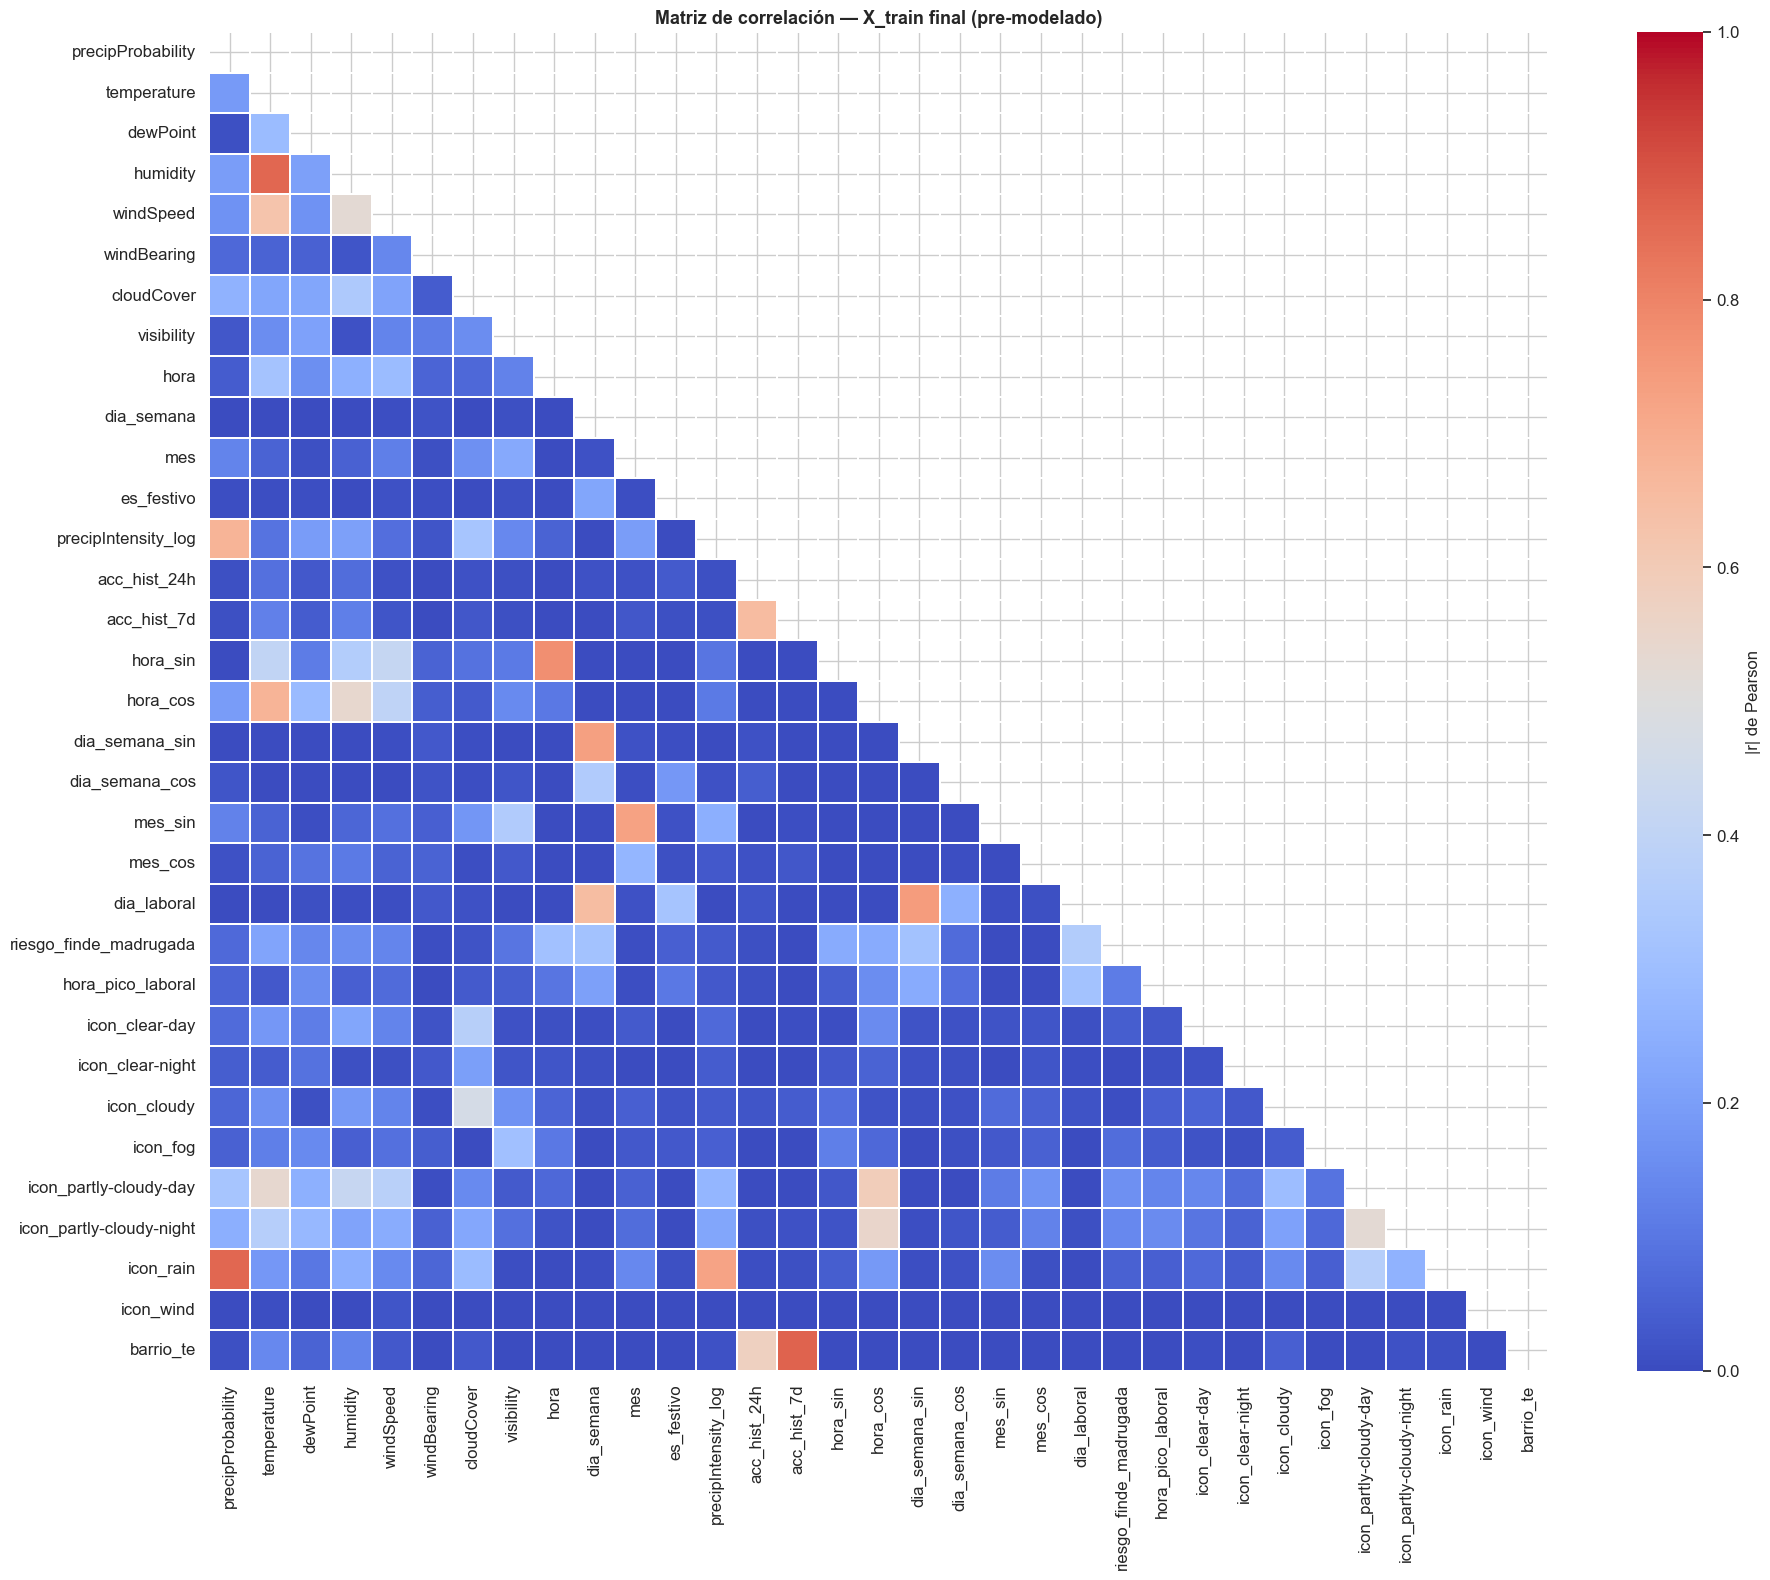


 ✅ Auditoría completada. Ver tabla y heatmap arriba.


In [105]:
# =============================================================================
# 5.7. AUDITORÍA INTEGRAL PRE-MODELADO
# Verifica todas las garantías del checklist anterior de forma automática.
# Un ✅ en cada ítem confirma que el pipeline está listo para la sección 4.4.
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def auditoria_integral_pre_modelado(X_train, y_train, X_val, X_test,
                                     df_train, df_maestro, FEATURES):
    print("=" * 80)
    print(" 5.7  AUDITORÍA INTEGRAL PRE-MODELADO")
    print("=" * 80)

    resultados = []

    def registrar(codigo, descripcion, condicion, detalle=""):
        estado = "✅" if condicion else "❌"
        resultados.append({
            'Código': codigo,
            'Verificación': descripcion,
            'Estado': estado,
            'Detalle': detalle
        })
        print(f" {estado} [{codigo}] {descripcion}"
              + (f"  →  {detalle}" if detalle else ""))

    # ------------------------------------------------------------------
    # BLOQUE L: DATA LEAKAGE
    # ------------------------------------------------------------------
    print("\n── DATA LEAKAGE ─────────────────────────────────────────────")

    # L1-L3: correlación de features de memoria con target
    for col, codigo in [('barrio_te',    'L1'),
                         ('acc_hist_24h', 'L2'),
                         ('acc_hist_7d',  'L3')]:
        if col in X_train.columns:
            r = X_train[col].corr(y_train)
            registrar(codigo,
                      f"corr({col}, target) en train < 0.5",
                      abs(r) < 0.5,
                      f"|r| = {abs(r):.4f}")
        else:
            registrar(codigo,
                      f"corr({col}, target) en train < 0.5",
                      False, f"'{col}' no encontrada en X_train")

    # L4: target_lag1 excluida de FEATURES
    registrar('L4',
              "target_lag1 excluida de FEATURES",
              'target_lag1' not in FEATURES,
              f"presente en FEATURES: {'target_lag1' in FEATURES}")

    # L5: ninguna feature con |r| > 0.5 con target
    corrs = X_train.corrwith(y_train).abs()
    features_criticas = corrs[corrs > 0.5].index.tolist()
    registrar('L5',
              "Ninguna feature con |r| > 0.5 con target",
              len(features_criticas) == 0,
              f"features críticas: {features_criticas if features_criticas else 'ninguna'}")

    # L6: acc_hist_24h en primera hora de cada barrio = 0 (shift correcto)
    if 'acc_hist_24h' in df_train.columns:
        primera_hora = (
            df_train.sort_values(['BARRIO', 'TW'])
            .groupby('BARRIO')
            .first()['acc_hist_24h']
        )
        max_primera = primera_hora.max()
        registrar('L6',
                  "acc_hist_24h = 0 en primera hora de cada barrio",
                  max_primera == 0,
                  f"máximo en primera hora: {max_primera}")

    # L7: fallbacks en val y test = 0
    fallback_val  = X_val['barrio_te'].isna().sum()  if 'barrio_te' in X_val.columns  else -1
    fallback_test = X_test['barrio_te'].isna().sum() if 'barrio_te' in X_test.columns else -1
    registrar('L7',
              "barrio_te sin fallbacks NaN en val y test",
              fallback_val == 0 and fallback_test == 0,
              f"val: {fallback_val} | test: {fallback_test}")

    # ------------------------------------------------------------------
    # BLOQUE M: MULTICOLINEALIDAD
    # ------------------------------------------------------------------
    print("\n── MULTICOLINEALIDAD ────────────────────────────────────────")

    # M1: ningún par supera |r| > 0.85
    cols_num = X_train.select_dtypes(include='number').columns
    corr_matrix = X_train[cols_num].corr().abs()
    mask_upper  = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    pares_altos = (
        corr_matrix.where(mask_upper)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'v1', 'level_1': 'v2', 0: 'r'})
        .query('r > 0.85')
    )
    registrar('M1',
              "Ningún par numérico con |r| > 0.85 en X_train",
              len(pares_altos) == 0,
              f"{len(pares_altos)} pares críticos"
              + (f": {pares_altos[['v1','v2','r']].values.tolist()}"
                 if len(pares_altos) > 0 else ""))

    # M2-M7: columnas problemáticas eliminadas
    cols_deben_faltar = {
        'M2': 'apparentTemperature',
        'M3': 'summary',
        'M4': 'uvIndex',
        'M5': 'es_fin_semana',
        'M6': 'hora_pico',
        'M7': 'is_raining'
    }
    for codigo, col in cols_deben_faltar.items():
        registrar(codigo,
                  f"'{col}' eliminada de FEATURES",
                  col not in FEATURES,
                  f"presente: {col in FEATURES}")

    # ------------------------------------------------------------------
    # BLOQUE Q: CALIDAD DE DATOS
    # ------------------------------------------------------------------
    print("\n── CALIDAD DE DATOS ─────────────────────────────────────────")

    # Q1: nulos en los tres splits
    nulos = {
        'X_train': X_train.isnull().sum().sum(),
        'X_val':   X_val.isnull().sum().sum(),
        'X_test':  X_test.isnull().sum().sum()
    }
    registrar('Q1',
              "Sin nulos en X_train / X_val / X_test",
              sum(nulos.values()) == 0,
              str(nulos))

    # Q2-Q6: transformaciones documentadas (verificación por presencia)
    checks_presencia = {
        'Q2': ('precipIntensity_log', "precipIntensity transformada con log1p"),
        'Q3': ('windBearing',         "windBearing presente (imputación aplicada)"),
    }
    for codigo, (col, desc) in checks_presencia.items():
        registrar(codigo, desc, col in FEATURES,
                  f"en FEATURES: {col in FEATURES}")

    # ------------------------------------------------------------------
    # BLOQUE S: SPLIT TEMPORAL
    # ------------------------------------------------------------------
    print("\n── SPLIT TEMPORAL ───────────────────────────────────────────")

    # S1: deriva del target < 0.5% absoluto entre splits
    tasa_train = y_train.mean() * 100
    for nombre, y_p, codigo in [('val',  y_val,  'S1a'),
                                  ('test', y_test, 'S1b')]:
        deriva = abs(y_p.mean() * 100 - tasa_train)
        registrar(codigo,
                  f"Deriva target train→{nombre} < 0.5%",
                  deriva < 0.5,
                  f"deriva = {deriva:.3f}%")

    # S2: target y TW excluidos de FEATURES
    for col, codigo in [('target', 'S2a'), ('TW', 'S2b')]:
        registrar(codigo,
                  f"'{col}' excluida de FEATURES",
                  col not in FEATURES,
                  f"presente: {col in FEATURES}")

    # S3: estabilidad de hora y dia_semana entre train y test
    for col, codigo in [('hora', 'S3a'), ('dia_semana', 'S3b')]:
        if col in X_train.columns:
            std   = X_train[col].std()
            deriva = abs(X_test[col].mean() - X_train[col].mean()) / std
            registrar(codigo,
                      f"Deriva normalizada '{col}' train→test < 0.3",
                      deriva < 0.3,
                      f"deriva norm. = {deriva:.3f}")

    # ------------------------------------------------------------------
    # BLOQUE E: EDA → FEATURES
    # ------------------------------------------------------------------
    print("\n── EDA → FEATURES ───────────────────────────────────────────")

    checks_eda = {
        'E1a': ('hora_sin',               "hora_sin (cíclica)"),
        'E1b': ('hora_cos',               "hora_cos (cíclica)"),
        'E1c': ('dia_semana_sin',         "dia_semana_sin (cíclica)"),
        'E1d': ('mes_sin',                "mes_sin (cíclica)"),
        'E2':  ('es_festivo',             "Festivos Colombia"),
        'E3':  ('hora_pico_laboral',      "Interacción hora_pico × dia_laboral"),
        'E4':  ('riesgo_finde_madrugada', "Riesgo madrugada fin de semana"),
        'E5':  ('icon_rain',              "OHE de icon (al menos icon_rain)"),
        'E6':  ('barrio_te',              "Target Encoding de BARRIO"),
    }
    for codigo, (col, desc) in checks_eda.items():
        registrar(codigo, desc, col in FEATURES,
                  f"en FEATURES: {col in FEATURES}")

    # ------------------------------------------------------------------
    # RESUMEN EJECUTIVO
    # ------------------------------------------------------------------
    df_res = pd.DataFrame(resultados)
    total   = len(df_res)
    passed  = (df_res['Estado'] == '✅').sum()
    failed  = total - passed

    print(f"\n{'─'*80}")
    print(f" RESUMEN: {passed}/{total} verificaciones pasadas  |  "
          f"{'✅ Pipeline listo para 4.4' if failed == 0 else f'❌ {failed} ítem(s) requieren atención'}")
    print(f"{'─'*80}")

    if failed > 0:
        print("\n Items que requieren atención:")
        print(df_res[df_res['Estado'] == '❌']
              [['Código', 'Verificación', 'Detalle']]
              .to_string(index=False))

    # ------------------------------------------------------------------
    # VISUALIZACIÓN: mapa de calor de correlación final
    # ------------------------------------------------------------------
    cols_viz = X_train.select_dtypes(include='number').columns
    corr_viz = X_train[cols_viz].corr().abs()

    fig, ax = plt.subplots(figsize=(20, 16))
    mask = np.triu(np.ones_like(corr_viz, dtype=bool))
    sns.heatmap(
        corr_viz, mask=mask,
        cmap='coolwarm', vmin=0, vmax=1, center=0.5,
        linewidths=0.3, square=True,
        cbar_kws={'label': '|r| de Pearson'},
        ax=ax
    )
    ax.set_title(
        'Matriz de correlación — X_train final (pre-modelado)',
        fontweight='bold', fontsize=13
    )
    plt.tight_layout()
    plt.savefig('auditoria_correlacion_final.png', bbox_inches='tight')
    plt.show()

    print("\n ✅ Auditoría completada. Ver tabla y heatmap arriba.")
    print("=" * 80)

    return df_res


df_auditoria = auditoria_integral_pre_modelado(
    X_train, y_train, X_val, X_test,
    df_train, df_maestro, FEATURES
)

1. Análisis de la Multicolinealidad Residual (Los 3 pares críticos)

tres pares de variables que superan el umbral de advertencia de colinealidad ($|r| > 0.85$) en tu conjunto de entrenamiento:

 Analicemos si tienen sentido físico/matemático y qué acción tomar:
 
 **Par 1: precipProbability vs icon_rain ($r \approx 0.859$)**
 
 ¿Tiene sentido? Absolutamente. Si el ícono meteorológico consolidado indica lluvia (icon_rain = 1), la probabilidad matemática de precipitación calculada por el modelo climático subyacente será altísima. Es una redundancia semántica directa. Veredicto: Eliminar icon_rain. Como bien dedujimos en la sección 5.5 al eliminar is_raining, la variable continua precipProbability aporta mucha más entropía y granularidad a los árboles de decisión que una variable dicotómica dispersa.
 
 **Par 2: temperature vs humidity ($r \approx 0.863$)**
 
 ¿Tiene sentido? Sí, es una correlación termodinámica clásica. A medida que la temperatura del aire aumenta durante el día en un clima tropical, la humedad relativa tiende a caer.  Veredicto: Depende de tu algoritmo final. Si vas a utilizar modelos basados en árboles (Random Forest, XGBoost, LightGBM), puedes conservar ambas. Los árboles son robustos a la colinealidad y podrían encontrar interacciones no lineales valiosas (e.g., días inusualmente calurosos y húmedos). Si vas a usar modelos paramétricos lineales (Regresión Logística), debes eliminar humidity para no inflar la varianza de los coeficientes.
 
 **Par 3: acc_hist_7d vs barrio_te ($r \approx 0.871$)**
 
 ¿Tiene sentido? barrio_te es el promedio suavizado del riesgo histórico del barrio. acc_hist_7d es la suma móvil de los últimos 7 días. Ambos están capturando exactamente el mismo fenómeno: la "línea base de peligrosidad espacial". Un barrio peligroso (alto Target Encoding) naturalmente tendrá un conteo semanal alto de accidentes.  Veredicto:  Eliminar acc_hist_7d.

In [106]:
# ==============================================================================
# SECCIÓN 5.6: MITIGACIÓN DE MULTICOLINEALIDAD RESIDUAL (AUDITORÍA APROBADA)
# ==============================================================================
# Razón metodológica: 
# 1. 'icon_rain' aporta redundancia semántica dura frente a 'precipProbability'.
# 2. 'acc_hist_7d' colisiona linealmente con 'barrio_te' (ambas miden línea base espacial).

cols_a_eliminar = ['icon_rain', 'acc_hist_7d']

# Aplicar eliminación simétrica en todas las particiones para evitar desalineación estructural
X_train = X_train.drop(columns=cols_a_eliminar, errors='ignore')
X_val   = X_val.drop(columns=cols_a_eliminar, errors='ignore')
X_test  = X_test.drop(columns=cols_a_eliminar, errors='ignore')

print("="*70)
print(f"✔ AUDITORÍA DE COLINEALIDAD CERRADA.")
print(f"✔ Variables removidas con éxito: {cols_a_eliminar}")
print(f"✔ Dimensiones finales post-mitigación:")
print(f"   -> X_train: {X_train.shape}")
print(f"   -> X_val:   {X_val.shape}")
print(f"   -> X_test:  {X_test.shape}")
print("="*70)

✔ AUDITORÍA DE COLINEALIDAD CERRADA.
✔ Variables removidas con éxito: ['icon_rain', 'acc_hist_7d']
✔ Dimensiones finales post-mitigación:
   -> X_train: (5868324, 31)
   -> X_val:   (1257498, 31)
   -> X_test:  (1257498, 31)


<div style="padding: 15px; border-left: 6px solid; border-radius: 4px;">

### **🔴 ¡ALERTA CRÍTICA PARA EL EQUIPO DE MODELADO (SECCIÓN 6)! 🔴**

Compañeros, la **Sección 5 (JOIN y Feature Engineering)** ha sido cerrada bajo una estricta auditoría de calidad de datos y control de *Data Leakage*. Para garantizar que el taller mantenga el máximo puntaje en la rúbrica (20% en Validación y 15% en Ingeniería), deben leer obligatoriamente las siguientes directrices antes de entrenar cualquier modelo:

**1. ⚠️ El Enigma del Par 2: `temperature` vs `humidity` ($r \approx 0.863$)**  

Este par supera el umbral de advertencia ($|r| > 0.85$), pero **NO** fue eliminado deliberadamente. Su manejo depende estrictamente del algoritmo que decidan implementar en la siguiente sección:
* **Si usan modelos basados en árboles (XGBoost, LightGBM, CatBoost):** ¡MANTENGAN AMBAS VARIABLES! Los árboles son inmunes a la multicolinealidad lineal y pueden extraer interacciones no lineales valiosas de la relación termodinámica entre ambas (ej. días de calor extremo con alta humedad).
* **Si usan modelos paramétricos (Regresión Logística, SVM, Redes Neuronales):** ¡DEBEN ELIMINAR `humidity`! Mantener ambas inflará artificialmente la varianza de los coeficientes, inestabilizando el entrenamiento y arruinando la interpretabilidad.

**2. 🔍 Reto de Auditoría: Control de Fuga de Datos (*Data Leakage*)**  

Los invito a revisar con lupa el pipeline que construí antes de lanzar sus baselines:
* Verifiquen que los cálculos de las ventanas móviles (`acc_hist_24h`) se mantengan blindados mediante el operador `shift(1)` para no mirar el accidente actual del tiempo $t$.
* Asegúrense de que el *Target Encoding* del barrio (`barrio_te`) solo haya aprendido de las etiquetas de `df_train` y se esté mapeando pasivamente a validación y prueba sin contaminación cruzada.

**3. 🧠 Selección de Variables adaptativa**  

No usen el mismo set de datos a ciegas para todos los algoritmos. Si deciden probar **CatBoost**, recuerden activar su parámetro nativo para variables categóricas en lugar de usar codificaciones manuales dispersas. Si usan **XGBoost**, recuerden que es sensible a la escala si meten regularizaciones lineales avanzadas.

**4. Por favor revisen todo el codigo anterior y validen el proceso** Si lo anterior está mal el modelo valió madres.

***Regla de oro del curso: El código que corre no basta; el experimento debe ser metodológicamente defendible.***
</div>